# Generative Adversarial Networks

The objective of this exercise is to train and compare several variants of generative adversarial networks (GANs), including the standard GAN, conditional GAN (cGAN), and deep convolutional GAN (DCGAN), with the aim of generating images that resemble those in the Fashion-MNIST dataset. The overall workflow is organized into three main stages:

- **Preparation**: This stage focuses on establishing the foundational components required for the subsequent steps. It involves importing the necessary libraries, verifying GPU availability and usability, and implementing a data-loading class. Additionally, random seeds are fixed to ensure reproducibility, so that repeated training runs yield consistent results.

- **Model Definition**: In this stage, the model architectures and supporting classes are defined. These implementations facilitate the training and management of the different GAN variants.

- **Evaluation**: This stage consists of two complementary components. The first involves quantitative evaluation using appropriate performance metrics, while the second focuses on qualitative assessment through visualization, which aids in analyzing the quality and diversity of the generated images.

Following the completion of these stages, the models are trained, and the resulting outputs are analyzed and discussed.

## Preparation

### Imports

In [1]:
import torch
import time
import random
import numpy as np
import math
import torch.nn as nn
from torchinfo import summary
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import DataLoader, random_split, Dataset, ConcatDataset

### GPU check

This section is mainly focused on the device we are about to use and does not interfere with other parts and can be just replaced with the following code:
```python
device = torch.device("cpu")
```

In [2]:
!nvidia-smi

Sun Dec 28 07:24:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P0             19W /   55W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### Loading data

#### Fashion_MNIST_Data (Data utility class)

This class provides a compact interface for loading **Fashion-MNIST** with standard preprocessing, splitting the training set into **train/validation**, and exposing helpers for **data loaders**, **class-name lookup**, and **quick visualization**.

* **Preprocessing**

  * Converts images to tensors and normalizes them to roughly **[-1, 1]** using `Normalize((0.5,), (0.5,))`.

* **Datasets**

  * Downloads and prepares:

    * `train=True` dataset, then splits it into:

      * **55,000** samples for training
      * **5,000** samples for validation
    * `train=False` dataset as the **test set**
  * Stores the label names in `self.class_names`.

* **Methods**

  * `get_loaders(batch_size=32)`: Returns `(train_loader, val_loader, test_loader)` with appropriate shuffling (train only).
  * `get_class_names()`: Returns a dictionary mapping `{label_id: class_name}`.
  * `plot_batch_sample(...)`: Draws a small grid of randomly sampled training images and prints their class names under each image for quick qualitative inspection.


In [ ]:
class Fashion_MNIST_Data:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])
        train_val_dataset = datasets.FashionMNIST(root="./Data", train=True, download=True, transform=self.transform)
        self.test_dataset = datasets.FashionMNIST(root="./Data", train=False, download=True, transform=self.transform)
        self.train_dataset, self.val_dataset = random_split(train_val_dataset, [40000, 20000])
        self.class_names = self.test_dataset.classes

    def get_loaders(self, batch_size=32):
        train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(self.val_dataset,   batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(self.test_dataset,  batch_size=batch_size, shuffle=False)
        return train_loader, val_loader, test_loader
    
    def get_class_names(self):
        return {i:name for i, name in enumerate(self.class_names)}

    def plot_batch_sample(self, max_per_row = 4, sample_size = 8, figsize_per_img = 2.8):
        d_loader = DataLoader(self.train_dataset, batch_size=sample_size, shuffle=True)
        batch = next(iter(d_loader))
        images, labels = batch[0], batch[1]

        cols = min(max_per_row, sample_size)
        rows = math.ceil(sample_size / cols)
        fig_w = cols * figsize_per_img
        fig_h = rows * figsize_per_img

        fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))

        if rows == 1 and cols == 1:
            axes = [axes]
        elif rows == 1:
            axes = list(axes)
        else:
            axes = [ax for row_axes in axes for ax in row_axes]

        for i, ax in enumerate(axes):
            if i >= sample_size:
                ax.axis("off")
                continue

            img = images[i].squeeze(0)  
            ax.imshow(img, cmap="gray")
            ax.axis("off")
            y = labels[i].item() if torch.is_tensor(labels[i]) else labels[i]
            title = str(self.class_names[int(y)])
            ax.text(0.5, -0.10, title, transform=ax.transAxes, ha="center", va="top", fontsize=11)

        plt.tight_layout()
        plt.show()


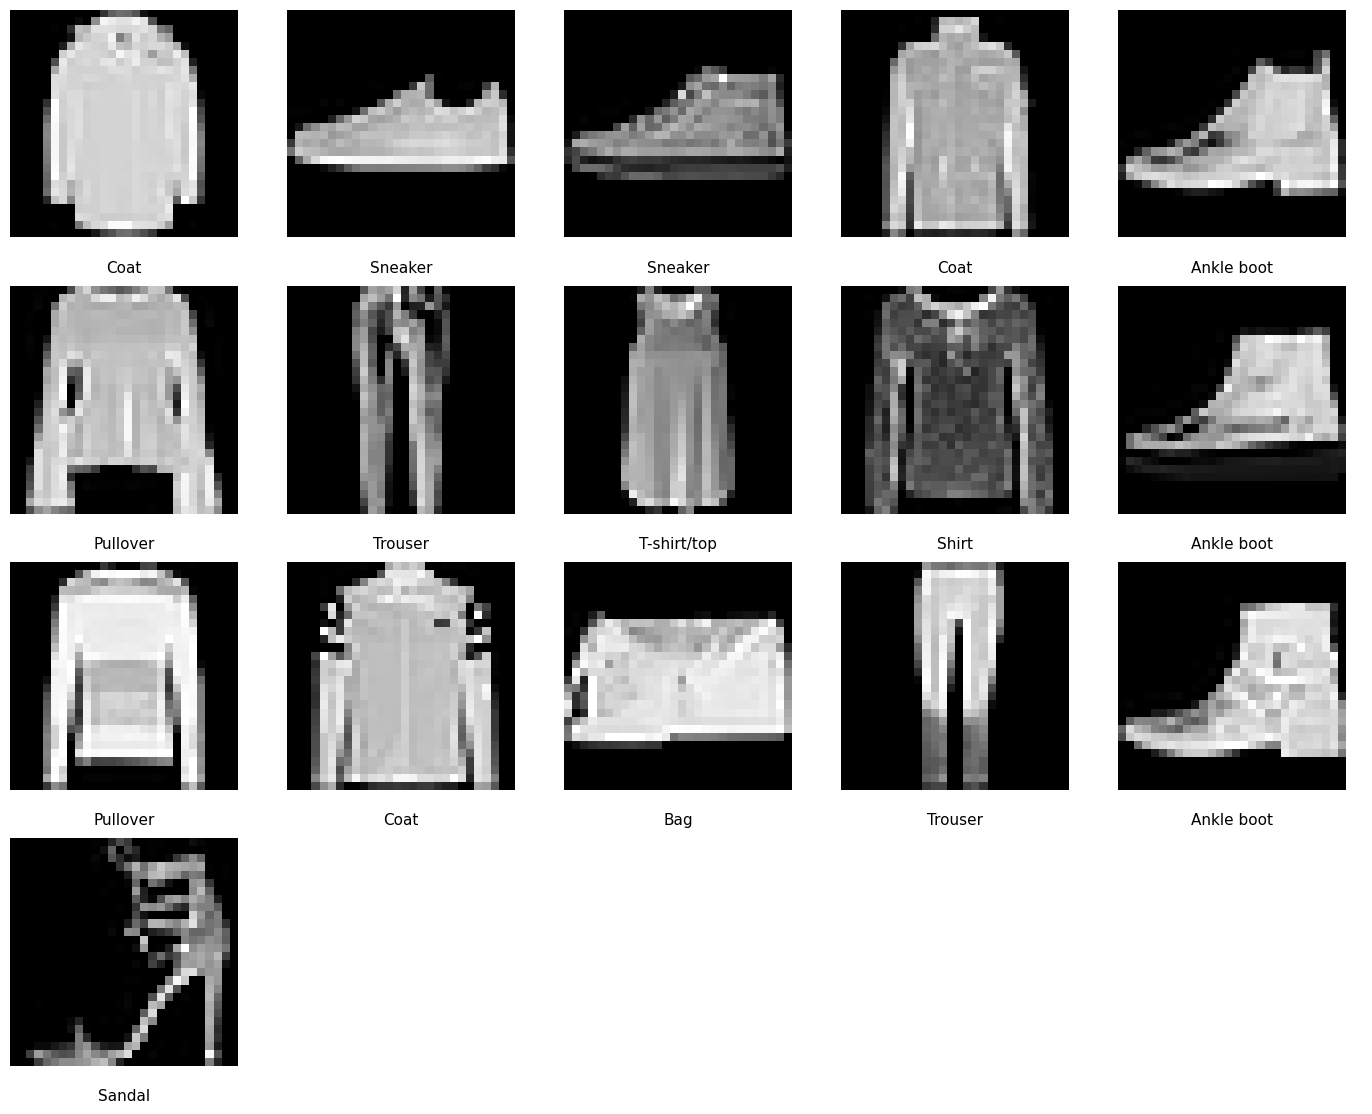

{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


In [5]:
fmd = Fashion_MNIST_Data()
train_loader, val_loader, test_loader = fmd.get_loaders(32)
fmd.plot_batch_sample(max_per_row=5, sample_size=16)
print(fmd.get_class_names())

### Randomization control

In [6]:
base_seed = 42
torch.manual_seed(base_seed)
np.random.seed(base_seed)
random.seed(base_seed)
torch.cuda.manual_seed_all(base_seed)

### Constants

In [ ]:
NOISE_DIMENSION = 100
NOISE_DIMENSION_LIST = [32, 100, 200]
D_CRITERION = nn.BCEWithLogitsLoss()
G_CRITERION = nn.BCEWithLogitsLoss()
LEARNING_RATE = 0.0002
LEARNING_RATE_LIST = [0.001, 0.0002, 0.0001]
NUM_EPOCH = 100
NUM_EPOCH_LIST = [20, 50, 100]
BATCH_SIZE = 128
BATCH_SIZE_LIST = [32, 128, 256]

## Model Definition

### Base discriminator

#### Overview

The `Discriminator` class is a PyTorch neural network that acts as the "critic" in the GAN architecture. Its primary goal is to perform binary classification: distinguishing between **real images** (from the dataset) and **fake images** (produced by the Generator).

#### Key Features

* **Dual Architecture Support:** Can switch between a Deep Convolutional GAN (**DCGAN**) architecture or a simple Linear (Vanilla/MLP) architecture using the `dc` boolean flag.
* **Conditional GAN (cGAN) Capable:** If `num_classes` is provided, the model incorporates class labels into the input, allowing it to learn specific class features.
* **Configurable Depth:** Allows customization of filter sizes via the `filters` argument.

#### Constructor Parameters

* `num_classes` (int, optional): The number of classes (e.g., 10 for MNIST). If set, the model runs in **Conditional** mode.
* `dc` (bool): If `True`, uses Convolutional layers (Conv2d). If `False`, uses Linear layers. Default is `True`.
* `filters` (list): A list of integers defining the number of channels for the convolutional layers.
* `drop_out_rate` (float): Probability for the Dropout layers to prevent overfitting.

#### Core Methods

**1. forward**

Performs the forward pass of the network.

- **Inputs**
    - `img`: A batch of images (Tensor).
    - `labels`: Class labels (Tensor, required only if `is_conditional` is True).


- **Process**
    - *Conditional Step:* If conditional, it embeds the labels.
    - *DCGAN mode:* Embeds labels to match image spatial dimensions and concatenates them as extra channels.
    - *Vanilla mode:* Embeds labels and concatenates them to the flattened image vector.


- **Classification** 
    - Passes the data through the sequential model (Layers  LeakyReLU  Linear).


- **Output** 
    - A scalar value (logit) representing the probability that the input image is real.

**2. Utility Methods**

* `set_learning_rate(lr)` / `get_learning_rate()`: Modifies or retrieves the optimizer's learning rate dynamically.
* `summarize()`: Prints the model architecture and parameter count.

In [7]:
class Discriminator(nn.Module):
    def __init__(self, num_classes=None, dc=True, learning_rate=0.0002, drop_out_rate=0.25, filters=[256, 128, 64], device='cpu', seed=42):
        torch.manual_seed(seed)
        super(Discriminator, self).__init__()
        
        self.device = device if isinstance(device, torch.device) else torch.device(device)
        self.is_conditional = num_classes is not None
        self.dc = dc
        
        if self.dc:
            input_channels = 2 if self.is_conditional else 1
            if self.is_conditional:
                self.label_emb = nn.Embedding(num_classes, 28 * 28)
            self.model = nn.Sequential(
                nn.Conv2d(input_channels, filters[2], 5, stride=2, padding=2),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(filters[2], filters[1], 5, stride=2, padding=2),
                nn.BatchNorm2d(filters[1]),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Conv2d(filters[1], filters[0], 3, stride=1, padding=1),
                nn.BatchNorm2d(filters[0]),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Dropout2d(drop_out_rate),
                nn.Flatten(),
                nn.Linear(7 * 7 * filters[0], 10),
                nn.Linear(10, 1)
            )
            
        else:
            img_dim = 28 * 28
            input_dim = img_dim
            
            if self.is_conditional:
                self.label_emb = nn.Embedding(num_classes, 64) 
                input_dim += 64
            
            self.model = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input_dim, 512),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Linear(512, 256),
                nn.LeakyReLU(0.2, inplace=True),
                nn.Linear(256, 1)
            )

        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        self.to(self.device)

    def forward(self, img, labels=None):
        x = img
        if self.is_conditional:
            if self.dc:
                label_embedding = self.label_emb(labels).view(labels.size(0), 1, img.size(2), img.size(3))
                x = torch.cat([img, label_embedding], 1)
            else:
                label_embedding = self.label_emb(labels)
                flat_img = img.view(img.size(0), -1)
                x = torch.cat([flat_img, label_embedding], 1)
        return self.model(x)

    def set_learning_rate(self, lr):
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr
            
    def get_learning_rate(self):
        return self.optimizer.param_groups[0]['lr']
    
    def set_device(self, device):
        self.device = device if isinstance(device, torch.device) else torch.device(device)
        self.to(self.device)
        
    def get_device(self):
        return self.device
        
    def summarize(self, input_size=(1, 1, 28, 28)):
        print(f"{'DCGAN' if self.dc else 'Vanilla'} Discriminator | Conditional: {self.is_conditional}\n", summary(self, input_size=input_size))

### Base generator

#### Overview

The `Generator` class is the "artist" of the GAN. It takes a random noise vector (, also known as the latent vector) and transforms it into a synthetic image. Its goal is to fool the Discriminator into believing the generated images are real.

#### Key Features

* **Upsampling Architecture:**
* **DCGAN:** Uses `ConvTranspose2d` layers to spatially upsample the noise vector into a 2D image.
* **Vanilla:** Uses `Linear` layers to map noise to pixel values directly.


* **Conditional Generation:** Can condition the output on specific class labels (e.g., forcing the model to generate a "digit 7").
* **Activation:** Ends with a `Tanh` activation function, normalizing output pixel values between -1 and 1.

#### Constructor Parameters

* `noise_dim` (int): The size of the input latent vector ().
* `num_classes` (int, optional): Enables conditional generation if provided.
* `dc` (bool): Toggles between DCGAN (Transposed Convolutions) and Vanilla (Linear) architectures.
* `filters` (list): Defines the channel depth for the upsampling layers.

#### Core Methods

**1. Forward**

Generates an image from noise.

- **Inputs**
    - `z`: Random noise tensor of shape `(batch_size, noise_dim)`.
    - `labels`: Class labels (required if `is_conditional` is True).


- **Process**
    - If conditional, the label embeddings are concatenated with the noise vector .
    - The combined vector is passed through the model.
    - In DCGAN mode, the data is unflattened and upsampled via Transposed Convolutions to reach the target image size (hardcoded to 28x28 in this implementation).


* **Output** A batch of generated images.


**2. Utility Methods**

* `set_learning_rate(lr)` / `get_learning_rate()`: Modifies or retrieves the optimizer's learning rate dynamically.
* `summarize()`: Prints the model architecture and parameter count.

In [8]:
class Generator(nn.Module):
    def __init__(self, noise_dim, num_classes=None, dc=True, learning_rate=0.0002, filters=[256, 128, 64], device='cpu', seed=42):
        torch.manual_seed(seed)
        super(Generator, self).__init__()
        self.device = device if isinstance(device, torch.device) else torch.device(device)
        self.is_conditional = num_classes is not None
        self.dc = dc
        self.noise_dim = noise_dim
        self.input_dim = noise_dim
        if self.is_conditional:
            self.label_emb = nn.Embedding(num_classes, noise_dim)
            self.input_dim = noise_dim * 2
        
        if self.dc:
            self.model = nn.Sequential(
                nn.Linear(self.input_dim, 7 * 7 * filters[0]),
                nn.LeakyReLU(0.2),
                nn.Unflatten(1, (filters[0], 7, 7)),
                nn.ConvTranspose2d(filters[0], filters[1], 5, stride=1, padding=2),
                nn.BatchNorm2d(filters[1]),
                nn.LeakyReLU(0.2),
                nn.ConvTranspose2d(filters[1], filters[2], 5, stride=2, padding=2, output_padding=1),
                nn.BatchNorm2d(filters[2]),
                nn.LeakyReLU(0.2),
                nn.ConvTranspose2d(filters[2], 1, 5, stride=2, padding=2, output_padding=1),
                nn.Tanh()
            )
        else:
            self.model = nn.Sequential(
                nn.Linear(self.input_dim, 256),
                nn.LeakyReLU(0.2),
                nn.Linear(256, 512),
                nn.LeakyReLU(0.2),
                nn.Linear(512, 1024),
                nn.LeakyReLU(0.2),
                nn.Linear(1024, 28 * 28),
                nn.Tanh(),
                nn.Unflatten(1, (1, 28, 28))
            )

        self.optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        self.to(self.device)

    def forward(self, z, labels=None):
        if self.is_conditional:
            label_embedding = self.label_emb(labels)
            z = torch.cat([z, label_embedding], 1)
            
        return self.model(z)

    def set_learning_rate(self, lr):
        for param_group in self.optimizer.param_groups:
            param_group["lr"] = lr
            
    def get_learning_rate(self):
        return self.optimizer.param_groups[0]['lr']
    
    def set_device(self, device):
        self.device = device if isinstance(device, torch.device) else torch.device(device)
        self.to(self.device)
        
    def get_device(self):
        return self.device

    def summarize(self):
        print(f"{'DCGAN' if self.dc else 'Vanilla'} Generator | Conditional: {self.is_conditional}\n", summary(self, input_size=(1, self.noise_dim)))

### GAN

#### Overview

The `GenerativeAdversarialNet` class is a high-level wrapper (or "Manager") that encapsulates both the `Generator` and `Discriminator`. It handles the initialization of both networks, manages their optimizers, and orchestrates the adversarial training loop.

#### Key Features

* **Unified Management:** initializes both sub-networks with synchronized device placement (CPU/GPU) and learning rates.
* **Training Logic:** Implements the specific "Min-Max" game logic required to train GANs.
* **Inference:** Provides a simple interface to generate images after training.

#### Constructor Parameters (`__init__`)

* `discriminator_criterion` / `generator_criterion`: The loss functions (usually Binary Cross Entropy) used to evaluate performance.
* `lg_filter` (bool): A helper flag to quickly switch between large (512-based) or small (128-based) filter sizes for the networks.
* `noise_dim`, `num_classes`, `dc`: Configuration parameters passed down to the sub-networks.

#### Core Methods

**1. train_one_epoch**

Executes the training steps for a single pass through the dataset.

- **Train Discriminator**
    - **Real Step:** Feeds real images from `data_loader` to the Discriminator; calculates loss against a target of 1s (Real).
    - **Fake Step:** Generates fake images using the Generator; feeds them to the Discriminator; calculates loss against a target of 0s (Fake).
    - Updates Discriminator weights.


- **Train Generator**
    - Generates a new batch of fake images.
    - Feeds them to the Discriminator (which is frozen during this step).
    - Calculates loss against a target of **1s** (trying to trick the Discriminator).
    - Updates Generator weights.


- **Returns:** Tuple of (average_discriminator_loss, average_generator_loss).

**2. generate**

The inference method for the GAN.

* Sets the Generator to evaluation mode (`eval()`).
* Disables gradient calculation (`torch.no_grad()`).
* Passes the noise vector  (and labels if conditional) to the Generator to produce images.

**3. Utility Methods**

* `set_learning_rate`: Allows independent or simultaneous tuning of learning rates for the Generator and Discriminator.
* `set_device`: Moves the entire system to CPU or GPU.

In [9]:
class GenerativeAdversarialNet():
    def __init__(
            self,
            noise_dim, 
            discriminator_criterion, 
            generator_criterion, 
            discriminator_learning_rate=0.0002, 
            generator_learning_rate=0.0002,
            device='cpu',
            is_conditional=False,
            num_classes=10,
            dc=True,
            lg_filter=None
        ):
        
        self.noise_dim = noise_dim
        self.d_criterion = discriminator_criterion
        self.g_criterion = generator_criterion
        self.device = device
        self.is_conditional = is_conditional
        self.num_classes = num_classes
        self.dc = dc

        num_classes_param = num_classes if is_conditional else None
        if lg_filter is None:
            filters = [256, 128, 64]
        else:
            filters = [512, 256, 128] if lg_filter else [128, 64, 32]
        self.discriminator = Discriminator(num_classes=num_classes_param, dc=dc, learning_rate=discriminator_learning_rate, filters=filters, device=device)
        self.generator = Generator(noise_dim, num_classes=num_classes_param, dc=dc, learning_rate=generator_learning_rate, filters=filters, device=device)

    def train_one_epoch(self, data_loader):
        d_loss = 0
        g_loss = 0
        device = self.device
        
        for i, data in enumerate(data_loader):
            real_images, real_labels_idx = data 
            real_images = real_images.to(device)
            real_labels_idx = real_labels_idx.to(device)
            batch_size = real_images.size(0)
            if self.is_conditional:
                gen_labels_idx = torch.randint(0, self.num_classes, (batch_size,), device=device)
            else:
                real_labels_idx = None
                gen_labels_idx = None


            self.discriminator.optimizer.zero_grad()
            
            real_labels = torch.ones(batch_size, 1, device=device)
            real_outputs = self.discriminator(real_images, real_labels_idx)
            real_loss = self.d_criterion(real_outputs, real_labels)
            d_loss += real_loss.item()
            real_loss.backward()

            noise = torch.randn(batch_size, self.noise_dim, device=device)
            fake_images = self.generator(noise, gen_labels_idx)
            fake_labels = torch.zeros(batch_size, 1, device=device)
            
            fake_outputs = self.discriminator(fake_images.detach(), gen_labels_idx)
            fake_loss = self.d_criterion(fake_outputs, fake_labels)
            d_loss += fake_loss.item()
            fake_loss.backward()
            
            self.discriminator.optimizer.step()


            self.generator.optimizer.zero_grad()
            
            noise = torch.randn(batch_size, self.noise_dim, device=device)
            if self.is_conditional:
                gen_labels_idx = torch.randint(0, self.num_classes, (batch_size,), device=device)

            fake_images = self.generator(noise, gen_labels_idx)
            gen_labels = torch.ones(batch_size, 1, device=device)
            
            fake_outputs = self.discriminator(fake_images, gen_labels_idx)
            gen_loss = self.g_criterion(fake_outputs, gen_labels)
            g_loss += gen_loss.item()
            gen_loss.backward()
            
            self.generator.optimizer.step()

        return d_loss/len(data_loader), g_loss/len(data_loader)

    def generate(self, z, labels=None):
        self.generator.eval()
        with torch.no_grad():
            z = z.to(self.generator.device)
            if self.is_conditional:
                if labels is None:
                    raise ValueError("Labels must be provided for a conditional GAN generation.")
                labels = labels.to(self.generator.device)
            
            imgs = self.generator(z, labels)
        return imgs

    def set_learning_rate(self, lr, generator=True, discriminator=False):
        if generator:
            self.generator.set_learning_rate(lr)
        if discriminator:
            self.discriminator.set_learning_rate(lr)

    def get_learning_rate(self):
        return self.generator.get_learning_rate(), self.discriminator.get_learning_rate()

    def set_device(self, device):
        self.generator.set_device(device)
        self.discriminator.set_device(device)

    def get_device(self):
        return self.generator.get_device()
    
    def summarize(self):
        self.discriminator.summarize()
        self.generator.summarize()

In [10]:
noise_d = 100
dc = nn.BCEWithLogitsLoss()
gc = nn.BCEWithLogitsLoss()
dlr = 0.0002
glr = 0.0002
gan = GenerativeAdversarialNet(noise_d, dc, gc, dlr, glr, device)
gan.summarize()

DCGAN Discriminator | Conditional: False
Layer (type:depth-idx)                   Output Shape              Param #
Discriminator                            [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           1,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 128, 7, 7]            204,928
│    └─BatchNorm2d: 2-4                  [1, 128, 7, 7]            256
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Conv2d: 2-6                       [1, 256, 7, 7]            295,168
│    └─BatchNorm2d: 2-7                  [1, 256, 7, 7]            512
│    └─LeakyReLU: 2-8                    [1, 256, 7, 7]            --
│    └─Dropout2d: 2-9                    [1, 256, 7, 7]            --
│    └─Flatten: 2-10                     [1, 12544]                --
│    └─Linear: 2-11          

## Evaluation

### Metrics

#### Inception Score (IS)

The Inception Score (IS) is a common metric used to evaluate the quality of images generated by GANs. It assesses the generated images based on two criteria: **image quality** (how distinct and recognizable the object is) and **image diversity** (whether the GAN generates a wide variety of classes).

It uses a pre-trained Inception v3 image classification model to predict class probabilities for the generated images.

#### Mathematical Formulation

The Inception Score is calculated using the Kullback-Leibler (KL) divergence between the conditional class distribution $p(y|x)$ and the marginal class distribution $p(y)$.
$$IS(G) = \exp \left( \mathbb{E}_{x \sim p_g} [ D_{KL}( p(y|x) \parallel p(y) ) ] \right)$$

Where:
- $x \sim p_g$: Images generated by the GAN.
- $p(y|x)$: The probability distribution of class labels $y$ given an image $x$ (output by the Inception network).
- $p(y)$: The marginal class distribution (the average of $p(y|x)$ over all generated images).
- $D_{KL}$: The KL divergence, measuring how different the two distributions are.

#### What it Represents

* **Interpretation:** A **higher** Inception Score is better.
* **Quality ($p(y|x)$):** We want the Inception network to be confident that an image belongs to a specific class (e.g., "This is definitely a 7"). This results in a low entropy (spiky) $p(y|x)$.
* **Diversity ($p(y)$):** We want the GAN to generate all possible classes evenly (not just 7s). This results in a high entropy (uniform) $p(y)$.
* **The Score:** The score is maximized when $p(y|x)$ is very different from $p(y)$.


#### Deployment in Code (calculate_inception_score)

The implementation relies on the `torchmetrics.image.inception.InceptionScore` class.

1. Preprocessing (preprocess_for_inception)
* The Inception v3 network requires 3-channel (RGB) inputs with specific scaling.
* The code rescales the GAN output (typically -1 to 1) to the range [0, 255] (`uint8`).
* **Crucially**, since the model appears to be generating grayscale images (e.g., MNIST with `images.shape[1] == 1`), the code repeats the single channel 3 times (`images.repeat(1, 3, 1, 1)`) to satisfy the Inception network's input requirements.


2. Generation Loop
* The function generates `n_samples` (default 1000) of fake images.
* If the generator is **conditional**, random class labels are passed during generation to ensure a mix of classes.


3. Calculation
* The fake images are fed into the `InceptionScore` object in batches.
* The object accumulates the statistics and finally computes the mean and standard deviation of the score.


In [16]:
def preprocess_for_inception(images):
    images = (images + 1) / 2.0
    images = torch.clamp(images, 0, 1)
    images = (images * 255).to(torch.uint8)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    return images

def calculate_inception_score(generator, device, noise_dim, num_classes=10, n_samples=1000, batch_size=32):
    inception = InceptionScore(feature='logits_unbiased').to(device) 
    generator.eval()
    generator.to(device)
    num_batches = (n_samples + batch_size - 1) // batch_size

    with torch.no_grad():
        for _ in range(num_batches):
            current_batch_size = min(batch_size, n_samples)
            n_samples -= current_batch_size
            if current_batch_size <= 0: break
            z = torch.randn(current_batch_size, noise_dim, device=device)
            
            gen_labels = None
            if generator.is_conditional:
                gen_labels = torch.randint(0, num_classes, (current_batch_size,), device=device)

            fake_images = generator(z, gen_labels)
            fake_imgs_processed = preprocess_for_inception(fake_images)
            inception.update(fake_imgs_processed)

    is_mean, is_std = inception.compute()
    return is_mean.item(), is_std.item()

#### Metric: Fréchet Inception Distance (FID)

Fréchet Inception Distance (FID) is widely considered a more robust metric than the Inception Score. Unlike IS, which only looks at the generated images, FID compares the statistics of the **generated images** against the statistics of the **real images** from the dataset.

It measures the distance between the feature vectors of real and fake images extracted from an intermediate layer of the Inception v3 network.

#### Mathematical Formulation

FID assumes that the feature vectors of the images follow a multidimensional Gaussian distribution. It calculates the Wasserstein-2 distance (Fréchet distance) between the Gaussian of the real data and the Gaussian of the generated data.

$$FID(r, g) = ||\mu_r - \mu_g||^2 + \text{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2})$$

Where:
- $\mu_r, \Sigma_r$: The mean vector and covariance matrix of the feature activations for real images.
- $\mu_g, \Sigma_g$: The mean vector and covariance matrix of the feature activations for generated (fake) images.
- $\text{Tr}$: The trace of a matrix (sum of diagonal elements).


#### What it Represents

* **Interpretation:** A **lower** FID score is better.
* **Meaning:** A score of 0.0 indicates the two distributions are identical (perfect generation). A high score indicates the generated images are statistically very different from the real training data.
* **Advantages:** FID is sensitive to mode collapse (if the GAN only outputs one type of image) and disturbances like noise or blur, which matches human perception better than IS.

#### Deployment in Code (calculate_fid)

The implementation uses `torchmetrics.image.fid.FrechetInceptionDistance`.

1. Feature Extraction
* The code initializes the metric with `feature=64`. This implies it is using a smaller/earlier feature layer from the Inception network (typically the 64-dimensional layer) rather than the standard 2048-dimensional pool layer. This makes the calculation faster but potentially less semantically deep.


2. Dual Data Streams
* **Real Stream:** The code iterates through the `dataloader` containing real images. These are preprocessed (scaled and converted to 3-channel RGB) and fed to the metric with `real=True`.
* **Fake Stream:** For every batch of real images, the code generates an equivalent batch of fake images (using noise  and random labels if conditional). These are preprocessed and fed to the metric with `real=False`.


3. Calculation
* The `fid.compute()` method calculates the mean and covariance for both accumulated stacks of features and solves the vector equation to return the final distance score.


In [17]:
def calculate_fid(generator, dataloader, device, noise_dim, num_classes=10, feature=64):
    fid = FrechetInceptionDistance(feature=feature).to(device)
    generator.eval()
    generator.to(device)
    with torch.no_grad():
        for real_images, _ in dataloader:
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            real_imgs_processed = preprocess_for_inception(real_images)
            fid.update(real_imgs_processed, real=True)
            z = torch.randn(batch_size, noise_dim, device=device)
            
            gen_labels = None
            if generator.is_conditional:
                gen_labels = torch.randint(0, num_classes, (batch_size,), device=device)
            
            fake_images = generator(z, gen_labels)
            fake_imgs_processed = preprocess_for_inception(fake_images)
            fid.update(fake_imgs_processed, real=False)
    fid_score = fid.compute()
    return fid_score.item()

### Visualization

`generator_discriminator_loss`

This function is responsible for **visualizing the adversarial training progress** of the Generative Adversarial Network (GAN). It takes the recorded losses of both the Discriminator and the Generator over time (typically across training epochs) and plots them on a line graph.

The primary goal is to monitor the dynamic equilibrium between the two competing networks. Ideally, both loss curves should fluctuate and remain relatively high, suggesting neither network is completely dominating the other. A rapidly decreasing Generator loss alongside a rising Discriminator loss often indicates successful generation, while a Discriminator loss dropping to zero usually signals *mode collapse* or a failing Generator. The `is_noisy` flag allows for custom labeling if the model incorporates noisy data techniques.


In [31]:
def generator_discriminator_loss(d_losses, g_losses, title, is_noisy=False):
    plt.figure(figsize=(10, 5))
    plt.title(title)
    plt.plot(d_losses, label=("Noisy Generator" if is_noisy else "Discriminator"))
    plt.plot(g_losses, label="Generator")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

`plot_fake_images`

This function serves to **visualize a small batch of generated images** from the GAN at a specific point in time, allowing for a qualitative assessment of image quality. It takes a pre-generated noise vector (`noise`) and passes it through the provided model to create synthetic images, which are then displayed in a  grid format (up to 16 images).

If the model is a Conditional GAN (cGAN), it accepts `labels` and uses the generator directly (`model.generator`) to ensure controlled generation. In this conditional mode, it also prints the assigned class label (e.g., "7" or "shoe") below each image, verifying that the cGAN is successfully mapping the provided class condition to the visual output. The images are displayed in grayscale (`cmap='gray'`), suitable for datasets like MNIST.

In [32]:
def plot_fake_images(model, noise, title, labels=None):
    plt.figure(figsize=(9, 8))
    plt.title(title)
    if labels is None:
        fake_images = model.generate(noise.to(device))
        b_size = fake_images.size(0)
        fake_images = fake_images.view(b_size, 28, 28)
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_images[i].to('cpu'), cmap='gray')
            plt.axis('off')
    else:
        with torch.no_grad():
            fake_imgs = model.generator(noise, labels).detach().cpu().view(-1, 28, 28)
        for i in range(min(16, len(fake_imgs))):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_imgs[i], cmap='gray')
            plt.axis('off')
            lbl_name = fmd.class_names[labels[i].item()]
            plt.text(0.5, -0.15, lbl_name, transform=plt.gca().transAxes, ha='center')
        plt.tight_layout()
    plt.show()

`plot_conditional_grid`

This function is a specialized tool for **systematically visualizing the capabilities of a Conditional GAN (CGAN)** by generating and displaying a structured grid of images. The resulting grid organizes the generated samples by class, offering an easy way to verify class-specific generation and assess diversity within each category.

It first creates a set of noise and labels such that `samples_per_class` are generated for each of the `num_classes` (default 100 images in a  grid). It then plots these images in a matrix where each row corresponds to a unique class. The rows are labeled with the class name (e.g., "T-shirt/top", "Trouser"), allowing the user to confirm that the model correctly learned the unique features of all class conditions and to visually check for *mode collapse* (where a class might only generate identical images).

In [33]:
def plot_conditional_grid(model, num_classes=10, samples_per_class=10):
    model.generator.eval()
    labels = torch.tensor([c for c in range(num_classes) for _ in range(samples_per_class)]).to(device)
    z = torch.randn(num_classes * samples_per_class, model.noise_dim, device=device)
    with torch.no_grad():
        generated_images = model.generator(z, labels).cpu()
    generated_images = generated_images.view(-1, 28, 28)
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 15))
    plt.suptitle("CGAN: 10 Samples per Class", fontsize=16)
    
    class_names_map = fmd.get_class_names()
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i], cmap='gray')
        ax.axis('off')
        if i % samples_per_class == 0:
            class_idx = i // samples_per_class
            ax.text(-0.5, 0.5, class_names_map[class_idx], 
                    transform=ax.transAxes, va='center', ha='right', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.15)
    plt.show()

## 1.

### A.

#### 1. Analysis of Training Loss

<img src=".\Output\Part1\A\loss.png" alt="Loss" width="600" height="300" style="display: block; margin-left: auto; margin-right: auto;"/>

The **Generator vs Discriminator loss** plot reveals the training dynamics of the GAN:

* **Initial Phase (Epochs 0-15):** The Generator loss (orange) starts very high, peaking around epoch 15 (value near 3.75), while the Discriminator loss (blue) is low. This indicates the Discriminator is easily distinguishing between real and fake images, meaning the Generator is initially very poor.
* **Mid-Training Convergence (Epochs 15-60):** Both losses decrease significantly. The Generator loss drops sharply, suggesting it is quickly learning to produce more realistic images that fool the Discriminator. The Discriminator loss increases as its task becomes harder.
* **Stabilization Phase (Epochs 60-100):** Both the Generator and Discriminator losses stabilize around the value of **1.2**. This indicates that the system has reached a Nash equilibrium, where neither the Generator nor the Discriminator is dominating the other. The Generator is producing images of a consistent, acceptable quality, and the Discriminator is correctly classifying approximately 50% of the inputs (as a loss of $\ln(2) \approx 0.69$ is the theoretical minimum for balanced performance, a value near 1.2 is typical in practice).


#### 2. Analysis of Generated Image Quality Across Epochs

<img src=".\Output\Part1\A\20epoch.png" alt="20 epoch results" width="400" height="400"/><br>

- **Epoch 20: Early Learning**
    - **Quality:** Images are highly noisy, abstract, and barely recognizable as clothing.
    - **Structure:** There are hints of general vertical structures (like torsos or pants), particularly in the second row, but overall coherence is extremely low.
    - **Conclusion:** The Generator has just started to capture the basic shape and contrast patterns of the data distribution.

<img src=".\Output\Part1\A\50epoch.png" alt="50 epoch results" width="400" height="400"/><br>

- **Epoch 50: Development of Coherence**
    - **Quality:** The images show a clear and significant improvement. Many items are recognizable as specific articles of clothing (e.g., shirts, trousers, jackets).
    - **Structure:** Better defined outlines and internal structures are visible. For example, some images clearly depict sleeves or separate legs.
    - **Conclusion:** The Generator is effectively modeling the fundamental structure of the clothing items, corresponding to the period where the loss sharply decreased (Epochs 20-50).

<img src=".\Output\Part1\A\100epoch.png" alt="100 epoch results" width="400" height="400"/><br>

- **Epoch 100: Stabilization and Refinement**
    - **Quality:** The images are the most coherent and least noisy of the set. The structures are stable and consistent, resembling actual clothing items with finer details.
    - **Structure:** The generated images maintain clear, distinct shapes (e.g., T-shirts, long-sleeved shirts, skirts/pants).
    - **Conclusion:** The visual quality correlates with the stabilized loss function. The GAN has reached its optimal performance under the current architecture and parameter set, producing consistently recognizable, though low-resolution, outputs.


#### 3. Key Findings

1.  Successful Convergence: The loss stabilized by **Epoch 60**, indicating a well-balanced learning process.
2.  Clear Visual Progress: The images evolved from unrecognizable noise (Epoch 20) to structured, coherent clothing items (Epoch 100).
3.  Limitations: The images remain low-resolution (likely 28x28 pixels) and lack fine texture, which is a constraint of the simple model architecture and the dataset itself (Fashion-MNIST).

Epoch[ 10/100] ===== Discriminator Loss: 0.5187 ===== Generator Loss: 2.8372 ===== FID Score: 1.3337 ===== Inception Score: 1.8948 +/- 0.0354
Epoch[ 20/100] ===== Discriminator Loss: 0.7638 ===== Generator Loss: 2.3476 ===== FID Score: 1.9130 ===== Inception Score: 2.4492 +/- 0.0585


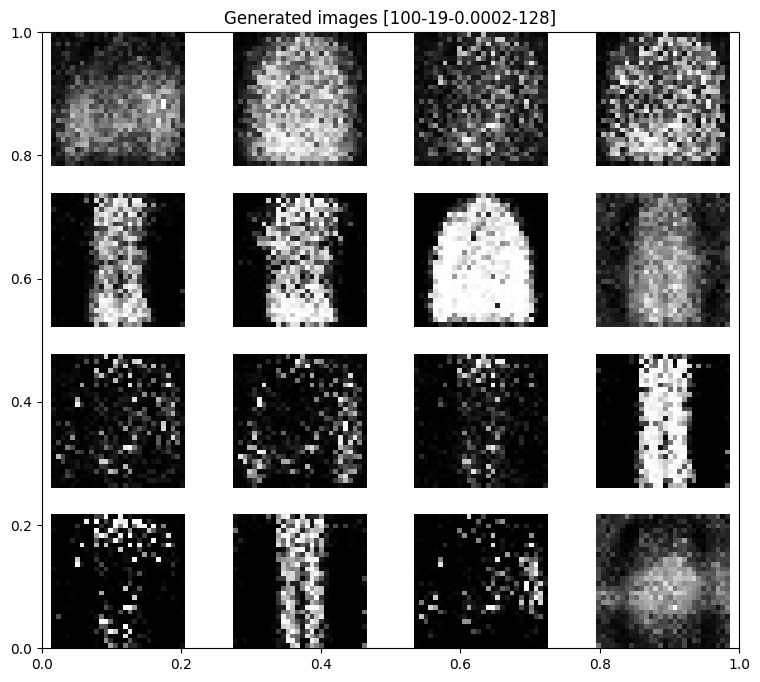

Epoch[ 30/100] ===== Discriminator Loss: 0.9731 ===== Generator Loss: 1.6497 ===== FID Score: 1.2604 ===== Inception Score: 2.8452 +/- 0.1143
Epoch[ 40/100] ===== Discriminator Loss: 1.0298 ===== Generator Loss: 1.4898 ===== FID Score: 1.1644 ===== Inception Score: 2.4992 +/- 0.0858
Epoch[ 50/100] ===== Discriminator Loss: 1.1179 ===== Generator Loss: 1.2850 ===== FID Score: 0.7597 ===== Inception Score: 2.9925 +/- 0.0754


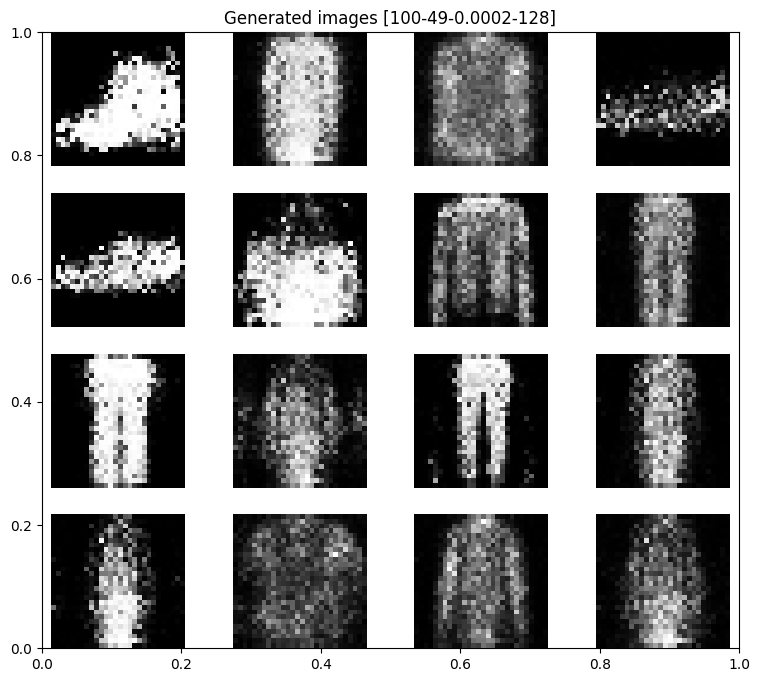

Epoch[ 60/100] ===== Discriminator Loss: 1.1954 ===== Generator Loss: 1.1802 ===== FID Score: 0.7871 ===== Inception Score: 2.6326 +/- 0.1259
Epoch[ 70/100] ===== Discriminator Loss: 1.1968 ===== Generator Loss: 1.1669 ===== FID Score: 0.7682 ===== Inception Score: 2.9893 +/- 0.0803
Epoch[ 80/100] ===== Discriminator Loss: 1.1648 ===== Generator Loss: 1.2772 ===== FID Score: 0.6104 ===== Inception Score: 2.7356 +/- 0.0887
Epoch[ 90/100] ===== Discriminator Loss: 1.1116 ===== Generator Loss: 1.3114 ===== FID Score: 0.6168 ===== Inception Score: 2.6150 +/- 0.0957
Epoch[100/100] ===== Discriminator Loss: 1.1600 ===== Generator Loss: 1.1400 ===== FID Score: 1.0874 ===== Inception Score: 2.8744 +/- 0.1435


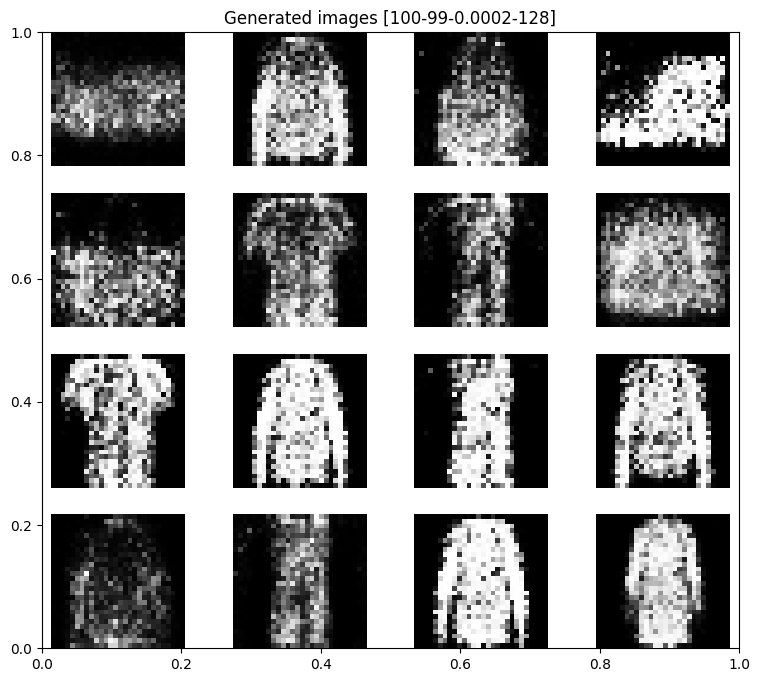

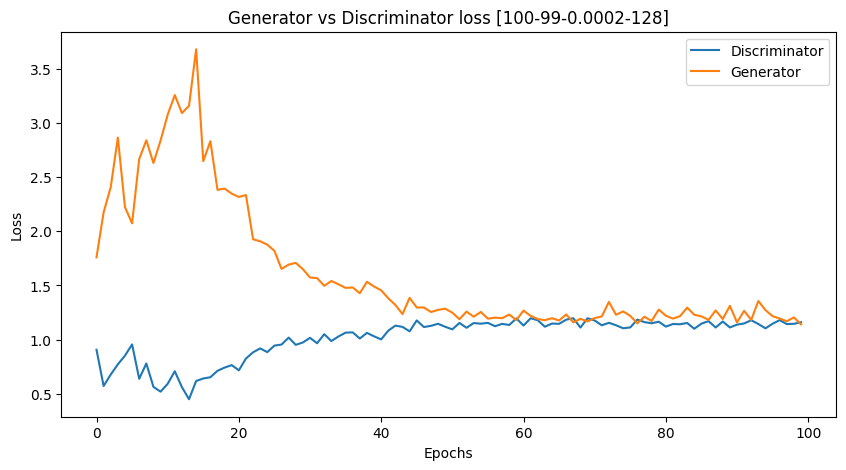

In [ ]:
gan = GenerativeAdversarialNet(
    noise_dim = NOISE_DIMENSION,
    discriminator_criterion = D_CRITERION,
    generator_criterion = G_CRITERION,
    discriminator_learning_rate = LEARNING_RATE,
    generator_learning_rate= LEARNING_RATE,
    device = device,
    is_conditional = False,
    dc = False
)
d_losses = []
g_losses = []
train_loader, _, _ = fmd.get_loaders(BATCH_SIZE)
fixed_noise = torch.randn(16, NOISE_DIMENSION, device=device)
for epoch in range(NUM_EPOCH):
    d_loss, g_loss = gan.train_one_epoch(train_loader)
    d_losses.append(d_loss)
    g_losses.append(g_loss)
    if epoch % 10 == 9:
        fid = calculate_fid(
            generator=gan.generator, 
            dataloader=train_loader, 
            device=gan.device, 
            noise_dim=gan.noise_dim,
            num_classes=gan.num_classes
        )
        is_mean, is_std = calculate_inception_score(
            generator=gan.generator, 
            device=gan.device, 
            noise_dim=gan.noise_dim, 
            num_classes=gan.num_classes,
            n_samples=2000
        )
        print(
            f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
            f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
            f'Generator Loss: {g_loss:.4f}', '=' * 5,
            f'FID Score: {fid:.4f}', '=' * 5,
            f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
        )
    if epoch + 1 in NUM_EPOCH_LIST:
        plot_fake_images(gan, fixed_noise, f'Generated images [{NOISE_DIMENSION}-{epoch}-{LEARNING_RATE}-{BATCH_SIZE}]')
generator_discriminator_loss(d_losses, g_losses, f'Generator vs Discriminator loss [{NOISE_DIMENSION}-{epoch}-{LEARNING_RATE}-{BATCH_SIZE}]')

### B.

#### 1. The Optimal Learning Rate and Justification

The **optimal learning rate** is the one that achieves the best balance between the Generator (G) and the Discriminator (D), allowing them to converge to a stable Nash Equilibrium where neither network dominates.

<img src=".\Output\Part1\B\lr0.001.loss.png" alt="lr 0.001" width="475" height="350"/>
<img src=".\Output\Part1\B\lr0.0002.loss.png" alt="lr 0.0002" width="475" height="350"/>
<img src=".\Output\Part1\B\lr0.0001.loss.png" alt="lr 0.0001" width="475" height="350"/><br>


In many successful GAN implementations, particularly those based on DCGAN (Deep Convolutional GAN), a learning rate of 0.0002 for the Adam optimizer is found to be the most effective starting point.

| Learning Rate (LR) | Typical Outcome on Vanilla GAN |
| --- | --- |
| **0.0002** | **Optimal:** Stable convergence and highest visual quality. |
| **0.0001** | Too Low: Slow convergence, risk of Discriminator overpowering. |
| **0.001** | Too High: Training instability, oscillations, and non-convergence. |


- **Why 0.0002 Works Best?**
    - **Balanced Competition:** The adversarial nature of GANs requires a delicate balance. A moderate rate like 0.0002 ensures that the steps taken by both G and D are small enough to prevent one from overwhelming the other, promoting a stable, sustainable 'tug-of-war'. Which in this criteria 0.001 is not a good choice
    - **Stable Convergence:** This rate typically allows the loss curves to gradually converge and stabilize around the optimal value ($\approx 0.69$, or $\ln(2)$), leading to high-quality image generation without the loss curves constantly oscillating. As we can see even after 100 epochs model with 0.0001 learning rate doesn't converge.


#### 2. Analysis of Instabilities and Failures

Instability in GAN training primarily arises from the **non-cooperative, non-convex, two-player game** between G and D. The learning rate directly controls the magnitude of the updates in this game.

- Instability at a High Learning Rate (e.g., 0.001): A high learning rate forces the optimizer to take large steps in the parameter space.
    - Instability Type: **Non-Convergence** and **Oscillation**.
    - Where it Happens: Loss curves will be highly volatile and may not settle down. The Discriminator's loss may spike, and the Generator's loss may jump erratically, preventing the model from reaching the Nash Equilibrium.
    - Why it Happens: Large gradient updates cause the model parameters to **overshoot** the optimal point (the saddle point). The networks constantly chase each other, failing to settle. This can result in **Gradient Explosion** or cause the Generator to find a quick, but non-general, way to trick the Discriminator, which immediately causes the Discriminator to update dramatically to counteract it.

- Instability at a Low Learning Rate (e.g., 0.0001): A learning rate that is too low can result in very slow progress, but its most critical failure mode is the **imbalance of power**.
    - Instability Type: **Vanishing Gradients** for the Generator.
    - Where it Happens: Early in training, the Discriminator (D) quickly learns to perfectly separate real from fake samples.
    - Why it Happens: When D becomes too powerful, its classification of generated images is close to  (Fake) or  (Real). The corresponding gradients flowing back to the Generator become vanishingly small (i.e., near zero). This effectively **starves the Generator of a meaningful learning signal**, causing it to stall and produce blurry or abstract outputs because it has no incentive to improve its samples.

**Summary of Loss Dynamics**

| Loss Feature | High LR () | Optimal LR () | Low LR () |
| --- | --- | --- | --- |
| **Loss Curve Behavior** | Extreme **Oscillation** | Stable **Convergence** | Slow,  **Stalling** |
| **Final Image Quality** | Highly **Noisy/Junk** | **Best** Coherence and Detail | **Blurry** or **Abstract** |
| **Primary Failure** | Non-Convergence/Overshooting | Balance Maintained | Vanishing Gradients/Stall |


#### 3. Output Comparison (Visual Quality)

- **Learning Rate: 0.0001 (Too Low)**

<img src=".\Output\Part1\B\lr0.0001.sample.png" alt="lr 0.0001" width="400" height="400"/><br>
The generated images show recognizable, though blurry and noisy, clothing items (mostly shirts and sweaters), with some structure, but many samples appear distorted or have large black/white artifacts.

- **Learning Rate: 0.0002 (Optimal)**

<img src=".\Output\Part1\B\lr0.0002.sample.png" alt="lr 0.0002" width="400" height="400"/><br>
The generated images (Epoch 100) are the most coherent and structured of all three samples, clearly representing various items like T-shirts, dresses, and trousers, with well-defined outlines and minimal black/white artifacts.

- **Learning Rate: 0.001 (Too High)**

<img src=".\Output\Part1\B\lr0.001.sample.png" alt="lr 0.001" width="400" height="400"/><br>
The generated images are completely abstract, appearing as rigid, repeating black and white checkerboard patterns with no discernible relationship to the Fashion-MNIST data.


#### 4. Mode Collapse

- The provided images vividly illustrate how the learning rate (LR) hyperparameter significantly influences the stability and mode-collapse behavior of a Generative Adversarial Network (GAN). Mode collapse occurs when the generator model fails to capture the full diversity of the training data distribution, instead producing only a limited set of repetitive or identical samples.1 By inspecting the generated images from the three models, a clear relationship between the LR magnitude and the severity of mode collapse can be observed.

- The model trained with the highest learning rate ($LR=0.001$) exhibits the most extreme case of mode collapse, as seen in the lr0.001.sample.png image. Nearly all 16 generated samples are essentially identical, featuring a specific, high-contrast, black-and-white pattern. This suggests the generator quickly found a single, non-diverse output that successfully confused the discriminator, and then became fixated on generating only that output, demonstrating a near-complete collapse to a single mode of the potential data distribution. High learning rates often lead to instability, causing the generator to take massive steps that allow it to over-optimize for a specific weakness in the discriminator, which is the key mechanism driving mode collapse.

- Conversely, models trained with lower learning rates, $LR=0.0002$ and $LR=0.0001$, show a much greater degree of sample diversity, suggesting better mode coverage. Qualitatively analyzing the $4 \times 4$ grids, the $LR=0.0002$ model appears to produce samples belonging to roughly 3-4 distinct categories (modes), such as a highly-collapsed white shape, a dark/textured image, and a roughly-defined garment/torso shape. The $LR=0.0001$ model, however, generates the most diverse output, exhibiting variations that could be clustered into 6 or more distinct visual categories (e.g., specific t-shirt shapes, different levels of abstract texture, and distinct body orientations). This increased diversity at the lowest LR highlights that a sufficiently small learning rate is often crucial for maintaining training stability and allowing both the generator and discriminator to explore the objective function landscape more slowly and thoroughly, which is essential to prevent the generator from collapsing onto a limited set of easily-learned features. The comparison strongly suggests that while $LR=0.0002$ mitigates the complete collapse seen at $LR=0.001$, the further reduction to $LR=0.0001$ yields a measurable, non-linear improvement in the generator's ability to cover a broader range of the target data distribution.

Training model with Learning rate 0.001


d:\Masters\Deep.Learning\Projects\HW2\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Epoch[ 10/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 12.8811 ===== FID Score: 14.7201 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[ 20/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 15.8126 ===== FID Score: 16.2525 ===== Inception Score: 1.0000 +/- 0.0000


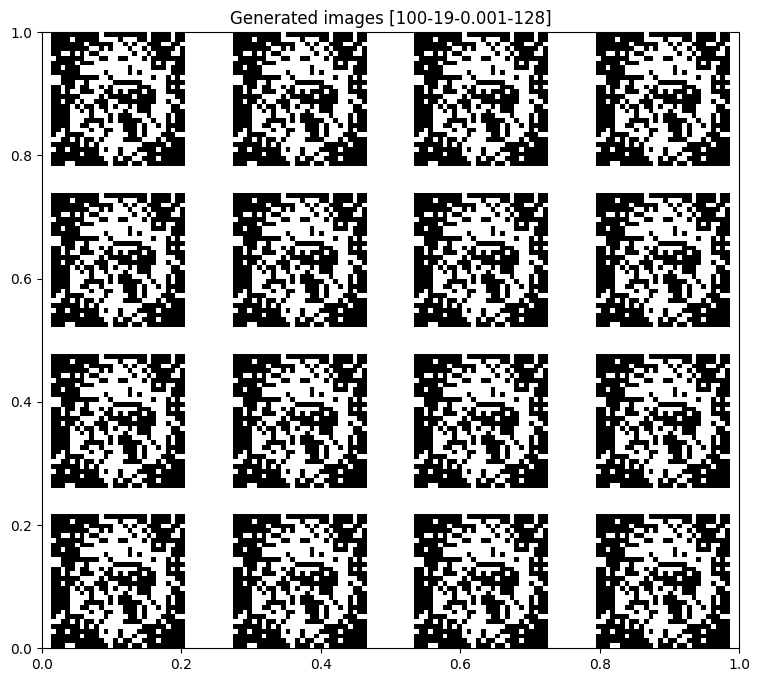

Epoch[ 30/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 15.1230 ===== FID Score: 9.4399 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[ 40/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 17.3306 ===== FID Score: 9.3395 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[ 50/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 18.9113 ===== FID Score: 9.3703 ===== Inception Score: 1.0000 +/- 0.0000


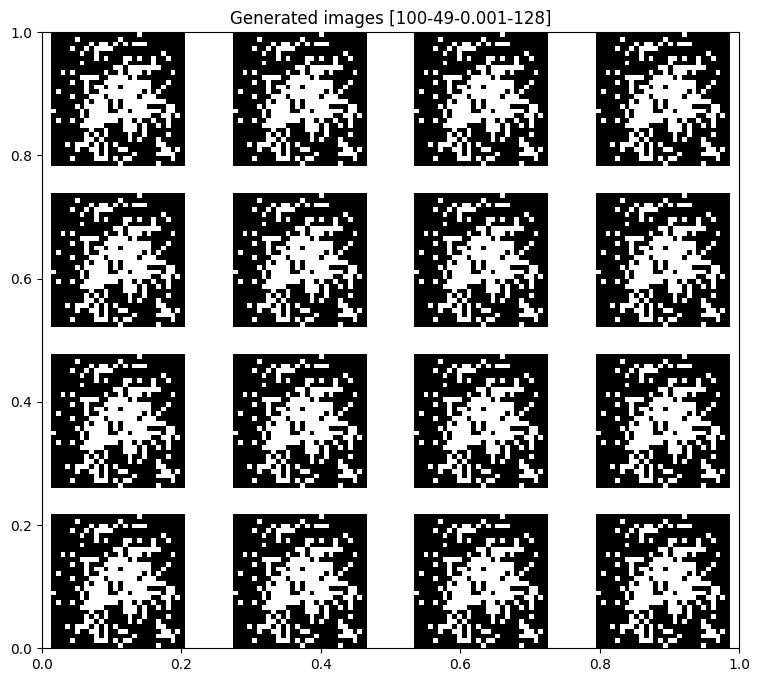

Epoch[ 60/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 20.7850 ===== FID Score: 9.3703 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[ 70/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 22.4058 ===== FID Score: 9.3703 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[ 80/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 14.8521 ===== FID Score: 9.8802 ===== Inception Score: 1.0050 +/- 0.0011
Epoch[ 90/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 17.6033 ===== FID Score: 9.4254 ===== Inception Score: 1.0000 +/- 0.0000
Epoch[100/100] ===== Discriminator Loss: 0.0000 ===== Generator Loss: 18.3674 ===== FID Score: 10.1280 ===== Inception Score: 1.0000 +/- 0.0000


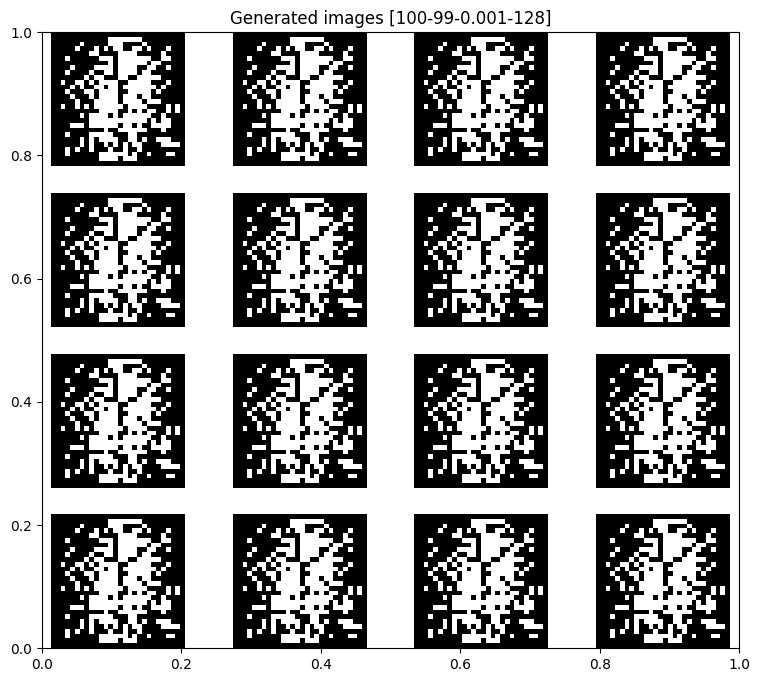

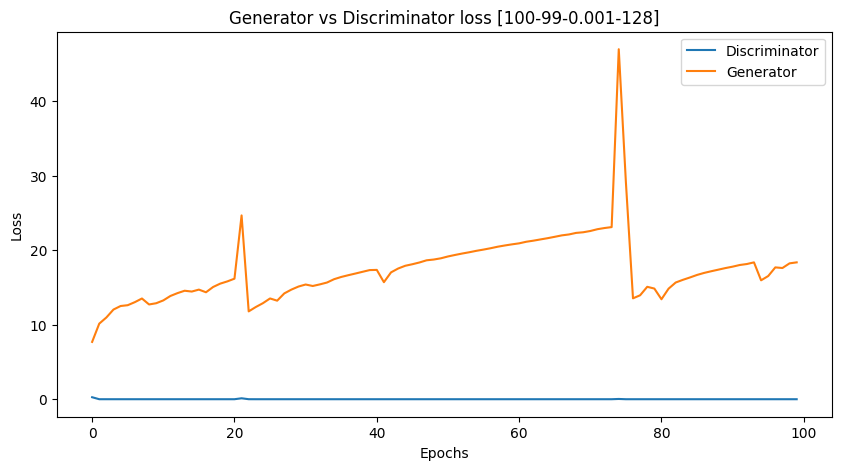

Training model with Learning rate 0.0002
Epoch[ 10/100] ===== Discriminator Loss: 0.5187 ===== Generator Loss: 2.8372 ===== FID Score: 1.3337 ===== Inception Score: 1.8948 +/- 0.0354
Epoch[ 20/100] ===== Discriminator Loss: 0.7638 ===== Generator Loss: 2.3476 ===== FID Score: 1.9130 ===== Inception Score: 2.4492 +/- 0.0585


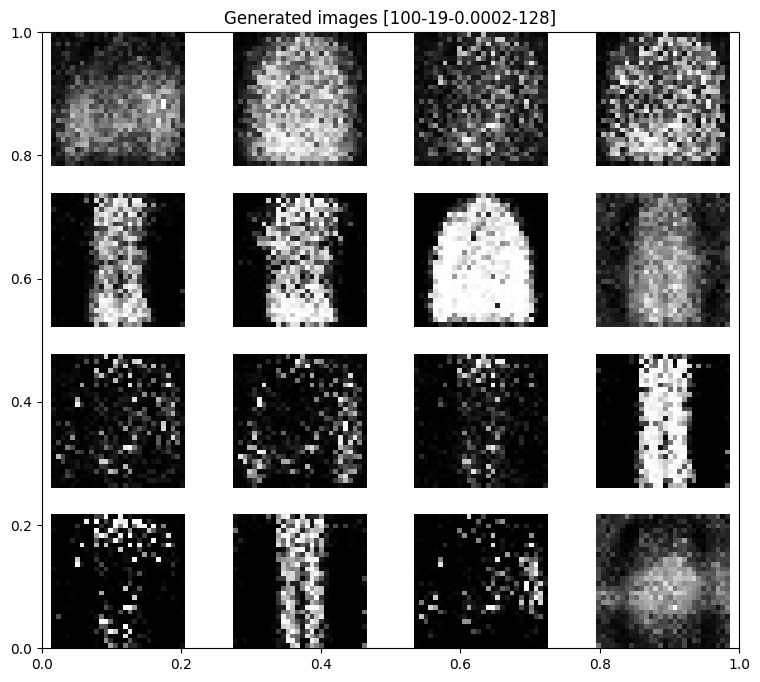

Epoch[ 30/100] ===== Discriminator Loss: 0.9731 ===== Generator Loss: 1.6497 ===== FID Score: 1.2604 ===== Inception Score: 2.8452 +/- 0.1143
Epoch[ 40/100] ===== Discriminator Loss: 1.0298 ===== Generator Loss: 1.4898 ===== FID Score: 1.1644 ===== Inception Score: 2.4992 +/- 0.0858
Epoch[ 50/100] ===== Discriminator Loss: 1.1179 ===== Generator Loss: 1.2850 ===== FID Score: 0.7597 ===== Inception Score: 2.9925 +/- 0.0754


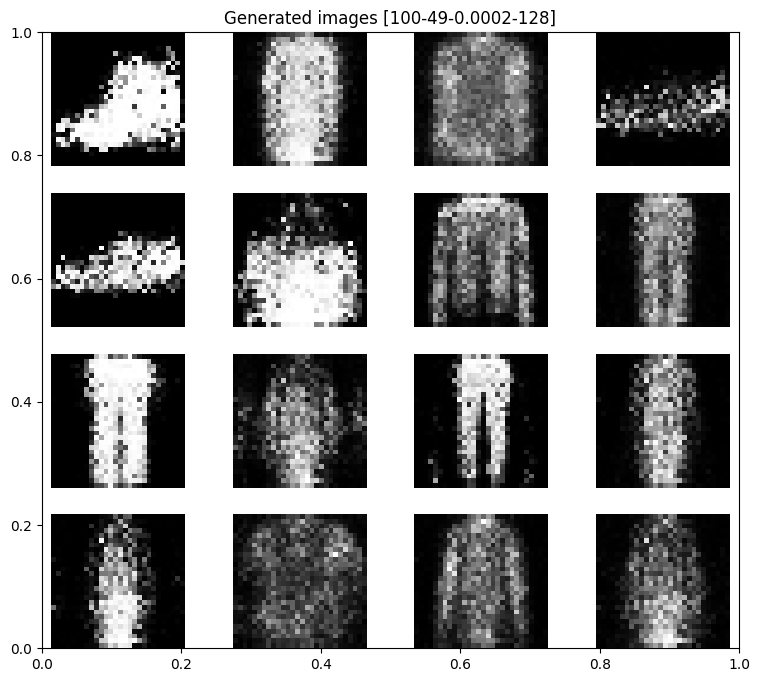

Epoch[ 60/100] ===== Discriminator Loss: 1.1954 ===== Generator Loss: 1.1802 ===== FID Score: 0.7871 ===== Inception Score: 2.6326 +/- 0.1259
Epoch[ 70/100] ===== Discriminator Loss: 1.1968 ===== Generator Loss: 1.1669 ===== FID Score: 0.7682 ===== Inception Score: 2.9893 +/- 0.0803
Epoch[ 80/100] ===== Discriminator Loss: 1.1648 ===== Generator Loss: 1.2772 ===== FID Score: 0.6104 ===== Inception Score: 2.7356 +/- 0.0887
Epoch[ 90/100] ===== Discriminator Loss: 1.1116 ===== Generator Loss: 1.3114 ===== FID Score: 0.6168 ===== Inception Score: 2.6150 +/- 0.0957
Epoch[100/100] ===== Discriminator Loss: 1.1600 ===== Generator Loss: 1.1400 ===== FID Score: 1.0874 ===== Inception Score: 2.8744 +/- 0.1435


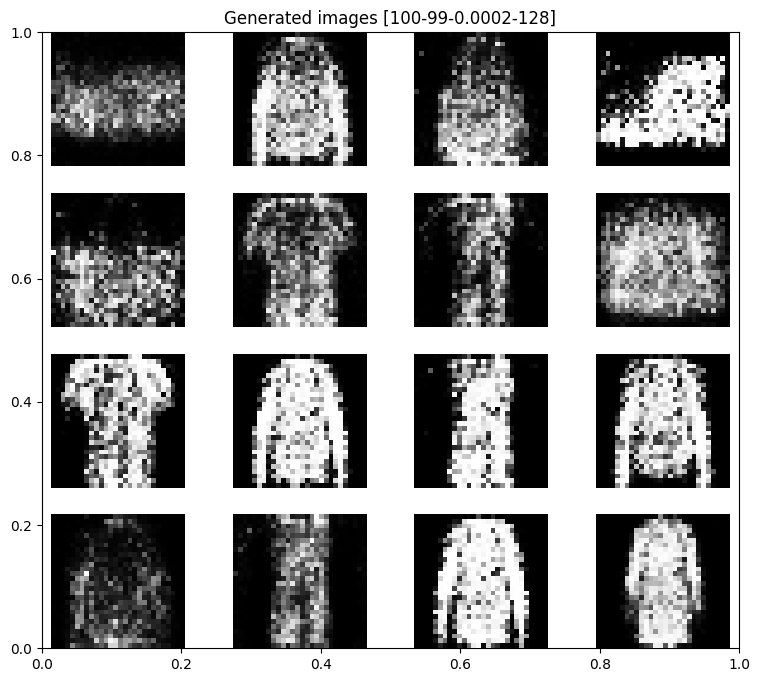

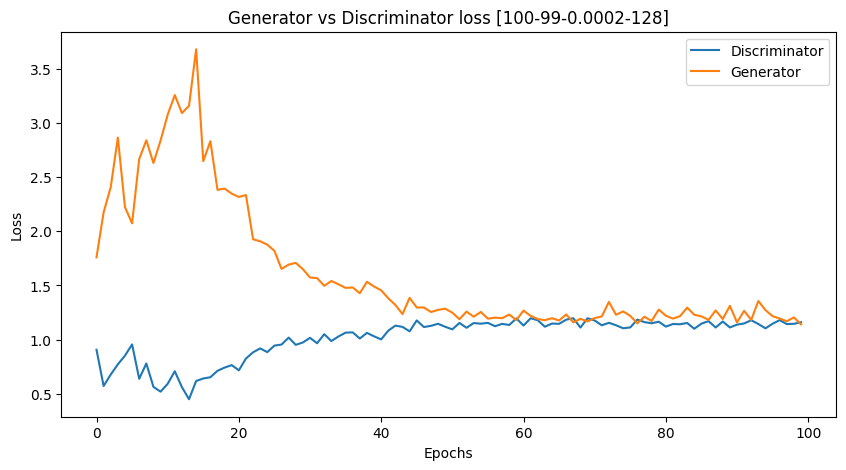

Training model with Learning rate 0.0001
Epoch[ 10/100] ===== Discriminator Loss: 0.5972 ===== Generator Loss: 2.6034 ===== FID Score: 3.6565 ===== Inception Score: 1.2950 +/- 0.0090
Epoch[ 20/100] ===== Discriminator Loss: 0.5807 ===== Generator Loss: 2.9059 ===== FID Score: 1.7642 ===== Inception Score: 2.0319 +/- 0.0396


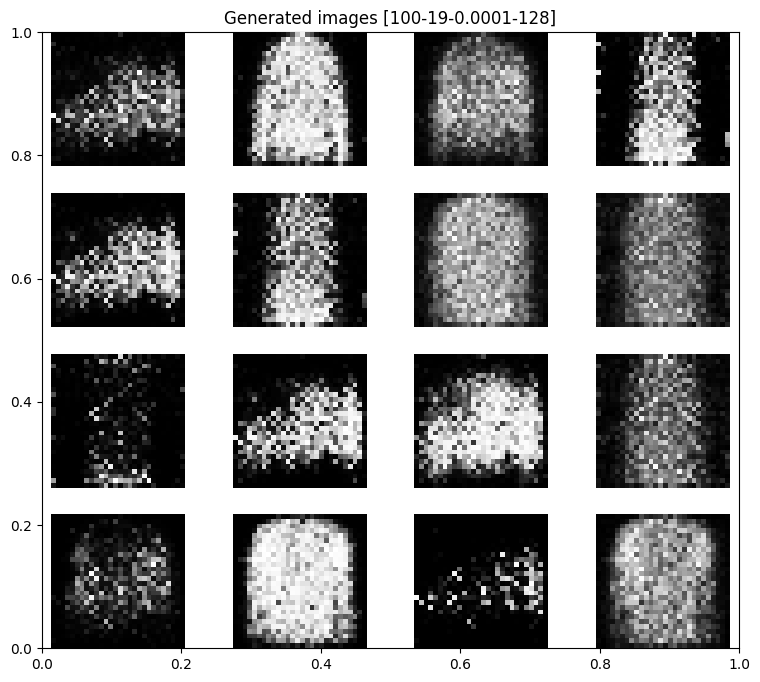

Epoch[ 30/100] ===== Discriminator Loss: 0.6844 ===== Generator Loss: 2.0211 ===== FID Score: 0.9536 ===== Inception Score: 2.4878 +/- 0.0714
Epoch[ 40/100] ===== Discriminator Loss: 0.7609 ===== Generator Loss: 2.1435 ===== FID Score: 1.3331 ===== Inception Score: 2.4888 +/- 0.0899
Epoch[ 50/100] ===== Discriminator Loss: 0.8004 ===== Generator Loss: 1.9032 ===== FID Score: 0.9684 ===== Inception Score: 2.3881 +/- 0.0761


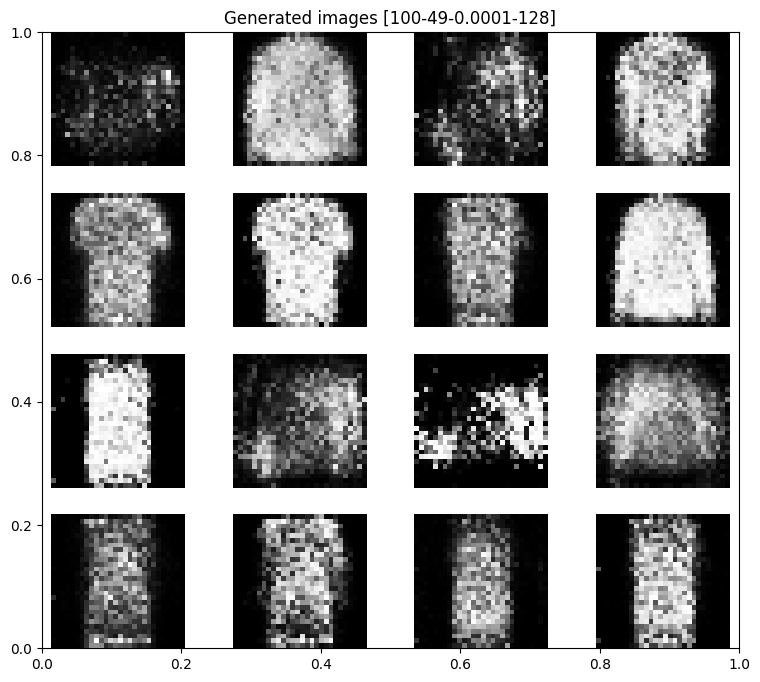

Epoch[ 60/100] ===== Discriminator Loss: 0.8439 ===== Generator Loss: 1.6980 ===== FID Score: 0.8045 ===== Inception Score: 2.4049 +/- 0.0864
Epoch[ 70/100] ===== Discriminator Loss: 0.7967 ===== Generator Loss: 1.7969 ===== FID Score: 0.8773 ===== Inception Score: 2.6826 +/- 0.0963
Epoch[ 80/100] ===== Discriminator Loss: 0.8503 ===== Generator Loss: 1.8101 ===== FID Score: 0.9841 ===== Inception Score: 2.8228 +/- 0.0919
Epoch[ 90/100] ===== Discriminator Loss: 0.8558 ===== Generator Loss: 1.6056 ===== FID Score: 0.6375 ===== Inception Score: 2.5176 +/- 0.0807
Epoch[100/100] ===== Discriminator Loss: 0.8858 ===== Generator Loss: 1.6015 ===== FID Score: 0.6507 ===== Inception Score: 2.7131 +/- 0.1033


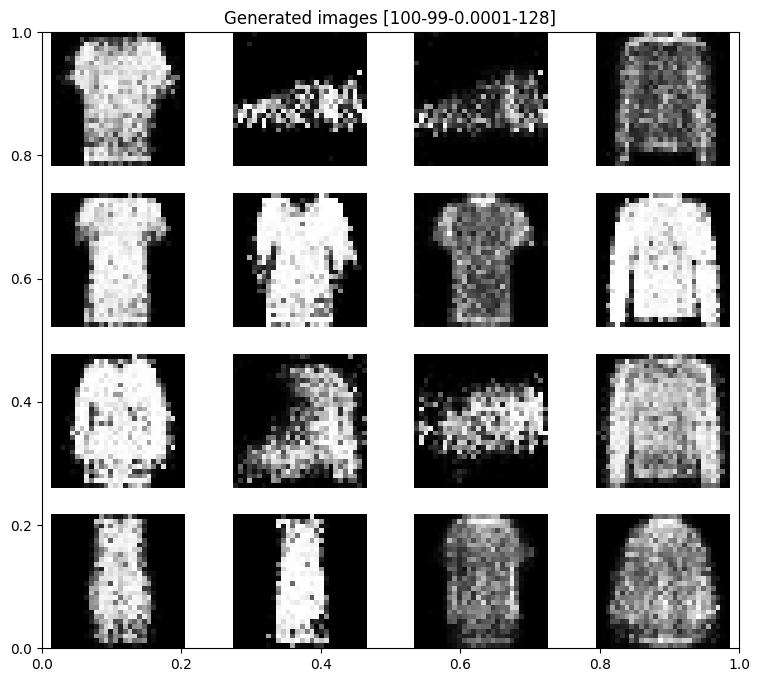

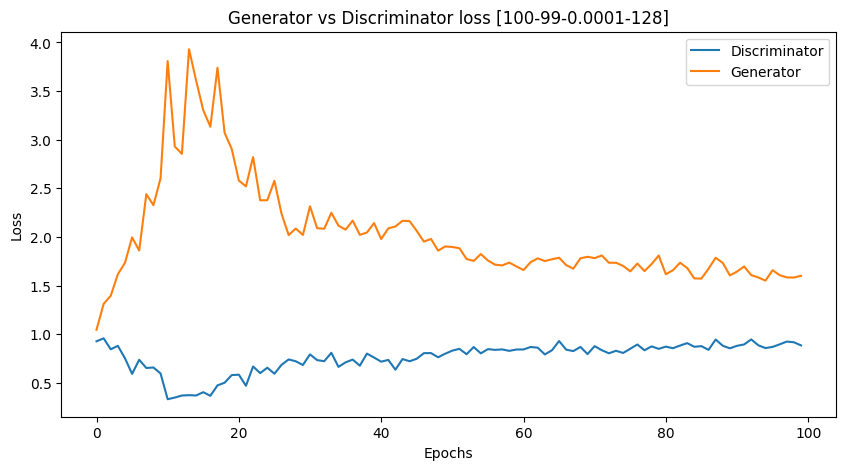

In [27]:
for lr in LEARNING_RATE_LIST:
    print('Training model with Learning rate', lr)
    gan = GenerativeAdversarialNet(
        noise_dim = NOISE_DIMENSION,
        discriminator_criterion = D_CRITERION,
        generator_criterion = G_CRITERION,
        discriminator_learning_rate = lr,
        generator_learning_rate= lr,
        device = device,
        is_conditional = False,
        dc = False
    )
    d_losses = []
    g_losses = []
    train_loader, _, _ = fmd.get_loaders(BATCH_SIZE)
    fixed_noise = torch.randn(16, NOISE_DIMENSION, device=device)
    for epoch in range(NUM_EPOCH):
        d_loss, g_loss = gan.train_one_epoch(train_loader)
        d_losses.append(d_loss)
        g_losses.append(g_loss)
        if epoch % 10 == 9:
            fid = calculate_fid(
                generator=gan.generator, 
                dataloader=train_loader, 
                device=gan.device, 
                noise_dim=gan.noise_dim,
                num_classes=gan.num_classes
            )
            is_mean, is_std = calculate_inception_score(
                generator=gan.generator, 
                device=gan.device, 
                noise_dim=gan.noise_dim, 
                num_classes=gan.num_classes,
                n_samples=2000
            )
            print(
                f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
                f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
                f'Generator Loss: {g_loss:.4f}', '=' * 5,
                f'FID Score: {fid:.4f}', '=' * 5,
                f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
            )
        if epoch + 1 in NUM_EPOCH_LIST:
            plot_fake_images(gan, fixed_noise, f'Generated images [{NOISE_DIMENSION}-{epoch}-{lr}-{BATCH_SIZE}]')
    generator_discriminator_loss(d_losses, g_losses, f'Generator vs Discriminator loss [{NOISE_DIMENSION}-{epoch}-{lr}-{BATCH_SIZE}]')

### C.

The **noise dimension** (also known as the latent vector size, Z) is the input to the Generator. It determines the **capacity** for the Generator to learn different features and variations within the dataset, directly impacting the diversity and quality of the generated images.

#### 1. Analysis of Noise Dimension Impact


<img src=".\Output\Part1\C\noise32.sample.png" alt="Z 32" width="400" height="400"/><br>

- Noise Dimension (**32**)
    - Visual Quality (Diversity & Coherence): Generated images show coarse structure and limited diversity, with many samples looking similar or overly simplistic. **Images lack detail**. 
    - Loss Dynamics: The losses stabilize reasonably well, but the inherent complexity is too low to model the full data distribution.


<img src=".\Output\Part1\C\noise100.sample.png" alt="Z 100" width="400" height="400"/><br>

- Noise Dimension (**100**)
    - Visual Quality (Diversity & Coherence): Generated images show clear clothing items with better structure and a good range of different articles (shirts, trousers, etc.), suggesting improved **diversity**. This appears to be the most visually coherent set.
    - Loss Dynamics: The losses converge smoothly and are well-balanced (D loss , G loss  at Epoch 100), indicating a stable adversarial game.


<img src=".\Output\Part1\C\noise200.sample.png" alt="Z 200" width="400" height="400"/><br>

- Noise Dimension (**200**)
    - Visual Quality (Diversity & Coherence): Generated images show some recognizable forms but also more **noise and artifacts** compared to . Many samples look blurry or distorted, suggesting the model is struggling to map the high-dimensional noise efficiently.
    - Loss Dynamics: The losses are balanced (D loss , G loss  at Epoch 100), but the slightly higher D loss suggests the samples are becoming harder for D to classify, possibly due to increased variation and noise.

**In summary:** Increasing the noise dimension from 32 to 100 provides the Generator with enough capacity to capture the necessary **diversity** and structure of the Fashion-MNIST dataset, leading to an optimal visual result. However, increasing the dimension further to 200 introduces unnecessary complexity, leading to **diminished visual quality** (more noise and less coherence) without providing a significant boost in diversity.



#### 2. Comparison Using FID and Inception Score (IS)

**FID (Fréchet Inception Distance):** Measures the similarity between the distribution of real and generated images. **Lower is better** (closer to 0). It is a better indicator of *quality* and *realism*.

**IS (Inception Score):** Measures the *quality* (each image is recognizable) and *diversity* (high entropy across classes) of generated images. **Higher is better**.

| Metric | Z=32 (Epoch 100) | Z=100 (Epoch 100) | Z=200 (Epoch 100) |
| --- | --- | --- | --- |
| **Final FID Score** | **0.5193** | 1.0874 | 0.9301 |
| **Final Inception Score** | 2.6008 | 2.8744 | **2.9915** |
| **Best FID (Any Epoch)** | **0.5193** (E100) | 0.6104 (E80) | 0.6556 (E60) |
| **Best IS (Any Epoch)** | 2.9620 (E70) | **2.9925** (E50) | 2.9915 (E100) |


##### Analysis of Scores:

1. **FID Contradiction:** The $Z=32$ model achieves the lowest final FID (0.5193). This often indicates that the generator has captured a very compact, small distribution of the real data effectively  (low mode collapse severity for the modes it did capture), but its visual samples appear simplistic compared to $Z=100$. The $Z=100$ and $Z=200$ models have higher final FID scores, suggesting their distribution is slightly less accurate overall.
2. **Inception Score Consistency:** The $Z=200$ model achieves the highest final IS (2.9915), closely followed by $Z=100$ (2.8744). Since the Fashion-MNIST dataset has 10 classes, an IS near 3 indicates a strong ability to generate diverse and distinct samples that are highly recognizable by the Inception model.



#### 3. Conclusion: The Best Noise Dimension

The **best noise dimension is $Z=100$** (or potentially $Z=200$, though $Z=100$ is more efficient) because it provides the Generator with the optimal balance for the task. Also we should consider that a model with less parameters is always better in generalization.

While $Z=32$ has the lowest final FID, its visual output is clearly the least diverse and most simplistic. The best-performing model should excel in **both** realism (FID) and diversity/quality (IS).

* The $Z=100$ and $Z=200$ models achieve the highest Inception Scores, indicating they are superior at modeling the **diversity** and **class separation** of the Fashion-MNIST dataset.
* The $Z=100$ model strikes the best balance, delivering a high IS and visually coherent samples, making it the most practical choice. The minimal gain in IS from $Z=100$ to $Z=200$ is not worth the increase in computational complexity and the introduction of visual noise.

In [22]:
best_lr = 0.0002

Training model with Learning rate 0.0002 and noise dimension 32


d:\Masters\Deep.Learning\Projects\HW2\.venv\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Epoch[ 10/100] ===== Discriminator Loss: 0.6867 ===== Generator Loss: 3.6776 ===== FID Score: 2.5929 ===== Inception Score: 1.6564 +/- 0.0371
Epoch[ 20/100] ===== Discriminator Loss: 0.8094 ===== Generator Loss: 2.1621 ===== FID Score: 1.2961 ===== Inception Score: 2.3185 +/- 0.0732


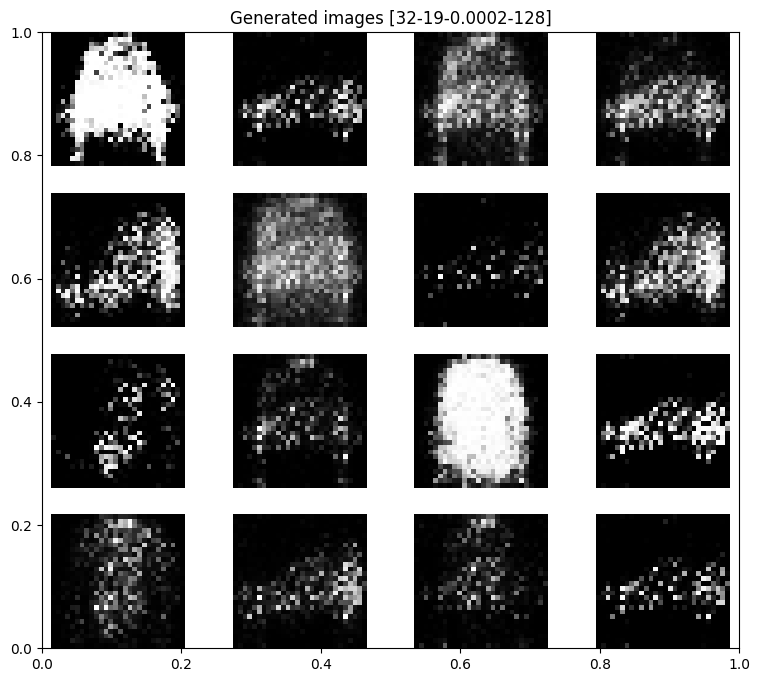

Epoch[ 30/100] ===== Discriminator Loss: 0.9198 ===== Generator Loss: 1.7893 ===== FID Score: 0.5363 ===== Inception Score: 2.7877 +/- 0.0554
Epoch[ 40/100] ===== Discriminator Loss: 1.0522 ===== Generator Loss: 1.3097 ===== FID Score: 0.7995 ===== Inception Score: 2.4629 +/- 0.0907
Epoch[ 50/100] ===== Discriminator Loss: 1.2086 ===== Generator Loss: 1.2751 ===== FID Score: 0.5525 ===== Inception Score: 2.6120 +/- 0.0785


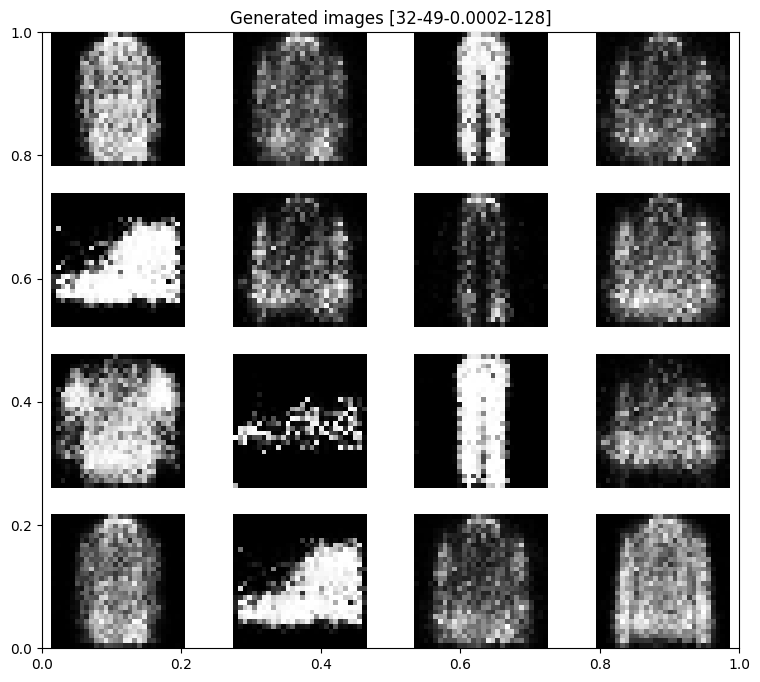

Epoch[ 60/100] ===== Discriminator Loss: 1.0198 ===== Generator Loss: 1.3603 ===== FID Score: 0.8038 ===== Inception Score: 2.7871 +/- 0.0868
Epoch[ 70/100] ===== Discriminator Loss: 1.0939 ===== Generator Loss: 1.4007 ===== FID Score: 0.5277 ===== Inception Score: 2.9620 +/- 0.1475
Epoch[ 80/100] ===== Discriminator Loss: 1.0991 ===== Generator Loss: 1.2556 ===== FID Score: 0.7348 ===== Inception Score: 2.7276 +/- 0.1137
Epoch[ 90/100] ===== Discriminator Loss: 1.1129 ===== Generator Loss: 1.1813 ===== FID Score: 1.1975 ===== Inception Score: 2.3321 +/- 0.0922
Epoch[100/100] ===== Discriminator Loss: 1.0979 ===== Generator Loss: 1.3692 ===== FID Score: 0.5193 ===== Inception Score: 2.6008 +/- 0.0869


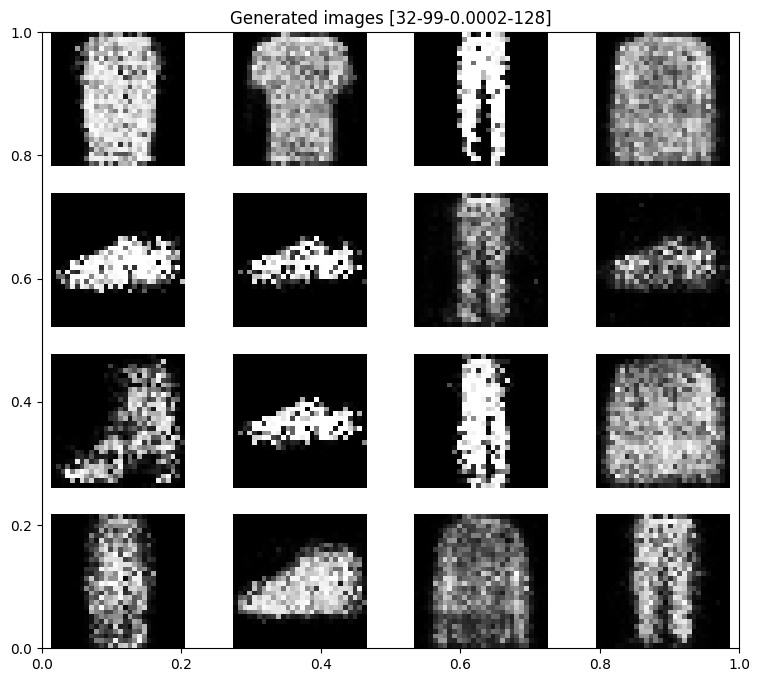

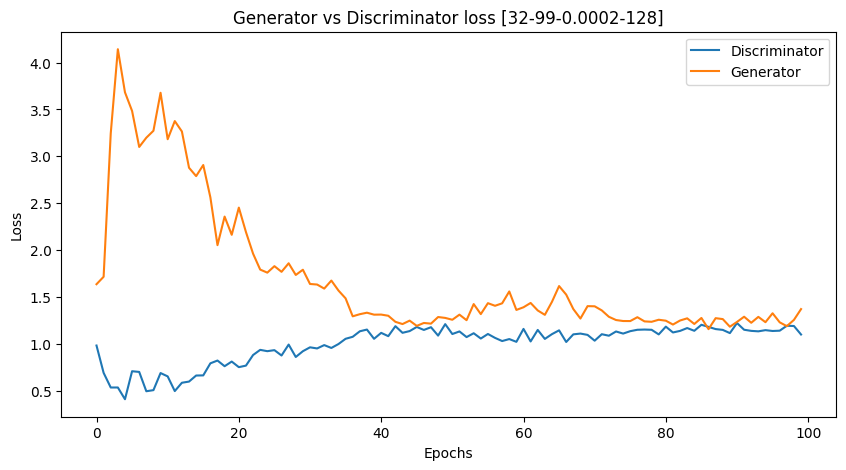

Training model with Learning rate 0.0002 and noise dimension 100
Epoch[ 10/100] ===== Discriminator Loss: 0.5187 ===== Generator Loss: 2.8372 ===== FID Score: 1.3337 ===== Inception Score: 1.8948 +/- 0.0354
Epoch[ 20/100] ===== Discriminator Loss: 0.7638 ===== Generator Loss: 2.3476 ===== FID Score: 1.9130 ===== Inception Score: 2.4492 +/- 0.0585


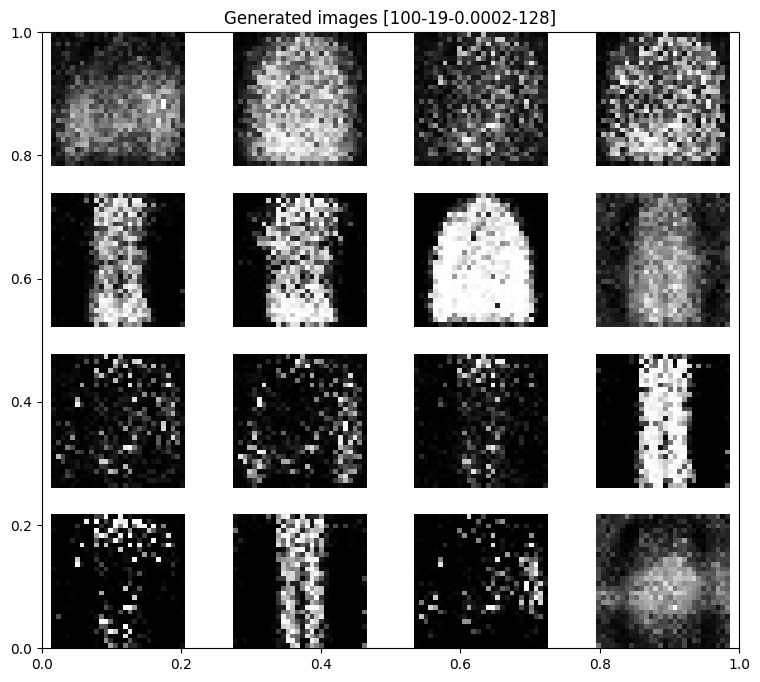

Epoch[ 30/100] ===== Discriminator Loss: 0.9731 ===== Generator Loss: 1.6497 ===== FID Score: 1.2604 ===== Inception Score: 2.8452 +/- 0.1143
Epoch[ 40/100] ===== Discriminator Loss: 1.0298 ===== Generator Loss: 1.4898 ===== FID Score: 1.1644 ===== Inception Score: 2.4992 +/- 0.0858
Epoch[ 50/100] ===== Discriminator Loss: 1.1179 ===== Generator Loss: 1.2850 ===== FID Score: 0.7597 ===== Inception Score: 2.9925 +/- 0.0754


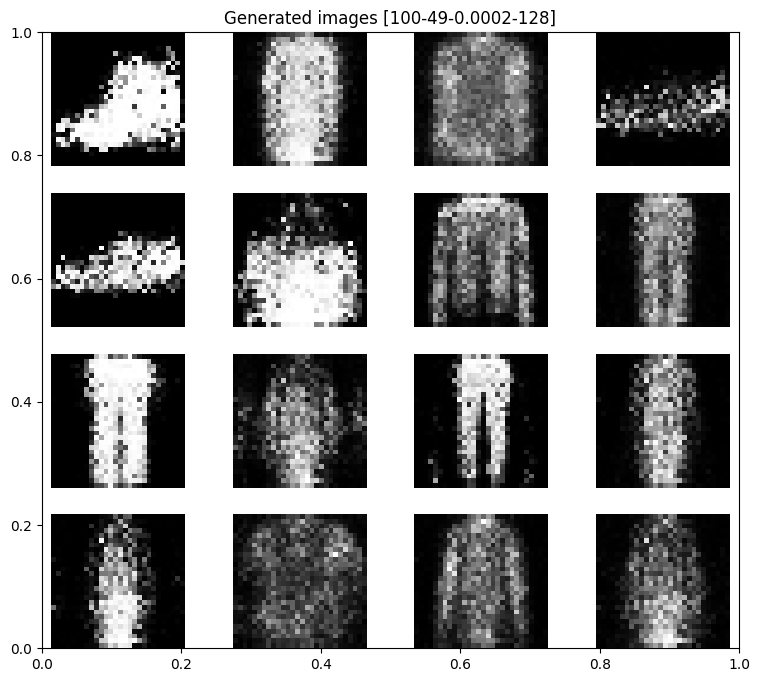

Epoch[ 60/100] ===== Discriminator Loss: 1.1954 ===== Generator Loss: 1.1802 ===== FID Score: 0.7871 ===== Inception Score: 2.6326 +/- 0.1259
Epoch[ 70/100] ===== Discriminator Loss: 1.1968 ===== Generator Loss: 1.1669 ===== FID Score: 0.7682 ===== Inception Score: 2.9893 +/- 0.0803
Epoch[ 80/100] ===== Discriminator Loss: 1.1648 ===== Generator Loss: 1.2772 ===== FID Score: 0.6104 ===== Inception Score: 2.7356 +/- 0.0887
Epoch[ 90/100] ===== Discriminator Loss: 1.1116 ===== Generator Loss: 1.3114 ===== FID Score: 0.6168 ===== Inception Score: 2.6150 +/- 0.0957
Epoch[100/100] ===== Discriminator Loss: 1.1600 ===== Generator Loss: 1.1400 ===== FID Score: 1.0874 ===== Inception Score: 2.8744 +/- 0.1435


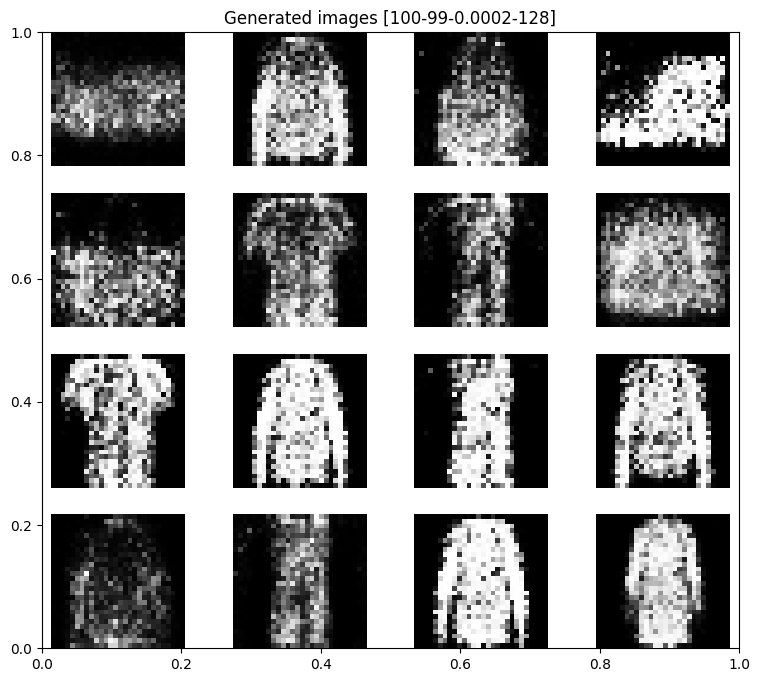

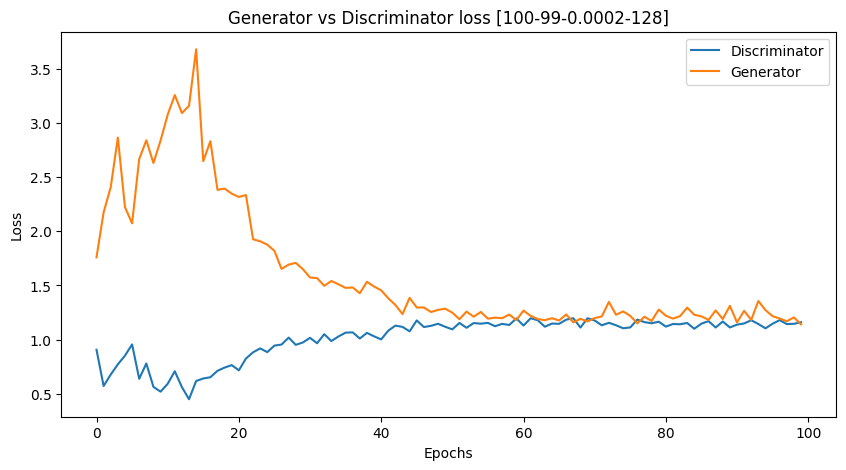

Training model with Learning rate 0.0002 and noise dimension 200
Epoch[ 10/100] ===== Discriminator Loss: 0.5269 ===== Generator Loss: 3.2919 ===== FID Score: 1.6376 ===== Inception Score: 1.8287 +/- 0.0521
Epoch[ 20/100] ===== Discriminator Loss: 0.5405 ===== Generator Loss: 3.2636 ===== FID Score: 0.9184 ===== Inception Score: 2.6954 +/- 0.0628


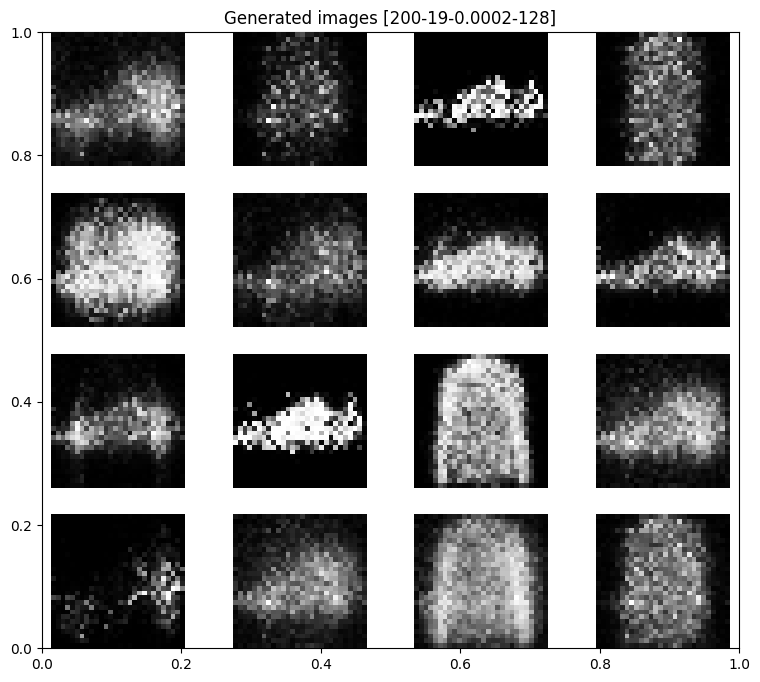

Epoch[ 30/100] ===== Discriminator Loss: 1.1100 ===== Generator Loss: 1.7326 ===== FID Score: 1.9751 ===== Inception Score: 2.3386 +/- 0.0767
Epoch[ 40/100] ===== Discriminator Loss: 1.1053 ===== Generator Loss: 1.3618 ===== FID Score: 0.8820 ===== Inception Score: 2.2689 +/- 0.0754
Epoch[ 50/100] ===== Discriminator Loss: 1.1072 ===== Generator Loss: 1.3660 ===== FID Score: 0.7348 ===== Inception Score: 2.9409 +/- 0.0940


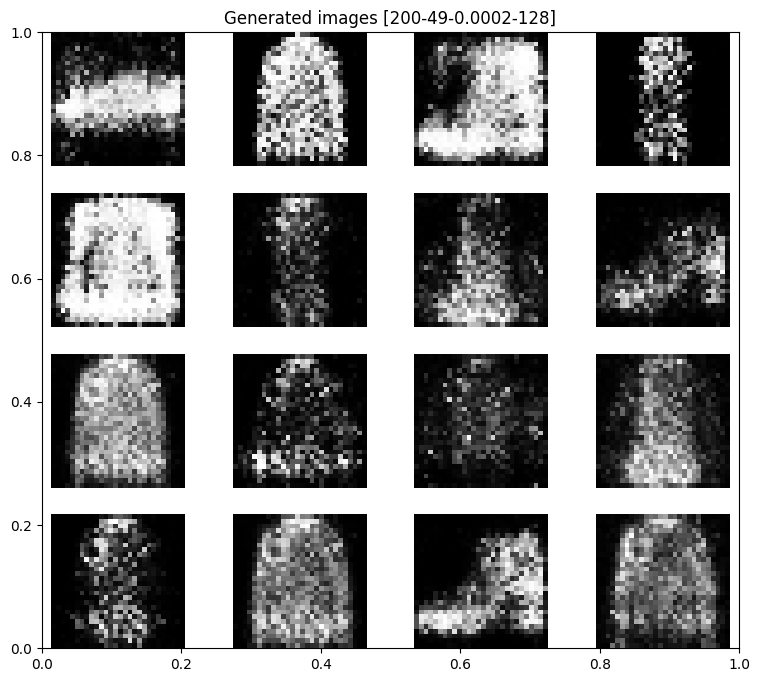

Epoch[ 60/100] ===== Discriminator Loss: 1.1514 ===== Generator Loss: 1.2624 ===== FID Score: 0.6556 ===== Inception Score: 2.7324 +/- 0.1025
Epoch[ 70/100] ===== Discriminator Loss: 1.1178 ===== Generator Loss: 1.2116 ===== FID Score: 1.3425 ===== Inception Score: 2.9038 +/- 0.0810
Epoch[ 80/100] ===== Discriminator Loss: 1.1728 ===== Generator Loss: 1.2935 ===== FID Score: 1.1374 ===== Inception Score: 2.5808 +/- 0.0988
Epoch[ 90/100] ===== Discriminator Loss: 1.1881 ===== Generator Loss: 1.2671 ===== FID Score: 0.7269 ===== Inception Score: 2.6495 +/- 0.0902
Epoch[100/100] ===== Discriminator Loss: 1.2335 ===== Generator Loss: 1.1689 ===== FID Score: 0.9301 ===== Inception Score: 2.9915 +/- 0.1421


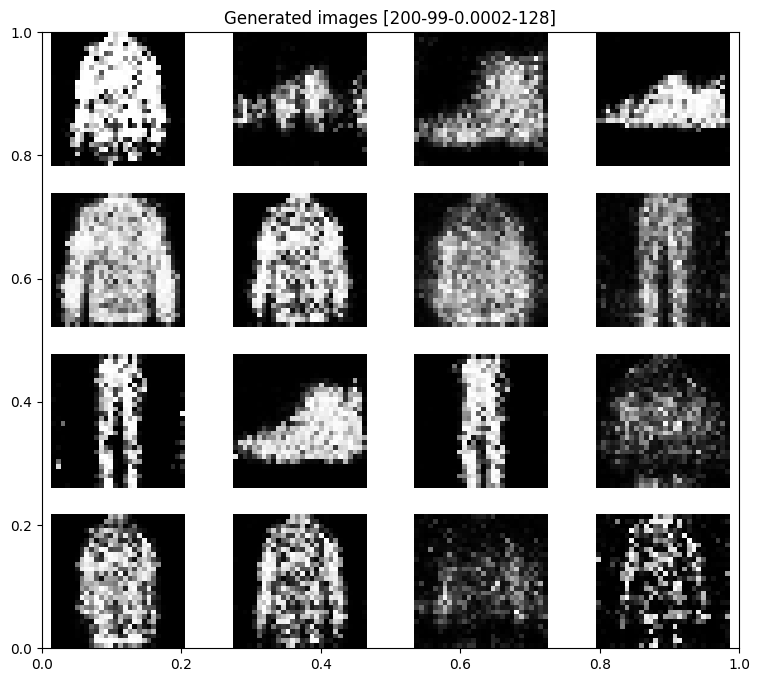

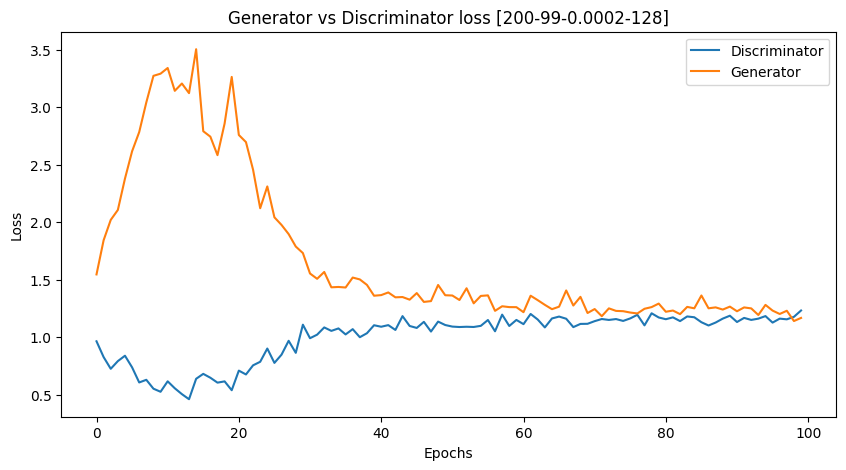

In [29]:
for nd in NOISE_DIMENSION_LIST:
    print('Training model with Learning rate', best_lr, 'and noise dimension', nd)
    gan = GenerativeAdversarialNet(
        noise_dim = nd,
        discriminator_criterion = D_CRITERION,
        generator_criterion = G_CRITERION,
        discriminator_learning_rate = best_lr,
        generator_learning_rate= best_lr,
        device = device,
        is_conditional = False,
        dc = False
    )
    d_losses = []
    g_losses = []
    train_loader, _, _ = fmd.get_loaders(BATCH_SIZE)
    fixed_noise = torch.randn(16, nd, device=device)
    for epoch in range(NUM_EPOCH):
        d_loss, g_loss = gan.train_one_epoch(train_loader)
        d_losses.append(d_loss)
        g_losses.append(g_loss)
        if epoch % 10 == 9:
            fid = calculate_fid(
                generator=gan.generator, 
                dataloader=train_loader, 
                device=gan.device, 
                noise_dim=gan.noise_dim,
                num_classes=gan.num_classes
            )
            is_mean, is_std = calculate_inception_score(
                generator=gan.generator, 
                device=gan.device, 
                noise_dim=gan.noise_dim, 
                num_classes=gan.num_classes,
                n_samples=2000
            )
            print(
                f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
                f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
                f'Generator Loss: {g_loss:.4f}', '=' * 5,
                f'FID Score: {fid:.4f}', '=' * 5,
                f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
            )
        if epoch + 1 in NUM_EPOCH_LIST:
            plot_fake_images(gan, fixed_noise, f'Generated images [{nd}-{epoch}-{best_lr}-{BATCH_SIZE}]')
    generator_discriminator_loss(d_losses, g_losses, f'Generator vs Discriminator loss [{nd}-{epoch}-{best_lr}-{BATCH_SIZE}]')

### D.

#### 1. Analysis of Loss Plots and Generated Images

<img src=".\Output\Part1\D\batch32.sample.png" alt="batch 32" width="500" height="500"/>
<img src=".\Output\Part1\D\batch32.loss.png" alt="batch 32" width="800" height="500"/>

- Batch Size 32
    - Loss Plot Analysis: The Discriminator loss (blue) continues to increase gradually, while the Generator loss (orange) decreases and stabilizes around 0.9. This indicates the **Discriminator is being overpowered** in the later stages, potentially due to the high variance of small batch updates, causing the Generator to learn features that consistently trick the weaker D.

    - Generated Images Analysis: Images are generally clear and recognizable, showing good diversity (e.g., shoes, shirts). However, the shapes are slightly more **fragmented** and less coherent compared to $B=128$, possibly due to the Generator over-fitting to noisy gradients.

    - Conclusion: **Too Slow & Unstable** Good visual results but poor loss balance and computationally inefficient.

<img src=".\Output\Part1\D\batch128.sample.png" alt="batch 128" width="500" height="500"/>
<img src=".\Output\Part1\D\batch128.loss.png" alt="batch 128" width="800" height="500"/>

- Batch Size 128
    - Loss Plot Analysis: The losses achieve the **most stable equilibrium**, converging around 1.2 by Epoch 60, with both curves tracking closely. This is the ideal behavior for a GAN, showing a balanced adversarial game.

    - Generated Images Analysis: The images are the **most visually coherent** and structured, showing clear articles of clothing (sweaters, dresses, trousers). The quality is higher than $B=32$ and $B=256$.

    - Conclusion: **Best Performance** Achieves optimal stability and visual quality.

<img src=".\Output\Part1\D\batch256.sample.png" alt="batch 256" width="500" height="500"/>
<img src=".\Output\Part1\D\batch256.loss.png" alt="batch 256" width="800" height="500"/>

- Batch Size 256
    - Loss Plot Analysis: The Discriminator loss (blue) is very low and stable ($\approx 0.9$), while the Generator loss (orange) remains high ($\approx 1.6$). This indicates **the Discriminator is dominating** the Generator, preventing the G from receiving strong enough gradients to improve substantially.

    - Generated Images Analysis: Images are blurrier and less detailed compared to $B=128$. While recognizable, they lack the sharpness and clear boundaries, consistent with a Generator that is struggling to learn due to a dominant Discriminator.

    - Conclusion: **Too Stable & Dominant D** Leads to lower visual quality due to the Discriminator's dominance.


#### 2. Conclusion: The Best Batch Size

The **optimal batch size is 128**.

* It demonstrates the **best convergence dynamics** (balanced losses) and yields the **highest visual quality** and coherence in the generated images.
* It strikes a perfect balance between the high variance of $B=32$ (which can lead to unstable training) and the low variance of $B=256$ (which often leads to a dominant Discriminator).
* Given that $B=32$ is too slow, $B=128$ is the superior choice in terms of both performance and training efficiency.


#### 3. Trade-Offs in Batch Size Selection

Changing the batch size involves a key trade-off between the quality of the gradient estimate and the total time required for training.

- Trade-off: Batch Size vs. Training Stability

    - Small Batch Size (32): The gradient calculated from a small batch has **high variance** (is a noisy estimate of the true gradient). This noise can sometimes help the model escape sharp local minima and explore the solution space better. However, in GANs, this high variance can lead to **instability**, causing the Generator and Discriminator to oscillate or for one to quickly overpower the other.
    - Large Batch Size (256): The gradient calculated from a large batch has **low variance** (is a stable, accurate estimate). In GANs, this often makes the Discriminator too powerful, as it rapidly locks onto a consistent, low-variance signal from the real data. This **dominance** leads to the **Generator stalling** (receiving weak gradients) and poor final image quality.

- Trade-off: Batch Size vs. Computational Efficiency

* **Small Batch Size (32):** Leads to **poor computational efficiency**. While each forward/backward pass is fast, the total number of iterations (updates) required to complete an epoch is very high, significantly slowing down the total training time.
* **Large Batch Size (256):** Leads to **high computational efficiency**. Fewer updates per epoch mean faster convergence in terms of *number of epochs*, and modern hardware (GPUs) is optimized for processing larger batches in parallel. However, if the large batch size causes the Discriminator to dominate, the model may converge to a **poor quality solution** faster.

The batch size  is the **sweet spot**, offering a balance between the stable, efficient gradient estimation of large batches and the noise needed to maintain the adversarial balance in the GAN.

In [23]:
best_nd = 100

Training model with Learning rate 0.0002 , noise dimension 100 and batch size of 32
Epoch[ 10/100] ===== Discriminator Loss: 1.0496 ===== Generator Loss: 1.3871 ===== FID Score: 0.7241 ===== Inception Score: 2.9686 +/- 0.1415
Epoch[ 20/100] ===== Discriminator Loss: 1.1001 ===== Generator Loss: 1.3166 ===== FID Score: 1.0461 ===== Inception Score: 2.6292 +/- 0.0719


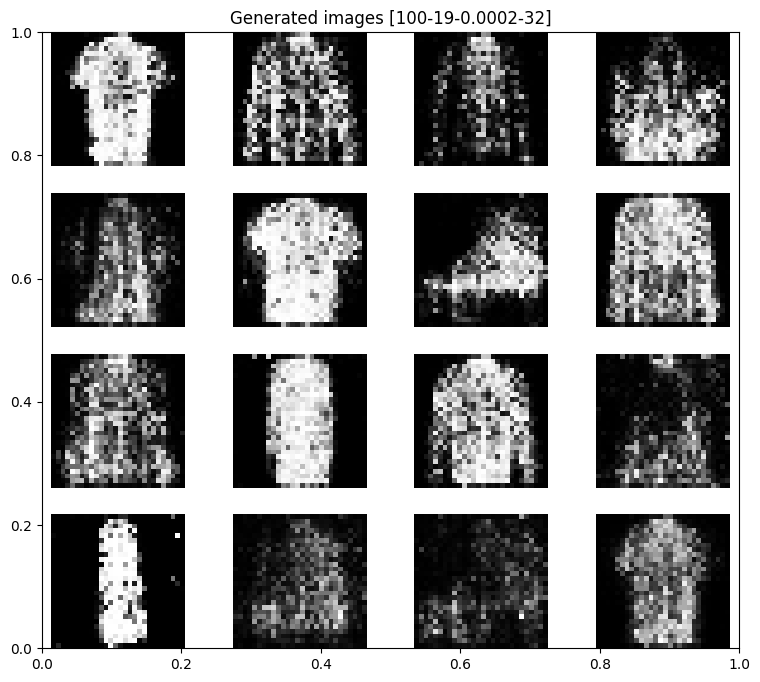

Epoch[ 30/100] ===== Discriminator Loss: 1.1818 ===== Generator Loss: 1.0955 ===== FID Score: 0.7184 ===== Inception Score: 2.6579 +/- 0.0937
Epoch[ 40/100] ===== Discriminator Loss: 1.2151 ===== Generator Loss: 1.0538 ===== FID Score: 0.5567 ===== Inception Score: 2.9572 +/- 0.1553
Epoch[ 50/100] ===== Discriminator Loss: 1.2456 ===== Generator Loss: 0.9957 ===== FID Score: 0.8371 ===== Inception Score: 2.9694 +/- 0.1566


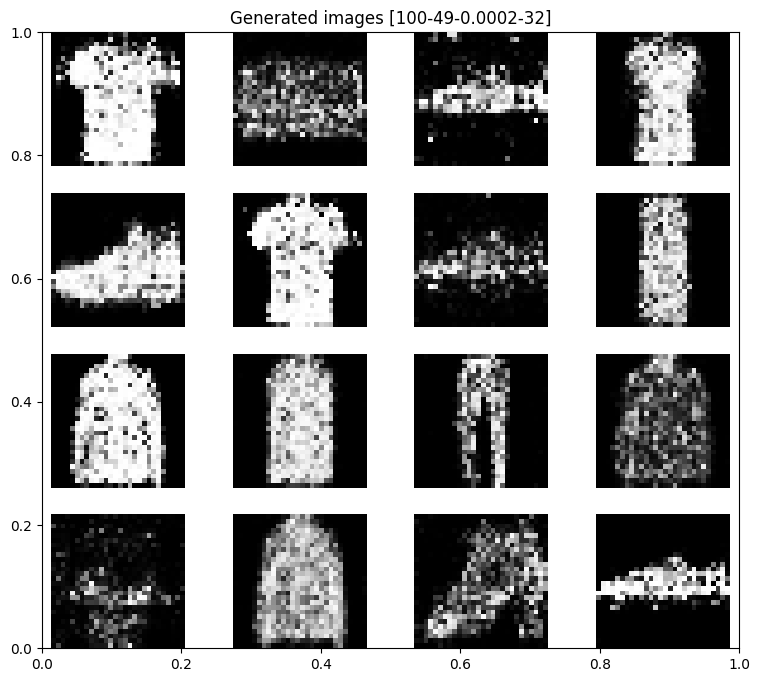

Epoch[ 60/100] ===== Discriminator Loss: 1.2581 ===== Generator Loss: 0.9732 ===== FID Score: 0.5459 ===== Inception Score: 3.2559 +/- 0.1951
Epoch[ 70/100] ===== Discriminator Loss: 1.2844 ===== Generator Loss: 0.9201 ===== FID Score: 0.4583 ===== Inception Score: 3.2015 +/- 0.0768
Epoch[ 80/100] ===== Discriminator Loss: 1.2900 ===== Generator Loss: 0.8878 ===== FID Score: 0.5159 ===== Inception Score: 2.7763 +/- 0.1082
Epoch[ 90/100] ===== Discriminator Loss: 1.3234 ===== Generator Loss: 0.8502 ===== FID Score: 0.5582 ===== Inception Score: 3.1219 +/- 0.1690
Epoch[100/100] ===== Discriminator Loss: 1.3272 ===== Generator Loss: 0.8440 ===== FID Score: 0.3765 ===== Inception Score: 3.0490 +/- 0.2075


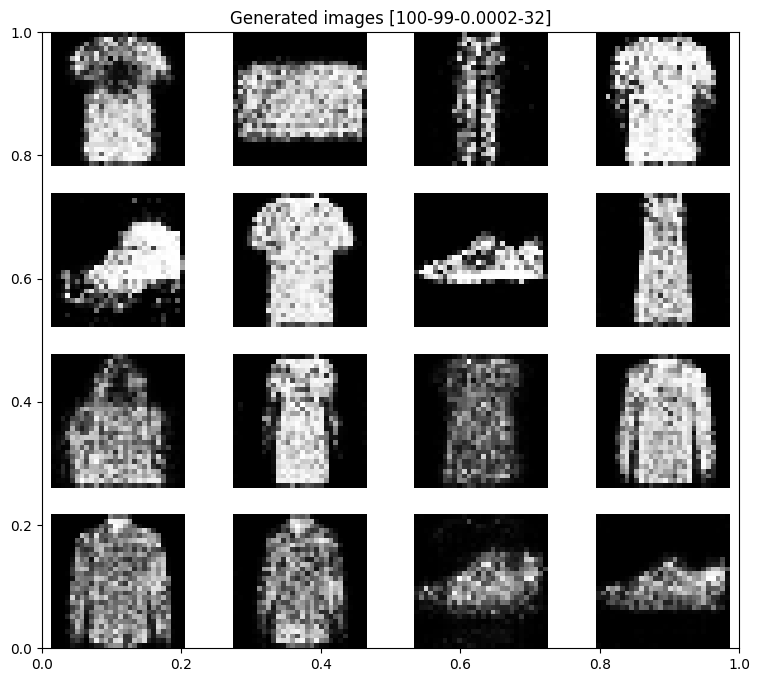

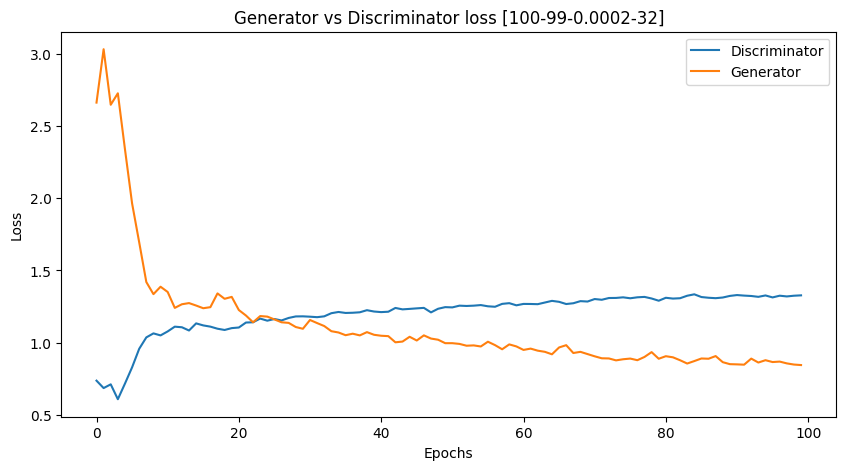

Training model with Learning rate 0.0002 , noise dimension 100 and batch size of 128
Epoch[ 10/100] ===== Discriminator Loss: 0.5269 ===== Generator Loss: 3.2919 ===== FID Score: 1.6376 ===== Inception Score: 1.8287 +/- 0.0521
Epoch[ 20/100] ===== Discriminator Loss: 0.5405 ===== Generator Loss: 3.2636 ===== FID Score: 0.9184 ===== Inception Score: 2.6954 +/- 0.0628


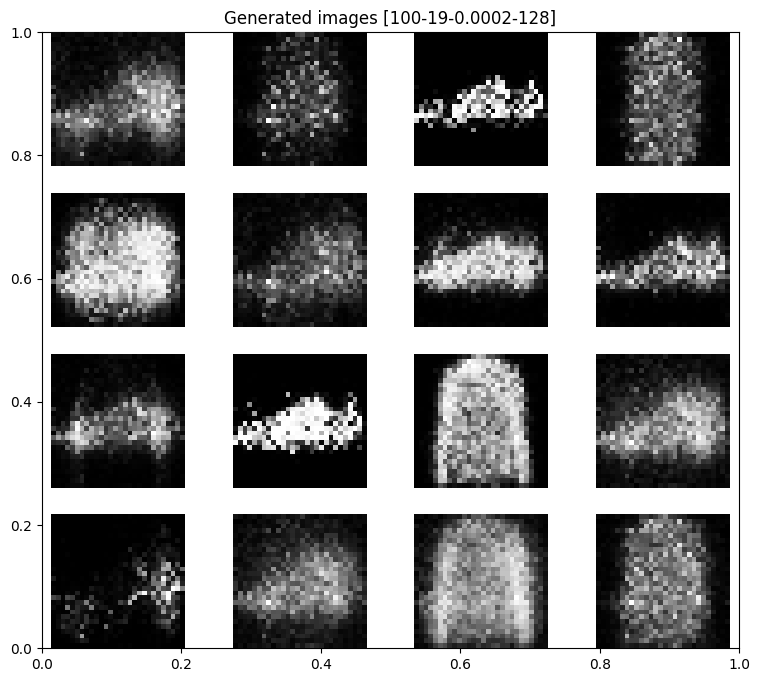

Epoch[ 30/100] ===== Discriminator Loss: 1.1100 ===== Generator Loss: 1.7326 ===== FID Score: 1.9751 ===== Inception Score: 2.3386 +/- 0.0767
Epoch[ 40/100] ===== Discriminator Loss: 1.1053 ===== Generator Loss: 1.3618 ===== FID Score: 0.8820 ===== Inception Score: 2.2689 +/- 0.0754
Epoch[ 50/100] ===== Discriminator Loss: 1.1072 ===== Generator Loss: 1.3660 ===== FID Score: 0.7348 ===== Inception Score: 2.9409 +/- 0.0940


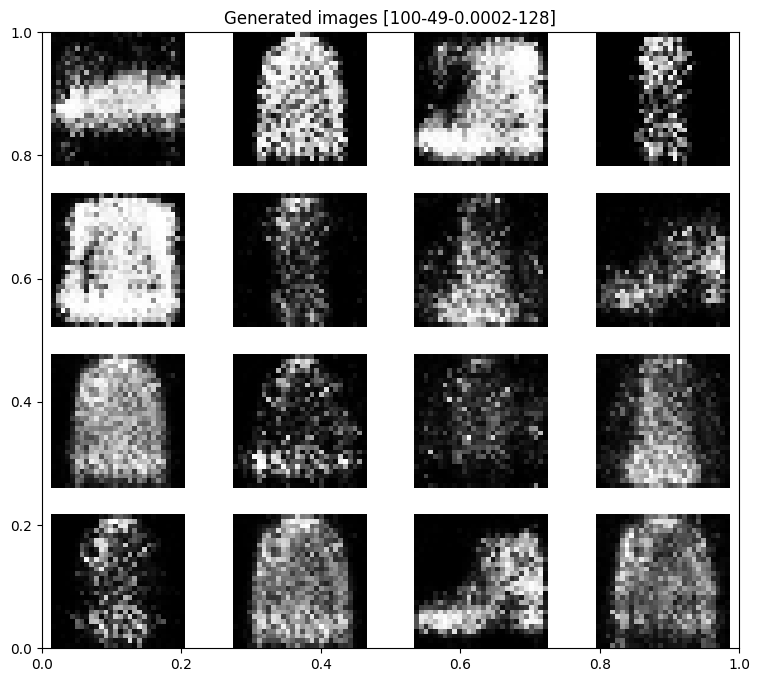

Epoch[ 60/100] ===== Discriminator Loss: 1.1514 ===== Generator Loss: 1.2624 ===== FID Score: 0.6556 ===== Inception Score: 2.7324 +/- 0.1025
Epoch[ 70/100] ===== Discriminator Loss: 1.1178 ===== Generator Loss: 1.2116 ===== FID Score: 1.3425 ===== Inception Score: 2.9038 +/- 0.0810
Epoch[ 80/100] ===== Discriminator Loss: 1.1728 ===== Generator Loss: 1.2935 ===== FID Score: 1.1374 ===== Inception Score: 2.5808 +/- 0.0988
Epoch[ 90/100] ===== Discriminator Loss: 1.1881 ===== Generator Loss: 1.2671 ===== FID Score: 0.7269 ===== Inception Score: 2.6495 +/- 0.0902
Epoch[100/100] ===== Discriminator Loss: 1.2335 ===== Generator Loss: 1.1689 ===== FID Score: 0.9301 ===== Inception Score: 2.9915 +/- 0.1421


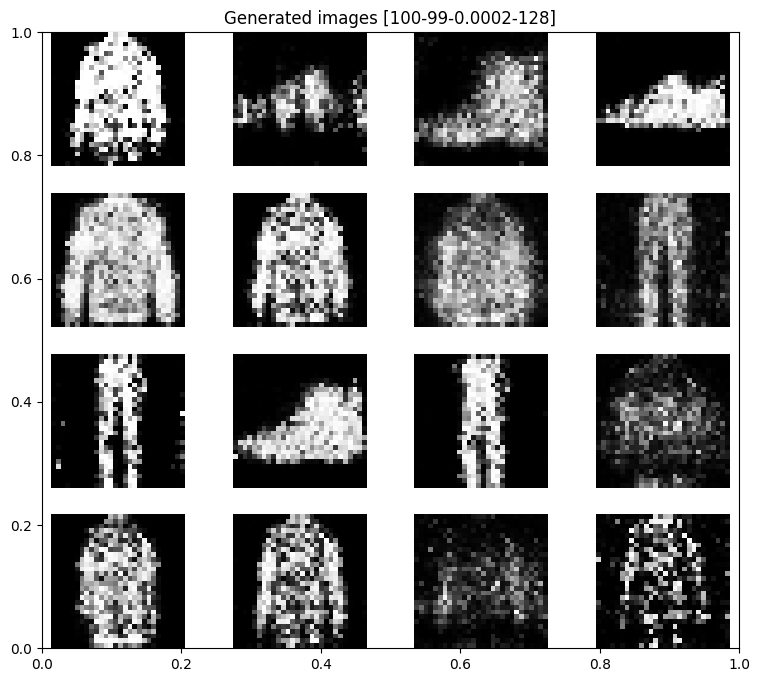

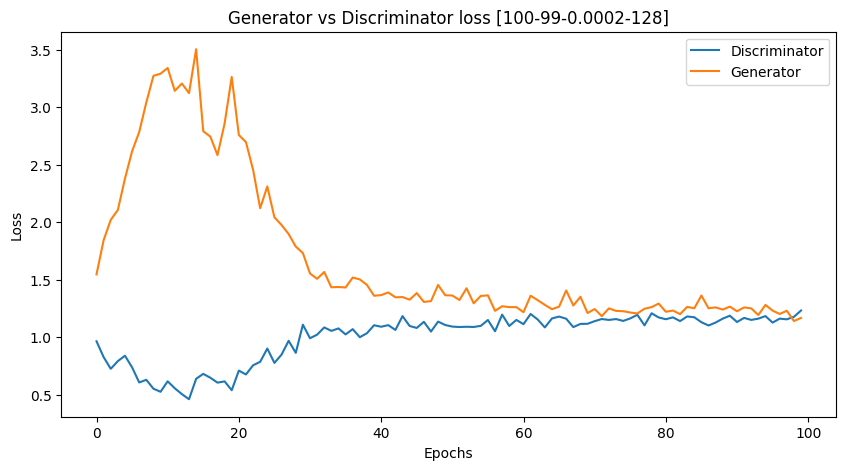

Training model with Learning rate 0.0002 , noise dimension 100 and batch size of 256
Epoch[ 10/100] ===== Discriminator Loss: 1.1142 ===== Generator Loss: 2.2935 ===== FID Score: 1.8186 ===== Inception Score: 1.7263 +/- 0.0408
Epoch[ 20/100] ===== Discriminator Loss: 0.4464 ===== Generator Loss: 3.2768 ===== FID Score: 2.1286 ===== Inception Score: 2.1292 +/- 0.0708


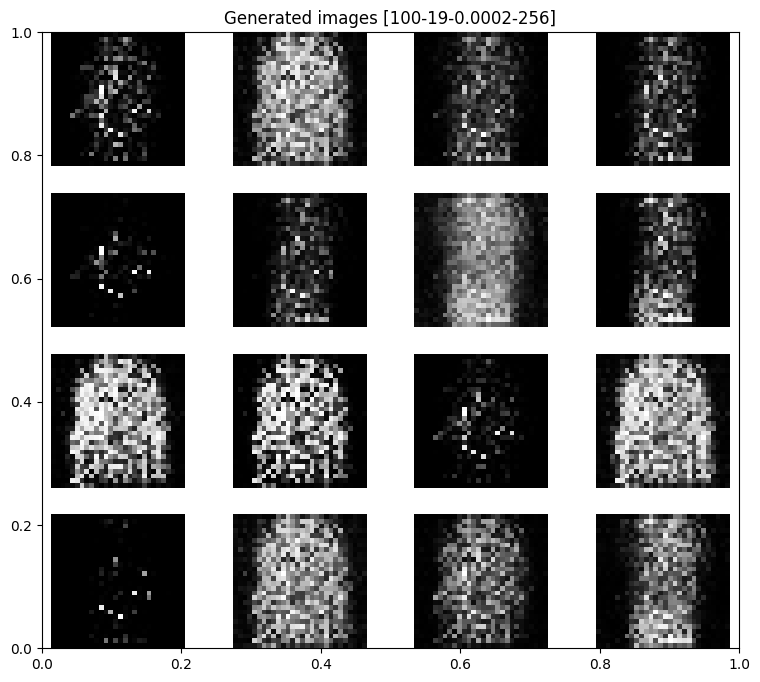

Epoch[ 30/100] ===== Discriminator Loss: 0.6621 ===== Generator Loss: 2.6430 ===== FID Score: 1.5264 ===== Inception Score: 2.2398 +/- 0.0579
Epoch[ 40/100] ===== Discriminator Loss: 0.6816 ===== Generator Loss: 2.2692 ===== FID Score: 1.3409 ===== Inception Score: 2.1519 +/- 0.0455
Epoch[ 50/100] ===== Discriminator Loss: 0.8226 ===== Generator Loss: 1.9201 ===== FID Score: 1.4922 ===== Inception Score: 2.6126 +/- 0.1458


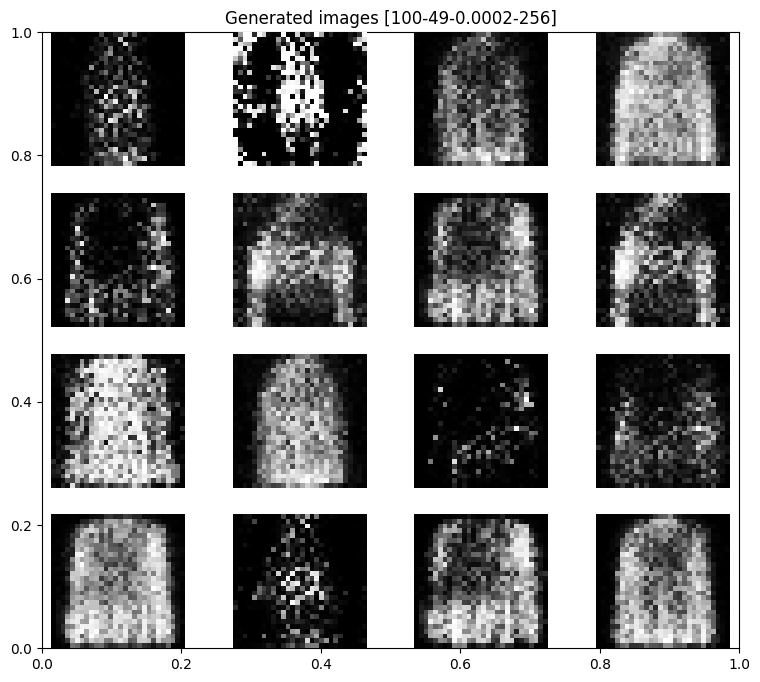

Epoch[ 60/100] ===== Discriminator Loss: 0.9621 ===== Generator Loss: 1.6785 ===== FID Score: 1.5465 ===== Inception Score: 2.3816 +/- 0.0490
Epoch[ 70/100] ===== Discriminator Loss: 1.0312 ===== Generator Loss: 1.7984 ===== FID Score: 1.1438 ===== Inception Score: 2.1435 +/- 0.0299
Epoch[ 80/100] ===== Discriminator Loss: 0.8884 ===== Generator Loss: 1.7110 ===== FID Score: 1.7014 ===== Inception Score: 2.0915 +/- 0.0911
Epoch[ 90/100] ===== Discriminator Loss: 0.8588 ===== Generator Loss: 1.6100 ===== FID Score: 0.7987 ===== Inception Score: 2.2995 +/- 0.0978
Epoch[100/100] ===== Discriminator Loss: 0.8400 ===== Generator Loss: 1.6624 ===== FID Score: 1.3845 ===== Inception Score: 2.3032 +/- 0.0556


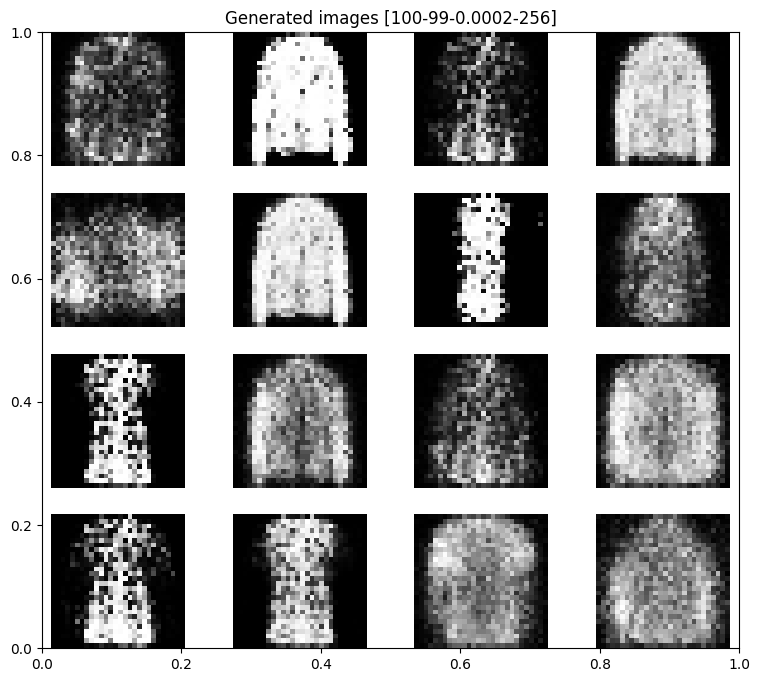

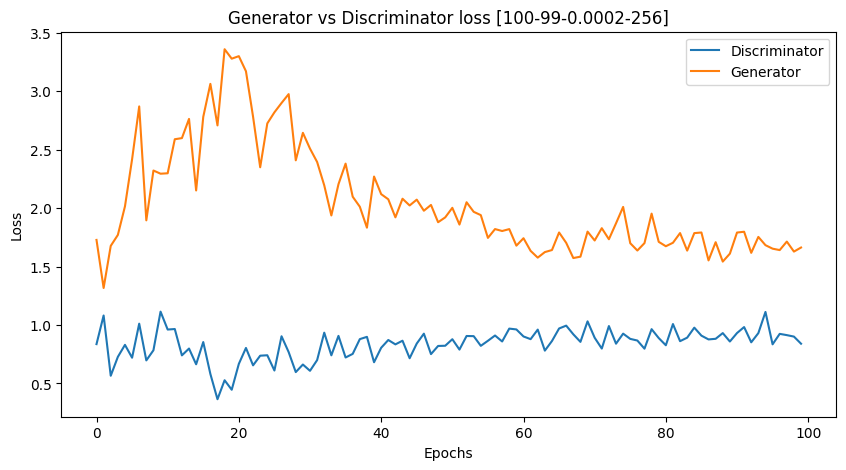

In [33]:
for bs in BATCH_SIZE_LIST:
    print('Training model with Learning rate', best_lr, ', noise dimension', best_nd, 'and batch size of', bs)
    gan = GenerativeAdversarialNet(
        noise_dim = nd,
        discriminator_criterion = D_CRITERION,
        generator_criterion = G_CRITERION,
        discriminator_learning_rate = best_lr,
        generator_learning_rate= best_lr,
        device = device,
        is_conditional = False,
        dc = False
    )
    d_losses = []
    g_losses = []
    train_loader, _, _ = fmd.get_loaders(bs)
    fixed_noise = torch.randn(16, nd, device=device)
    for epoch in range(NUM_EPOCH):
        d_loss, g_loss = gan.train_one_epoch(train_loader)
        d_losses.append(d_loss)
        g_losses.append(g_loss)
        if epoch % 10 == 9:
            fid = calculate_fid(
                generator=gan.generator, 
                dataloader=train_loader, 
                device=gan.device, 
                noise_dim=gan.noise_dim,
                num_classes=gan.num_classes
            )
            is_mean, is_std = calculate_inception_score(
                generator=gan.generator, 
                device=gan.device, 
                noise_dim=gan.noise_dim, 
                num_classes=gan.num_classes,
                n_samples=2000
            )
            print(
                f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
                f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
                f'Generator Loss: {g_loss:.4f}', '=' * 5,
                f'FID Score: {fid:.4f}', '=' * 5,
                f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
            )
        if epoch + 1 in NUM_EPOCH_LIST:
            plot_fake_images(gan, fixed_noise, f'Generated images [{best_nd}-{epoch}-{best_lr}-{bs}]')
    generator_discriminator_loss(d_losses, g_losses, f'Generator vs Discriminator loss [{best_nd}-{epoch}-{best_lr}-{bs}]')

## 2.

### A.

#### 1. DCGAN vs. Vanilla GAN: Visual Quality and Stability

The transition from a simple vanilla GAN (using fully connected layers) to a DCGAN (using convolutional layers, as seen in the previous analysis) results in a dramatic improvement:


<img src=".\Output\Part2\A\large.filter.sample.png" alt="large filter" width="400" height="400"/>
<img src=".\Output\Part2\A\small.filter.sample.png" alt="small filter" width="400" height="400"/>

* **Visual Quality:** The simple GAN often produced blurry, noisy, or fragmented images (e.g., as seen in the $B=128$ sample, which was the best of the vanilla GAN). In contrast, both DCGAN variants [32, 64, 128] and [128, 256, 512] generate outputs with **clearer, more consistent structure, sharper boundaries, and higher fidelity** to the real Fashion-MNIST classes (shoes, trousers, shirts). The convolutional layers are inherently better at learning spatial hierarchies of features.

<img src=".\Output\Part2\A\large.filter.loss.png" alt="large filter" width="600" height="400"/>
<img src=".\Output\Part2\A\small.filter.loss.png" alt="small filter" width="600" height="400"/>

**Training Stability**
* **Vanilla GAN (Optimal $B=128$):** The losses stabilized around $\approx 1.2$, showing a healthy, balanced competition.
* **DCGAN (Small & Large Filters):** Both DCGAN loss plots show the Discriminator loss remaining extremely low (near 0 to 0.5), while the Generator loss stays very high (between 4 and 7). This suggests a more **unstable/dominant Discriminator** compared to the vanilla GAN, a common issue in training deep convolutional GANs. Despite the loss instability, the DCGAN achieves superior visual results, demonstrating that **loss value is not always the best proxy for visual quality** in GANs.



#### 2. Impact of Filter Capacity (Small vs. Large)

The filter size sequence dictates the **representational capacity** of the network, controlling the number of features each layer can learn.

- Small Filter Capacity (e.g., [32, 64, 128])

    - **Loss Plot:** The Discriminator loss is very low (below 0.5), and the Generator loss is high, oscillating between 3.8 and 4.5.

    - **Visual Quality:** Generated images show decent overall structure (e.g., clear outlines of shirts, shoes), but some samples suffer from **blurriness** and a loss of finer detail. The model's capacity might be slightly constrained.


- Large Filter Capacity (e.g., [128, 256, 512])

    - **Loss Plot:** The Discriminator loss is extremely close to zero, and the Generator loss is high, oscillating between 6 and 7.5. The loss difference is the largest of the two DCGAN models.
    - **Visual Quality:** The generated images demonstrate the **highest overall quality**. Samples are consistently sharp, detailed, and display excellent class diversity (trousers, boots, various tops). The increased capacity allows the network to model complex boundaries and textures effectively.

#### Conclusion

The comparison between the small  and large  filter capacities for the DCGAN highlights a key trade-off between **model complexity** and **training resources**.

##### Downsides and Upsides

- **Small Filters**
    - **Upside:** **Lower Computational Cost** (faster training and less memory).
    - **Downside:** **Limited Capacity**, resulting in generated images that are slightly blurry or simplistic, as the network lacks the complexity to model intricate details. ]


- **Large Filters**
    - **Upside:** **High Representational Power**, leading to the **most visually detailed and coherent images** by capturing complex features.
    - **Downside:** **High Computational Cost** and **Increased Training Instability**, as the large number of parameters makes the Discriminator very strong, potentially leading to high, erratic Generator loss.


##### Final Recommendation

To achieve an optimal balance between visual quality and computational efficiency, a **moderate filter capacity** such as **[64, 128, 256]** is recommended. This setting offers sufficient complexity to generate highly detailed and diverse samples, similar to the large filter set, while significantly reducing the computational burden and memory usage associated with the largest model. This approach aims for the best result per resource spent.

In [24]:
best_bs = 128

Training dcgan with Learning rate 0.0002 , noise dimension 100 and batch size of 128 using large filters
Epoch[ 10/100] ===== Discriminator Loss: 0.0985 ===== Generator Loss: 8.3736 ===== FID Score: 1.7051 ===== Inception Score: 3.2849 +/- 0.1264
Epoch[ 20/100] ===== Discriminator Loss: 0.1727 ===== Generator Loss: 7.4151 ===== FID Score: 0.1011 ===== Inception Score: 3.6799 +/- 0.1395


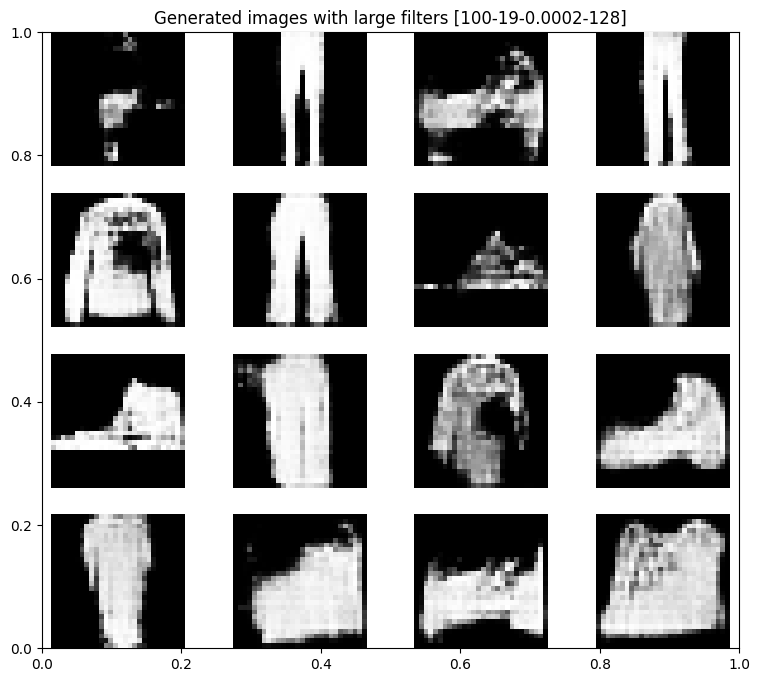

Epoch[ 30/100] ===== Discriminator Loss: 0.2337 ===== Generator Loss: 6.3078 ===== FID Score: 0.0248 ===== Inception Score: 3.9315 +/- 0.2074
Epoch[ 40/100] ===== Discriminator Loss: 0.2232 ===== Generator Loss: 6.0237 ===== FID Score: 0.0414 ===== Inception Score: 3.9904 +/- 0.1323
Epoch[ 50/100] ===== Discriminator Loss: 0.2118 ===== Generator Loss: 6.5048 ===== FID Score: 0.0081 ===== Inception Score: 3.8888 +/- 0.1372


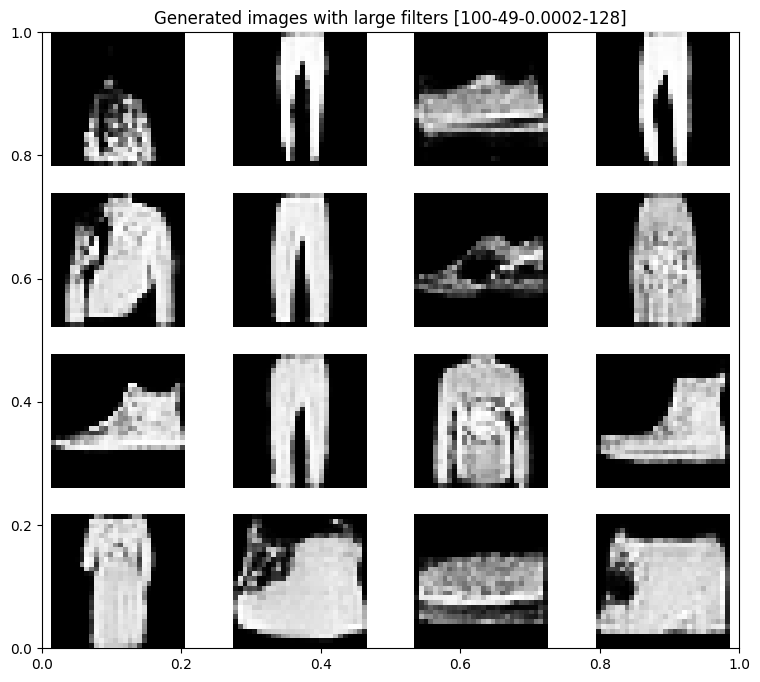

Epoch[ 60/100] ===== Discriminator Loss: 0.2372 ===== Generator Loss: 6.2810 ===== FID Score: 0.0040 ===== Inception Score: 3.9668 +/- 0.2670
Epoch[ 70/100] ===== Discriminator Loss: 0.1988 ===== Generator Loss: 6.1920 ===== FID Score: 0.0069 ===== Inception Score: 3.9046 +/- 0.1433
Epoch[ 80/100] ===== Discriminator Loss: 0.2290 ===== Generator Loss: 6.7822 ===== FID Score: 0.0168 ===== Inception Score: 3.9312 +/- 0.2251
Epoch[ 90/100] ===== Discriminator Loss: 0.1584 ===== Generator Loss: 7.3515 ===== FID Score: 0.0121 ===== Inception Score: 3.9107 +/- 0.1655
Epoch[100/100] ===== Discriminator Loss: 0.2086 ===== Generator Loss: 7.2608 ===== FID Score: 0.0043 ===== Inception Score: 4.1270 +/- 0.0908


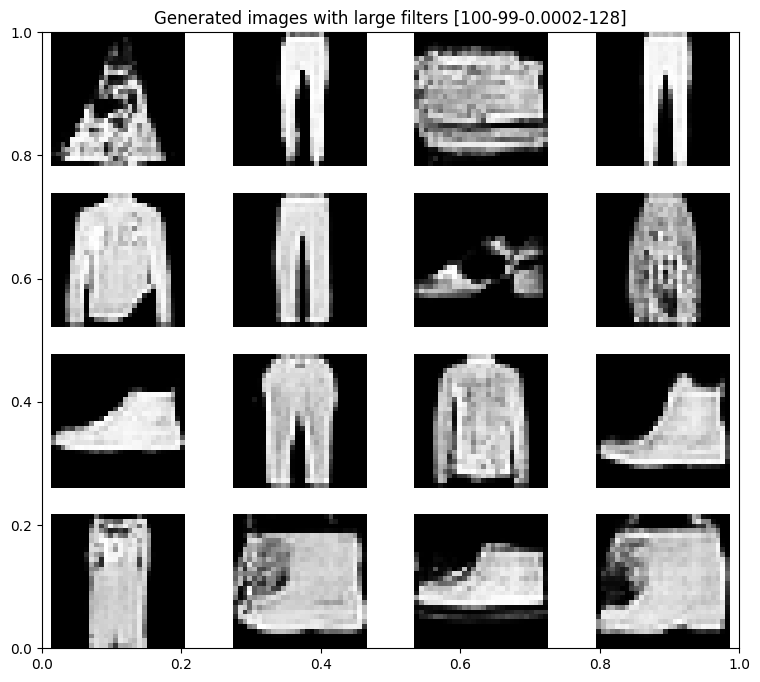

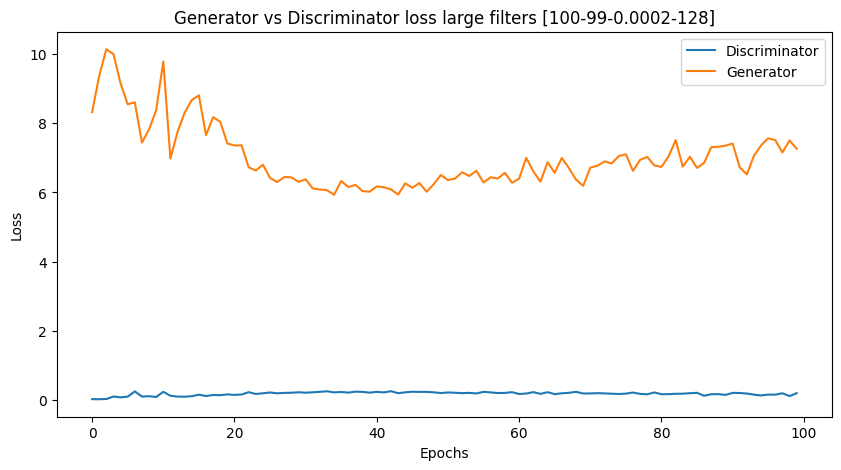

Training dcgan with Learning rate 0.0002 , noise dimension 100 and batch size of 128 using small filters
Epoch[ 10/100] ===== Discriminator Loss: 0.1156 ===== Generator Loss: 7.4493 ===== FID Score: 0.3110 ===== Inception Score: 2.7592 +/- 0.1257
Epoch[ 20/100] ===== Discriminator Loss: 0.2682 ===== Generator Loss: 6.0495 ===== FID Score: 0.2077 ===== Inception Score: 3.5061 +/- 0.2036


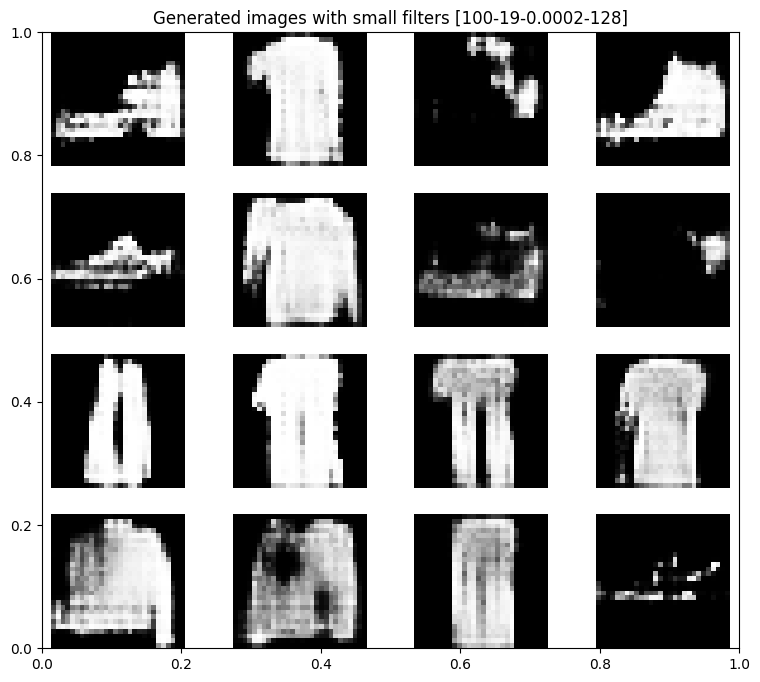

Epoch[ 30/100] ===== Discriminator Loss: 0.3662 ===== Generator Loss: 4.6404 ===== FID Score: 0.1333 ===== Inception Score: 3.6042 +/- 0.1832
Epoch[ 40/100] ===== Discriminator Loss: 0.4403 ===== Generator Loss: 4.2987 ===== FID Score: 0.2352 ===== Inception Score: 3.8165 +/- 0.2276
Epoch[ 50/100] ===== Discriminator Loss: 0.4332 ===== Generator Loss: 4.0492 ===== FID Score: 0.0082 ===== Inception Score: 3.8543 +/- 0.2620


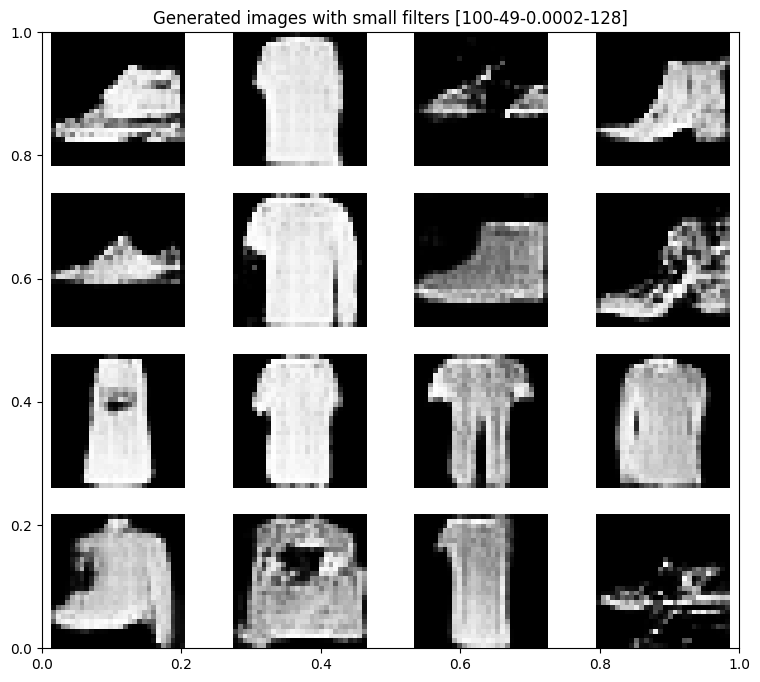

Epoch[ 60/100] ===== Discriminator Loss: 0.4448 ===== Generator Loss: 3.9365 ===== FID Score: 0.0066 ===== Inception Score: 3.7662 +/- 0.1301
Epoch[ 70/100] ===== Discriminator Loss: 0.4338 ===== Generator Loss: 4.0335 ===== FID Score: 0.0215 ===== Inception Score: 4.0462 +/- 0.1680
Epoch[ 80/100] ===== Discriminator Loss: 0.4243 ===== Generator Loss: 4.1809 ===== FID Score: 0.0074 ===== Inception Score: 3.8273 +/- 0.2480
Epoch[ 90/100] ===== Discriminator Loss: 0.4071 ===== Generator Loss: 4.1118 ===== FID Score: 0.0164 ===== Inception Score: 3.8644 +/- 0.1339
Epoch[100/100] ===== Discriminator Loss: 0.4164 ===== Generator Loss: 4.2397 ===== FID Score: 0.0092 ===== Inception Score: 4.0413 +/- 0.1900


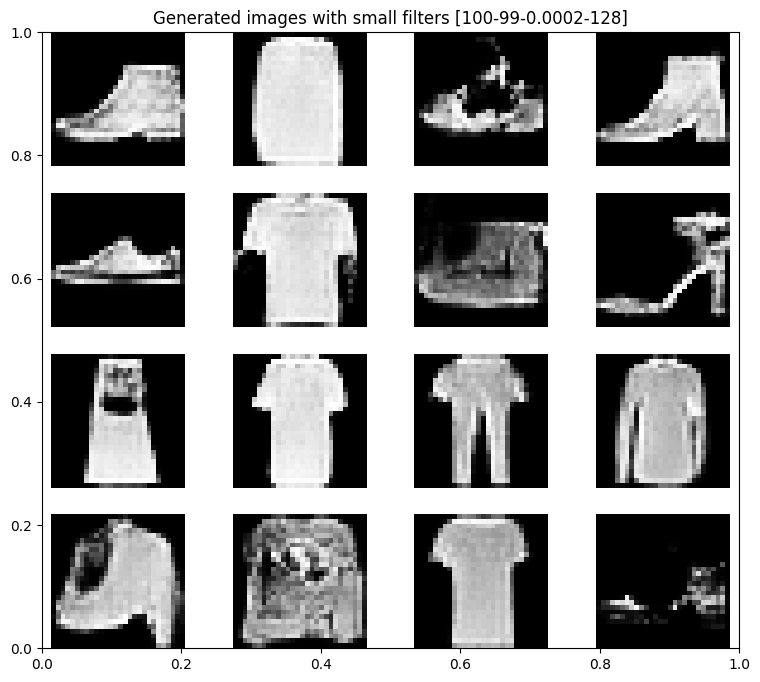

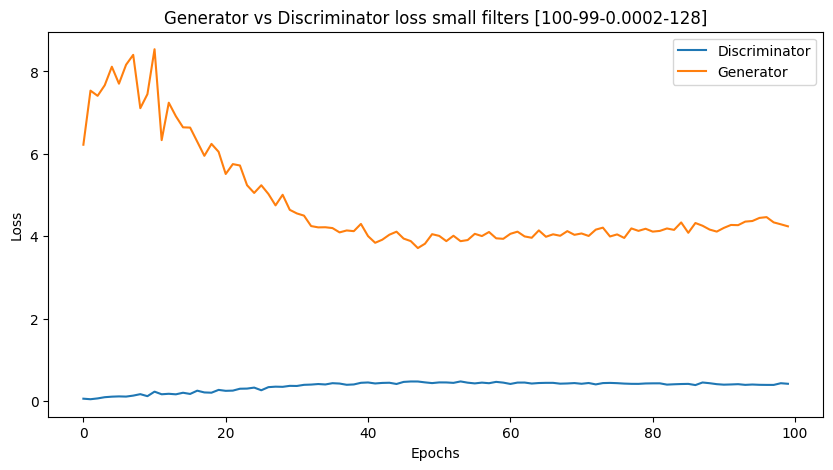

In [42]:
for ls in [True, False]:
    print(
        'Training dcgan with Learning rate', best_lr,
        ', noise dimension', best_nd, 'and batch size of',
        best_bs, 'using', ('large' if ls else 'small'), 'filters'
    )
    gan = GenerativeAdversarialNet(
        noise_dim = nd,
        discriminator_criterion = D_CRITERION,
        generator_criterion = G_CRITERION,
        discriminator_learning_rate = best_lr,
        generator_learning_rate= best_lr,
        device = device,
        is_conditional = False,
        dc = True,
        lg_filter=ls
    )
    d_losses = []
    g_losses = []
    train_loader, _, _ = fmd.get_loaders(best_bs)
    fixed_noise = torch.randn(16, nd, device=device)
    for epoch in range(NUM_EPOCH):
        d_loss, g_loss = gan.train_one_epoch(train_loader)
        d_losses.append(d_loss)
        g_losses.append(g_loss)
        if epoch % 10 == 9:
            fid = calculate_fid(
                generator=gan.generator, 
                dataloader=train_loader, 
                device=gan.device, 
                noise_dim=gan.noise_dim,
                num_classes=gan.num_classes
            )
            is_mean, is_std = calculate_inception_score(
                generator=gan.generator, 
                device=gan.device, 
                noise_dim=gan.noise_dim, 
                num_classes=gan.num_classes,
                n_samples=2000
            )
            print(
                f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
                f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
                f'Generator Loss: {g_loss:.4f}', '=' * 5,
                f'FID Score: {fid:.4f}', '=' * 5,
                f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
            )
        if epoch + 1 in NUM_EPOCH_LIST:
            x = str(('large' if ls else 'small')+ ' filters')
            plot_fake_images(gan, fixed_noise, f'Generated images with {x} [{best_nd}-{epoch}-{best_lr}-{best_bs}]')
    generator_discriminator_loss(d_losses, g_losses, f'Generator vs Discriminator loss {x} [{best_nd}-{epoch}-{best_lr}-{best_bs}]')

### B.

#### 1. Comparative Analysis of Generative Capacity and Label Fidelity

The introduction of conditional learning transforms the GAN from a random data synthesizer into a **controlled feature generator**, significantly enhancing its practical utility.


<img src=".\Output\Part2\B\cgan.sample.png" alt="cgan" width="400" height="400"/>

* **Superior Controllability:** The fundamental advantage of the cDCGAN is the ability to dictate the output class via the label input ($Y$). This solves the problem of *inter-class mode collapse* by compelling the Generator to explicitly learn and represent all ten distinct class distributions (e.g., distinguishing between 'T-shirt/top' and 'Ankle Boot'). The resulting samples are clearly and correctly categorized, demonstrating high **label fidelity**.
* **Architectural Efficiency:** The use of convolutional layers (DCGAN) is already superior to a vanilla fully-connected GAN in learning spatial hierarchies. By conditioning this architecture, the network efficiently segments its representational capacity based on the label, allocating parameters to learn class-specific features (e.g., the distinct shape of a 'Trouser' versus a 'Dress').

<img src=".\Output\Part2\B\cgan.loss.png" alt="cgan" width="700" height="400"/>

* **Training Stability Dynamics:** Consistent with the challenges of deep GAN training, the cDCGAN loss plot exhibits a numerically volatile pattern: the Discriminator loss remains close to zero, while the Generator loss is high and oscillatory. This indicates a dominant Discriminator. Although the high-quality samples visually attest to the Generator's progress, the large loss gap suggests the adversarial game is played in a region of high instability, common when the conditioning mechanism gives the Discriminator too much information.


#### 2. Technical Diagnosis: Intra-Class Mode Collapse

<img src=".\Output\Part2\B\cgan.label.sample.png" alt="cgan" width="600" height="600" style="display: block; margin-left: auto; margin-right: auto;"/>

The observation that generated images for a single, fixed class label appear nearly identical, despite being synthesized from unique, random noise vectors (), is a critical training failure known as **Intra-Class Mode Collapse** or **Noise-Vector Inefficiency**.

##### *Mechanism of Failure*

1. **The Generator's Objective:** The cDCGAN Generator's role is to map the noise vector  (intended for style/variation) and the label  (intended for macro-structure/class) to an image : . To achieve full diversity, the output must be highly sensitive to both  and .
2. **Gradient Path of Least Resistance:** The Generator's training objective is to minimize . When the label  provides enough defining information to create a plausible image for the Discriminator, the Generator finds the simplest possible solution: producing the **average or prototype image** for that class. This allows the Generator to satisfy the Discriminator using the reliable  input, effectively **decoupling its output from the  input**.
3. **Resulting Trivial Mapping:** The Generator learns a function where  is approximately constant regardless of the value of  for a fixed . In the image space, this means every random  is mapped to the single, most probable point within that class's distribution (the mode). The model is therefore successful at learning the 10 broad classes, but entirely fails to learn the infinite *variations* (sub-modes) within each class, leading to a profound loss of generative stochasticity.

##### Suggested Mitigation Strategies

To force the Generator to utilize the noise vector  and restore intra-class diversity, advanced techniques are necessary:

* **Alternative Loss Functions:** Switching the objective function to the **Wasserstein GAN with Gradient Penalty (WGAN-GP)** or **Least Squares GAN (LSGAN)** often provides smoother, less saturated gradients, which are essential for preventing the Generator from finding the trivial, mode-collapsed solution.
* **Regularization on :** Explicitly add a regularization term that penalizes the Generator if changes in  do not lead to proportional changes in the generated image features (e.g., Z-regularization). This forces the Generator to treat the noise input as meaningful.

The cDCGAN architecture provides the necessary structural control, but without adequate regularization, its high capacity leads to a specific mode collapse where **control is gained at the expense of stochasticity**.

Training cgan with Learning rate 0.0002 , noise dimension 100 and batch size of 128
Epoch[ 10/100] ===== Discriminator Loss: 0.2166 ===== Generator Loss: 5.7928 ===== FID Score: 0.2167 ===== Inception Score: 2.9725 +/- 0.0363
Epoch[ 20/100] ===== Discriminator Loss: 0.2324 ===== Generator Loss: 5.5323 ===== FID Score: 0.0782 ===== Inception Score: 2.8957 +/- 0.0692


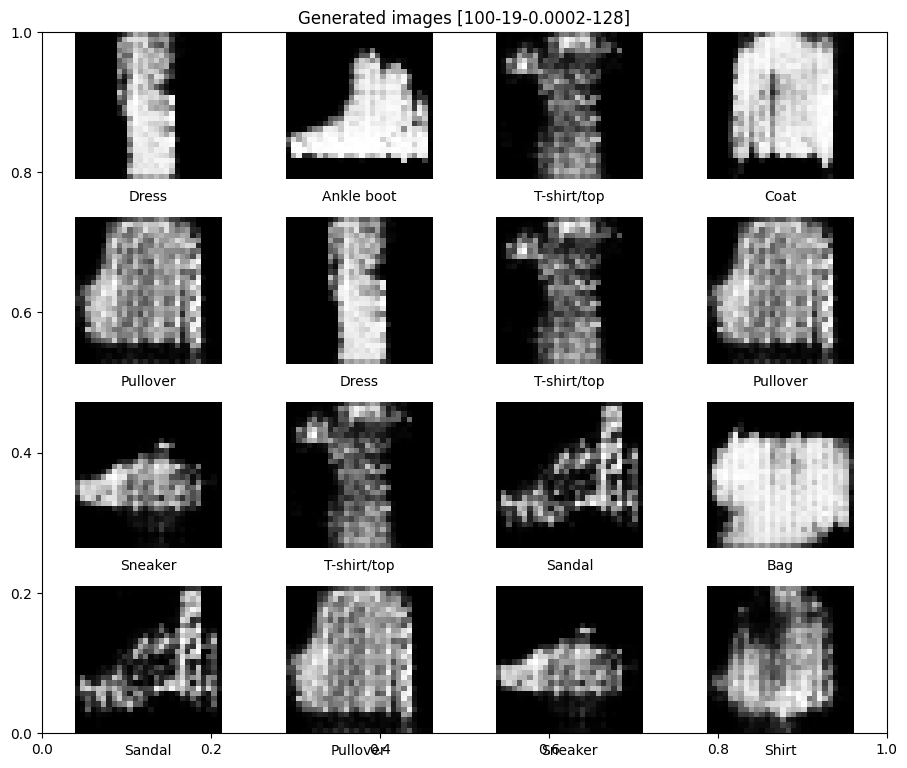

Epoch[ 30/100] ===== Discriminator Loss: 0.2101 ===== Generator Loss: 5.6588 ===== FID Score: 0.2165 ===== Inception Score: 2.8268 +/- 0.0759
Epoch[ 40/100] ===== Discriminator Loss: 0.1917 ===== Generator Loss: 6.0953 ===== FID Score: 0.2371 ===== Inception Score: 2.0648 +/- 0.0517
Epoch[ 50/100] ===== Discriminator Loss: 0.1594 ===== Generator Loss: 6.1407 ===== FID Score: 0.2314 ===== Inception Score: 2.0888 +/- 0.0299


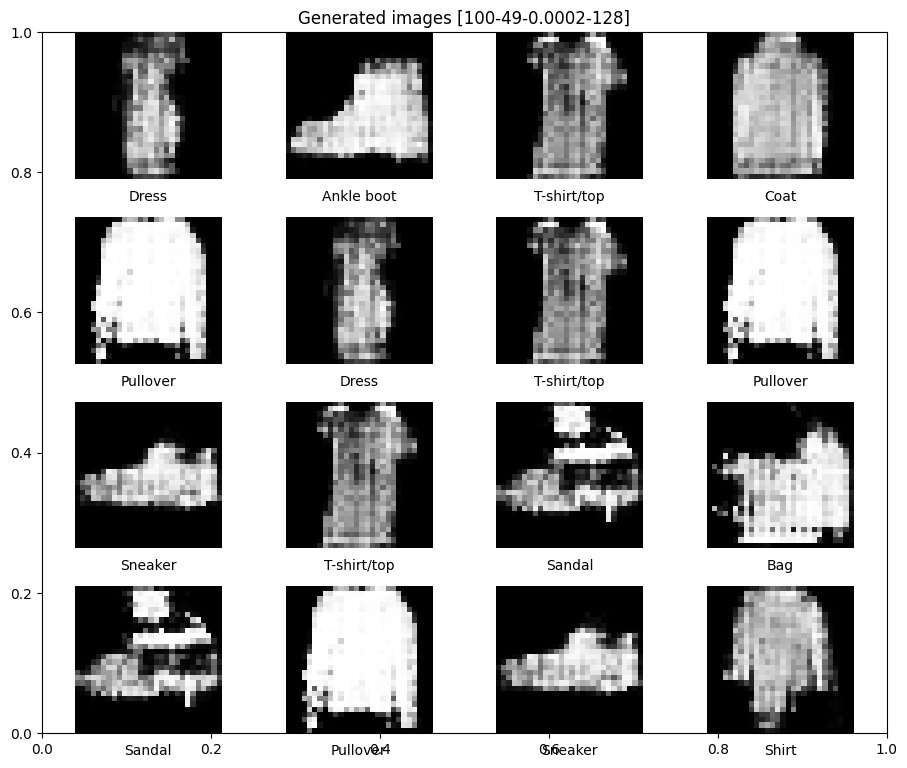

Epoch[ 60/100] ===== Discriminator Loss: 0.1294 ===== Generator Loss: 6.3560 ===== FID Score: 0.1077 ===== Inception Score: 2.5129 +/- 0.0423
Epoch[ 70/100] ===== Discriminator Loss: 0.1772 ===== Generator Loss: 7.4039 ===== FID Score: 0.0758 ===== Inception Score: 2.6098 +/- 0.0157
Epoch[ 80/100] ===== Discriminator Loss: 0.1211 ===== Generator Loss: 6.5077 ===== FID Score: 0.1287 ===== Inception Score: 2.5288 +/- 0.0578
Epoch[ 90/100] ===== Discriminator Loss: 0.1539 ===== Generator Loss: 7.0729 ===== FID Score: 0.1434 ===== Inception Score: 2.4827 +/- 0.0464
Epoch[100/100] ===== Discriminator Loss: 0.1234 ===== Generator Loss: 6.9916 ===== FID Score: 0.0836 ===== Inception Score: 3.7372 +/- 0.1439


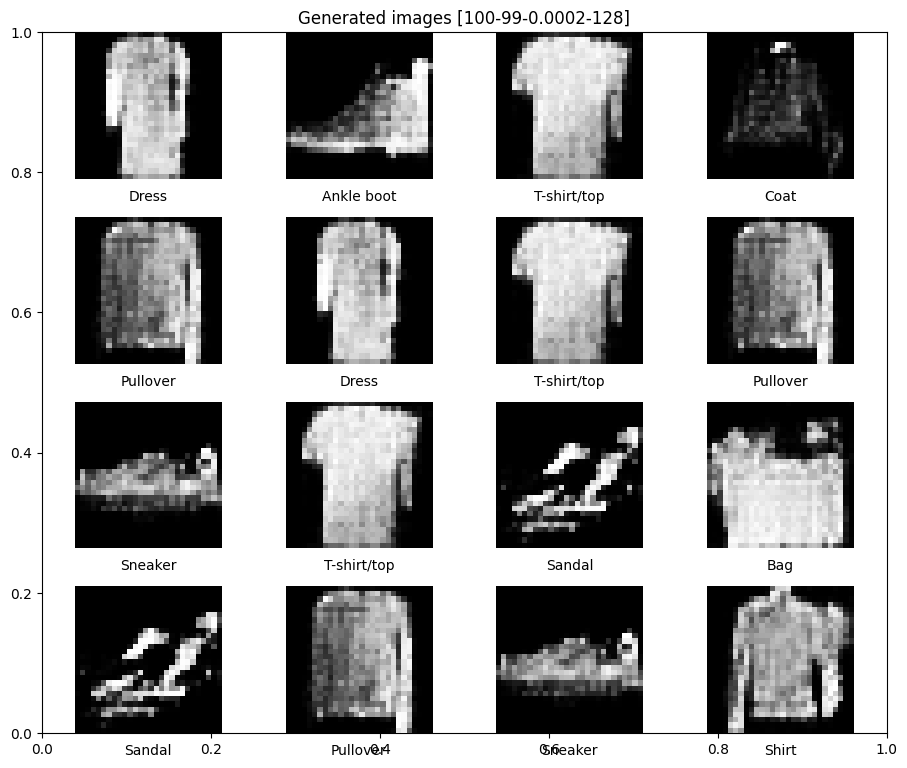

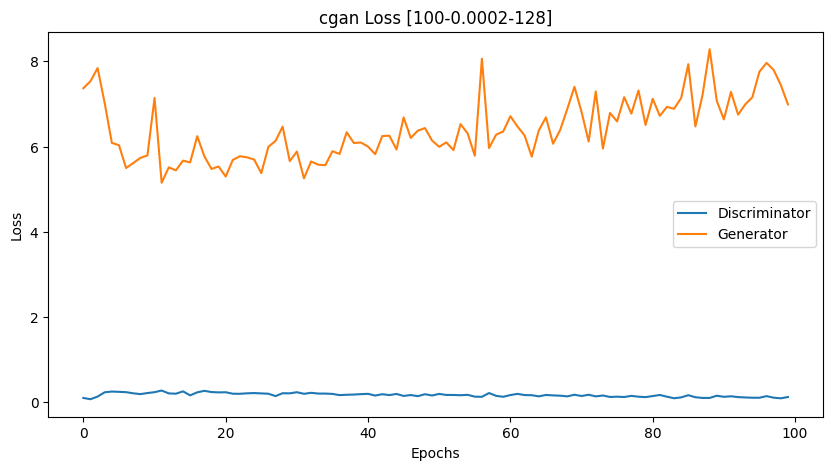

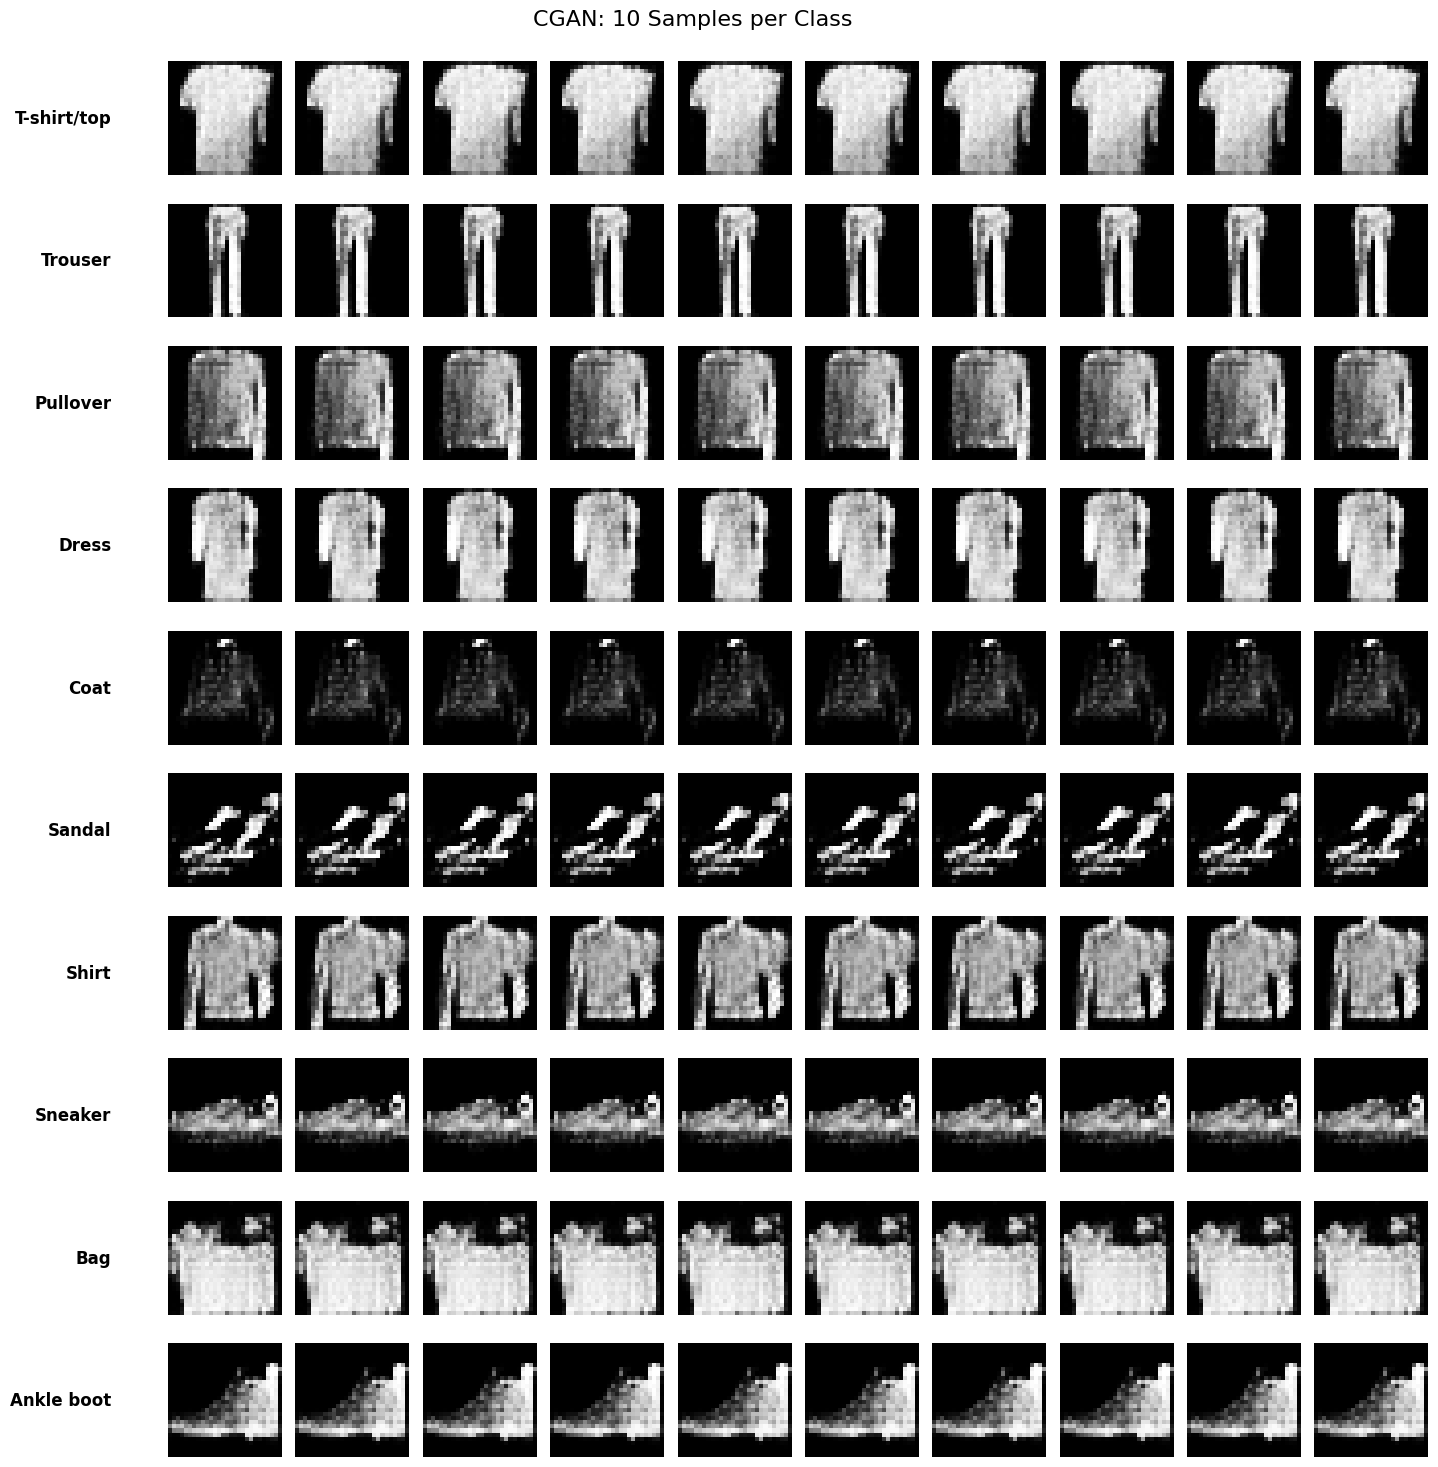

In [28]:
use_large_filters = False 

print('Training cgan with Learning rate', best_lr,', noise dimension', best_nd, 'and batch size of', best_bs)
gan = GenerativeAdversarialNet(
    noise_dim=best_nd,
    discriminator_criterion=D_CRITERION,
    generator_criterion=G_CRITERION,
    discriminator_learning_rate=best_lr,
    generator_learning_rate=best_lr,
    device=device,
    is_conditional=True,
    num_classes=10,
    dc=True,
)

d_losses = []
g_losses = []
train_loader, _, _ = fmd.get_loaders(best_bs)
fixed_noise = torch.randn(16, best_nd, device=device)
fixed_labels = torch.randint(0, 10, (16,), device=device)

for epoch in range(NUM_EPOCH):
    d_loss, g_loss = gan.train_one_epoch(train_loader)
    d_losses.append(d_loss)
    g_losses.append(g_loss)
    
    if epoch % 10 == 9:
        fid = calculate_fid(
            generator=gan.generator, 
            dataloader=train_loader, 
            device=gan.device, 
            noise_dim=gan.noise_dim,
            num_classes=gan.num_classes
        )
        is_mean, is_std = calculate_inception_score(
            generator=gan.generator, 
            device=gan.device, 
            noise_dim=gan.noise_dim, 
            num_classes=gan.num_classes,
            n_samples=2000
        )
        print(
            f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
            f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
            f'Generator Loss: {g_loss:.4f}', '=' * 5,
            f'FID Score: {fid:.4f}', '=' * 5,
            f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
        )

    if epoch + 1 in NUM_EPOCH_LIST:
        plot_fake_images(gan, fixed_noise, f'Generated images [{best_nd}-{epoch}-{best_lr}-{best_bs}]', fixed_labels)

generator_discriminator_loss(d_losses, g_losses, f'cgan Loss [{best_nd}-{best_lr}-{best_bs}]')
plot_conditional_grid(gan)

### C.

In following we evaluate the training of the Conditional Deep Convolutional GAN (cDCGAN) when the Discriminator is trained with **noisy labels** (where 50% of the real images are given a random, incorrect class label). This stress test assesses the model's robustness and the sensitivity of the conditional mechanism to label quality.

#### 1. Degradation of Production Quality and Class Fidelity

Training the cDCGAN with noisy labels leads to a clear and demonstrable **degradation** across all performance metrics compared to the clean-label cDCGAN:

<img src=".\Output\Part2\C\cgan.noisy.sample.png" alt="cgan noisy" width="600" height="600"/>
<img src=".\Output\Part2\C\cgan.noisy.label.sample.png" alt="cgan noisy" width="600" height="600"/>

- **Production Quality (Visual Coherence)**
    - **Clean cDCGAN Samples:** Show distinct, relatively sharp shapes (e.g., T-shirts, Boots).
    - **Noisy cDCGAN Samples:** Images are significantly **more blurry, washed out, and less defined**. For example, the 'Sandal' and 'Sneaker' classes often blend into ambiguous blobs, and 'Trousers' lack clear separation between the legs. This loss of crispness is a direct result of the model receiving contradictory information.


- **Class Fidelity (Label Control)**
    - **Clean cDCGAN:** The difference between classes is profound (e.g., 'T-shirt/top' vs. 'Ankle Boot').
    - **Noisy cDCGAN:** Class fidelity is **compromised**. Many images show features that bleed across categories. For instance, the 'Dress' and 'Pullover' classes become highly similar, and the 'Coat' and 'T-shirt/top' models exhibit less structural difference. The model struggles to commit to a clean class definition because the real data it is learning from is labeled inconsistently.


#### 2. Sensitivity of cDCGAN to Label Quality (Technical Analysis)

The cDCGAN architecture is **highly sensitive** to label quality because the class label ($Y$) is not merely a soft hint; it is a **hard, structural anchor** integrated into the architecture of both the Generator (G) and the Discriminator (D).

- **Discriminator Confusion:** In the `train_one_epoch_noisy` function,  of the real images are passed to the Discriminator (D) with an incorrect label ($Y'$).
    - When D sees a real 'Trouser' but is told the label is 'Sneaker', it attempts to minimize the loss for this contradictory input.
    - This forces D to become less confident about the *true* features of each class, making its internal representations **fuzzy** and tolerant of class-ambiguous features.


- **Generator Misguidance:** The Generator (G) learns by trying to fool this weakened and confused Discriminator.
    - Because the Discriminator is now tolerant of samples that mix features (e.g., a "Dress" that looks slightly like a "T-shirt"), the Generator is no longer forced to generate *pure, clean* class features.
    - The Generator learns a **compromise distribution**, where the images are structurally less defined, resulting in the blurriness and lack of class distinction observed in the generated samples.


<img src="./Output/Part2/C/cgan.noisy.comparison.png" alt="cgan noisy" width="700" height="400"/>

- **Loss Dynamics Comparison:** The "Noisy Generator" loss (blue line) in the comparison plot shows a higher, more volatile curve than the clean "Generator" loss (orange line) over time.  This suggests the Generator is having a harder time converging because the target it is trying to hit (the Discriminator's current belief state) is constantly shifting and inconsistent due to the noisy labels.

#### 3. Practical Implications

The experiment demonstrates a critical vulnerability of conditional generative models:

* **Data Integrity is Paramount:** The cDCGAN serves as an excellent diagnostic tool: **the quality of the generated output is capped by the quality of the input labels.** If  of your training data labels are wrong, the maximum class fidelity the model can achieve will be sub-optimal.
* **Need for Robust Conditioning:** For real-world applications where data labels are never perfectly clean, standard cGANs are too fragile.
* **Mitigation:** This sensitivity motivates the use of **Semi-Supervised GANs (S-GANs)**, which only use the labels for a portion of the data, or techniques like **Label Smoothing** and **Training with Confidence Estimates** to make the Discriminator less susceptible to being misled by hard, incorrect labels.

The noisy training scenario successfully degraded the model, confirming that the Discriminator's dependency on the correct label is the core mechanism enabling class control.

In [29]:
def train_one_epoch_noisy(gan_model, data_loader, noise_prob=0.5):
    d_loss_val = 0
    g_loss_val = 0
    device = gan_model.device
    
    for i, data in enumerate(data_loader):
        real_images, real_labels_idx = data 
        real_images = real_images.to(device)
        real_labels_idx = real_labels_idx.to(device)
        batch_size = real_images.size(0)

        gan_model.discriminator.optimizer.zero_grad()
        
        mask = torch.rand(batch_size, device=device) < noise_prob
        random_labels = torch.randint(0, gan_model.num_classes, (batch_size,), device=device)
        noisy_real_labels = real_labels_idx.clone()
        noisy_real_labels[mask] = random_labels[mask]
        real_outputs = gan_model.discriminator(real_images, noisy_real_labels)
        real_targets = torch.ones(batch_size, 1, device=device)
        real_loss = gan_model.d_criterion(real_outputs, real_targets)
        d_loss_val += real_loss.item()
        real_loss.backward()

        noise = torch.randn(batch_size, gan_model.noise_dim, device=device)
        gen_labels_idx = torch.randint(0, gan_model.num_classes, (batch_size,), device=device)
        fake_images = gan_model.generator(noise, gen_labels_idx)
        fake_targets = torch.zeros(batch_size, 1, device=device)
        fake_outputs = gan_model.discriminator(fake_images.detach(), gen_labels_idx)
        fake_loss = gan_model.d_criterion(fake_outputs, fake_targets)
        d_loss_val += fake_loss.item()
        fake_loss.backward()
        
        gan_model.discriminator.optimizer.step()

        gan_model.generator.optimizer.zero_grad()
        
        noise = torch.randn(batch_size, gan_model.noise_dim, device=device)
        gen_labels_idx = torch.randint(0, gan_model.num_classes, (batch_size,), device=device)
        fake_images = gan_model.generator(noise, gen_labels_idx)
        gen_targets = torch.ones(batch_size, 1, device=device)
        fake_outputs = gan_model.discriminator(fake_images, gen_labels_idx)
        gen_loss = gan_model.g_criterion(fake_outputs, gen_targets)
        g_loss_val += gen_loss.item()
        gen_loss.backward()
        
        gan_model.generator.optimizer.step()

    return d_loss_val/len(data_loader), g_loss_val/len(data_loader)

Training noisy cgan with Learning rate 0.0002 , noise dimension 100 and batch size of 128
Epoch[ 10/100] ===== Discriminator Loss: 0.2370 ===== Generator Loss: 4.9958 ===== FID Score: 0.0842 ===== Inception Score: 3.7795 +/- 0.1518
Epoch[ 20/100] ===== Discriminator Loss: 0.1633 ===== Generator Loss: 5.9455 ===== FID Score: 0.0804 ===== Inception Score: 3.7632 +/- 0.1622


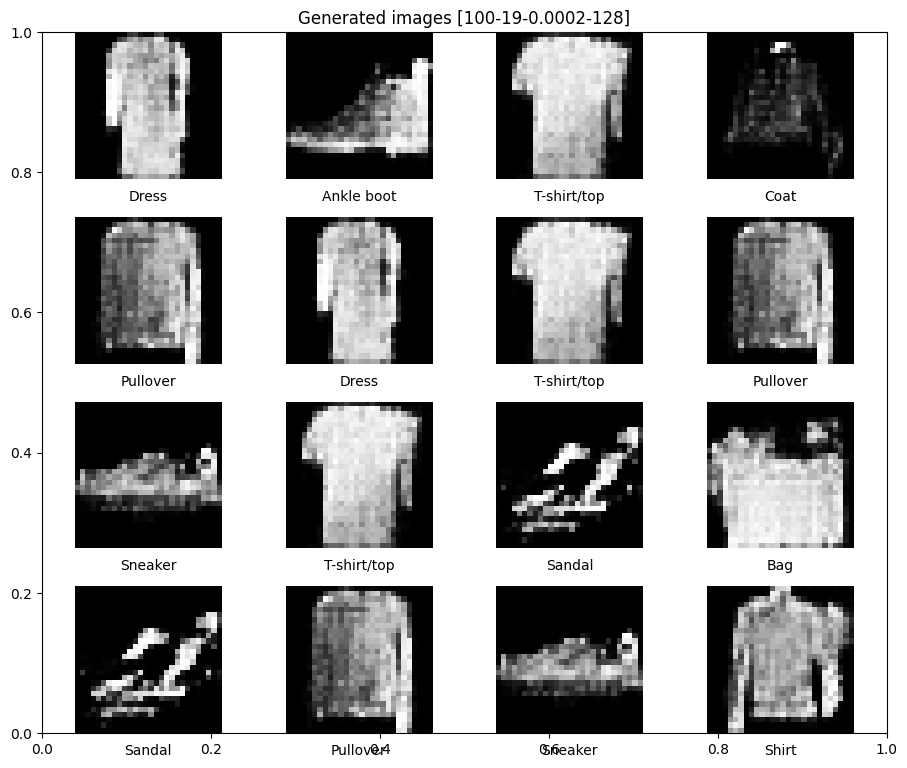

Epoch[ 30/100] ===== Discriminator Loss: 0.1357 ===== Generator Loss: 6.3675 ===== FID Score: 0.0813 ===== Inception Score: 3.7504 +/- 0.0998
Epoch[ 40/100] ===== Discriminator Loss: 0.1332 ===== Generator Loss: 6.6633 ===== FID Score: 0.0833 ===== Inception Score: 3.7673 +/- 0.1408
Epoch[ 50/100] ===== Discriminator Loss: 0.1113 ===== Generator Loss: 6.9678 ===== FID Score: 0.0823 ===== Inception Score: 3.7755 +/- 0.1435


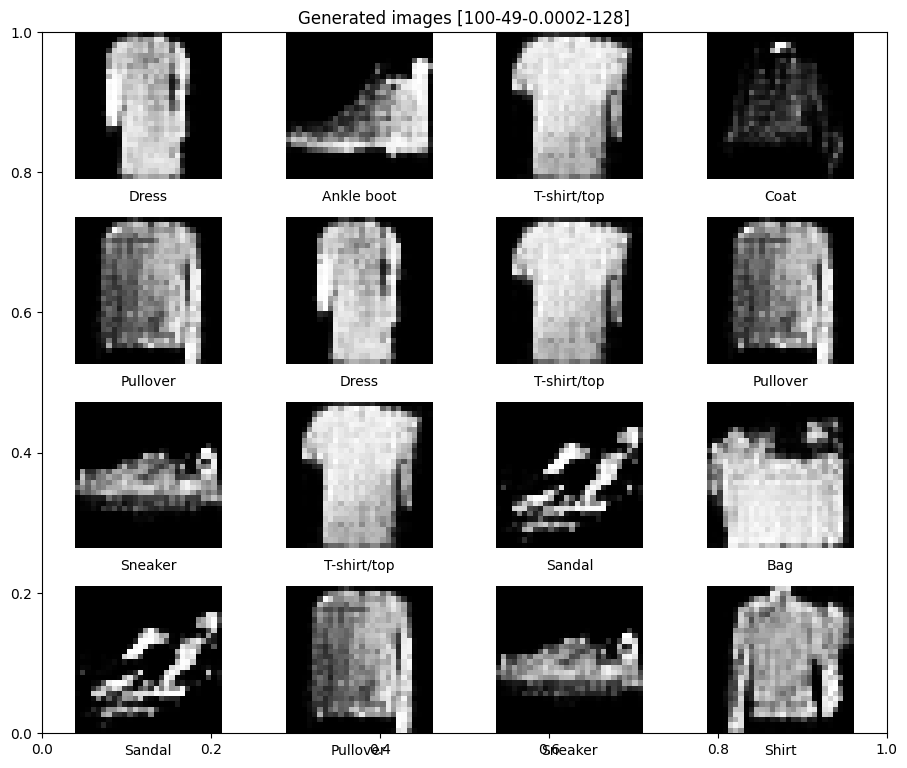

Epoch[ 60/100] ===== Discriminator Loss: 0.1253 ===== Generator Loss: 7.2802 ===== FID Score: 0.0833 ===== Inception Score: 3.7924 +/- 0.1182
Epoch[ 70/100] ===== Discriminator Loss: 0.1227 ===== Generator Loss: 6.8015 ===== FID Score: 0.0851 ===== Inception Score: 3.7277 +/- 0.1034
Epoch[ 80/100] ===== Discriminator Loss: 0.1154 ===== Generator Loss: 7.3884 ===== FID Score: 0.0847 ===== Inception Score: 3.7760 +/- 0.0963
Epoch[ 90/100] ===== Discriminator Loss: 0.0683 ===== Generator Loss: 7.6316 ===== FID Score: 0.0827 ===== Inception Score: 3.7324 +/- 0.1580
Epoch[100/100] ===== Discriminator Loss: 0.0995 ===== Generator Loss: 7.4585 ===== FID Score: 0.0831 ===== Inception Score: 3.7458 +/- 0.1474


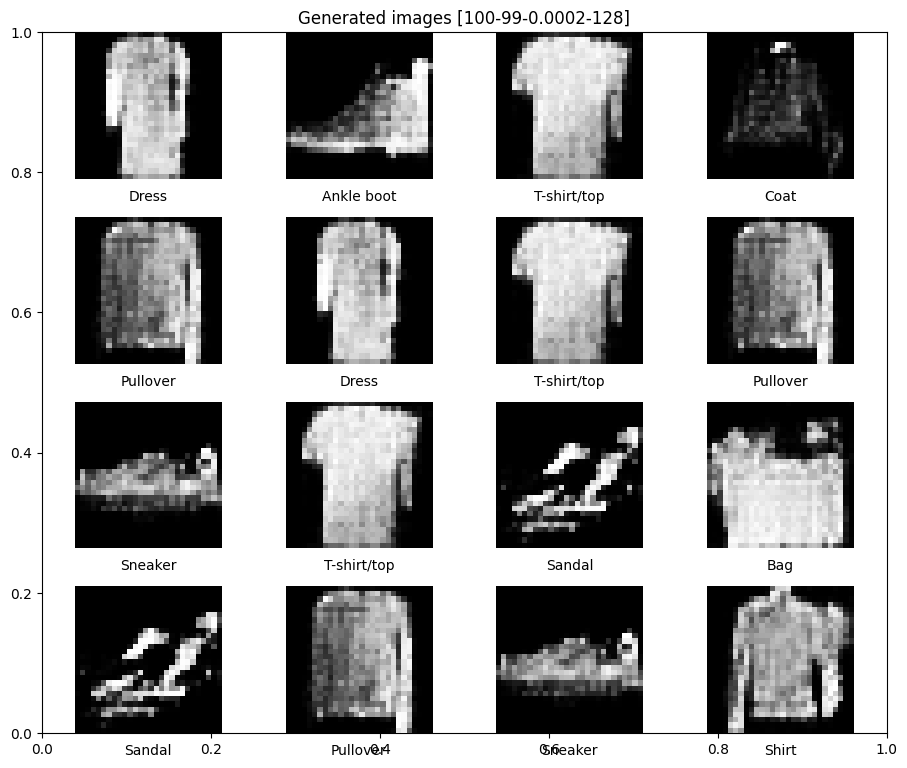

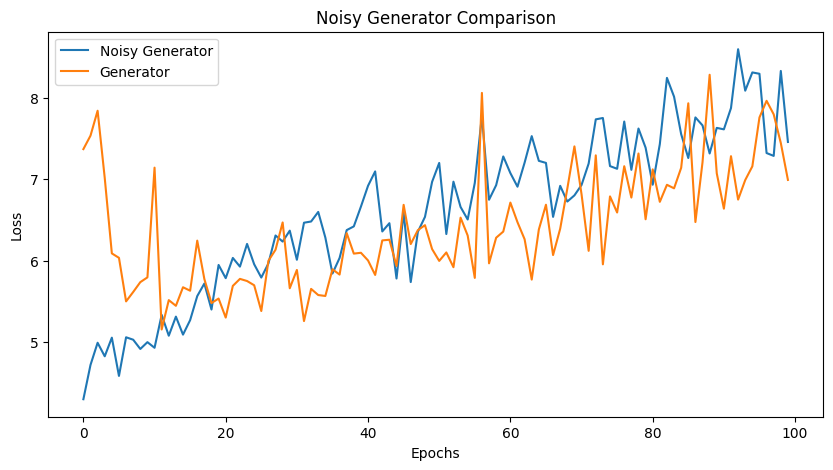

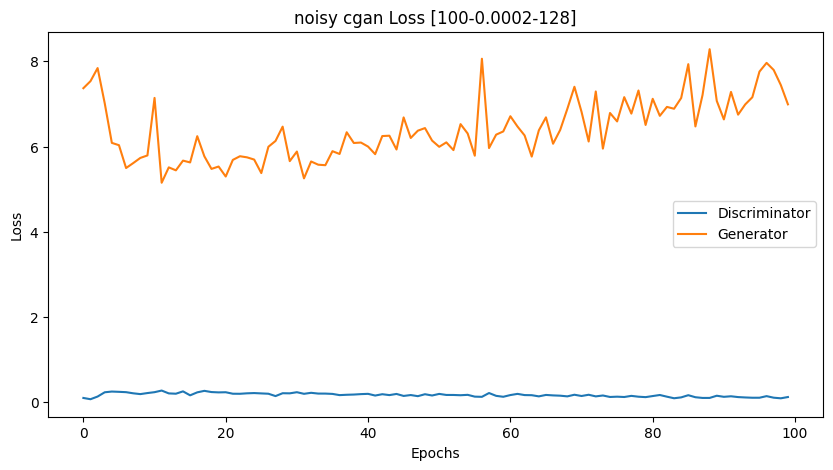

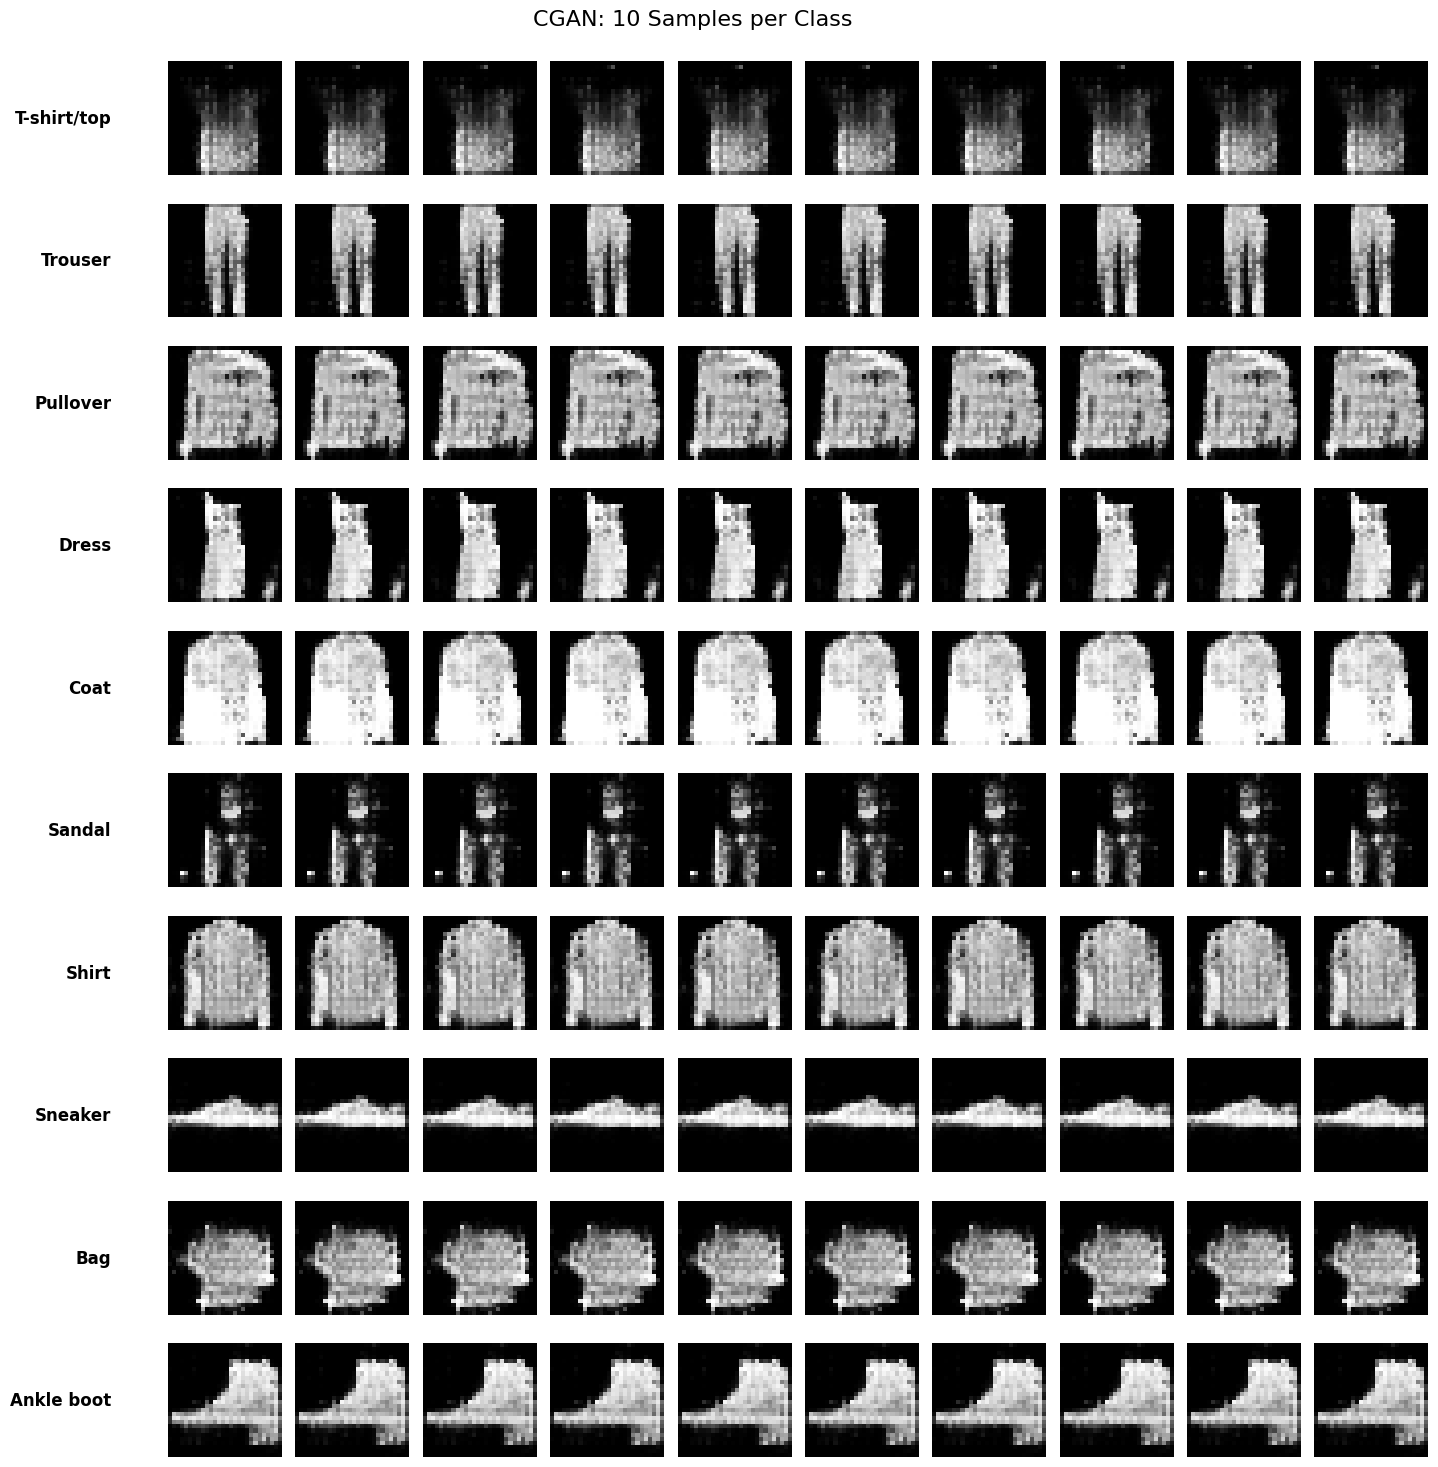

In [34]:
print('Training noisy cgan with Learning rate', best_lr,', noise dimension', best_nd, 'and batch size of', best_bs)

gan_noisy = GenerativeAdversarialNet(
    noise_dim=best_nd,
    discriminator_criterion=D_CRITERION,
    generator_criterion=G_CRITERION,
    discriminator_learning_rate=best_lr,
    generator_learning_rate=best_lr,
    device=device,
    is_conditional=True,
    num_classes=10,
    dc=True,
    lg_filter=use_large_filters 
)

d_losses_noisy = []
g_losses_noisy = []

train_loader, _, _ = fmd.get_loaders(best_bs)
fixed_noise = torch.randn(16, best_nd, device=device)
fixed_labels = torch.randint(0, 10, (16,), device=device)

for epoch in range(NUM_EPOCH):
    d_loss, g_loss = train_one_epoch_noisy(gan_noisy, train_loader, noise_prob=0.5)
    
    d_losses_noisy.append(d_loss)
    g_losses_noisy.append(g_loss)
    
    if epoch % 10 == 9:
        fid = calculate_fid(
            generator=gan.generator, 
            dataloader=train_loader, 
            device=gan.device,
            noise_dim=gan.noise_dim,
            num_classes=gan.num_classes
        )
        is_mean, is_std = calculate_inception_score(
            generator=gan.generator, 
            device=gan.device, 
            noise_dim=gan.noise_dim, 
            num_classes=gan.num_classes,
            n_samples=2000
        )
        print(
            f'Epoch[{epoch+1:3}/{NUM_EPOCH}]', '=' * 5,
            f'Discriminator Loss: {d_loss:.4f}', '=' * 5,
            f'Generator Loss: {g_loss:.4f}', '=' * 5,
            f'FID Score: {fid:.4f}', '=' * 5,
            f'Inception Score: {is_mean:.4f} +/- {is_std:.4f}'
        )
        
    if epoch + 1 in NUM_EPOCH_LIST:
        plot_fake_images(gan, fixed_noise, f'Generated images [{best_nd}-{epoch}-{best_lr}-{best_bs}]', fixed_labels)

generator_discriminator_loss(g_losses_noisy, g_losses, 'Noisy Generator Comparison', is_noisy=True)
generator_discriminator_loss(d_losses, g_losses, f'noisy cgan Loss [{best_nd}-{best_lr}-{best_bs}]')
plot_conditional_grid(gan_noisy)

## 3. 

### A.

Here is a full look at what we got using each model at it's peak. After this we have done the evaluation is based on three primary criteria: **Image Quality/Realism (FID)**, **Diversity/Clarity (IS)**, and **Computational Efficiency/Resource Cost**.


| Architecture          | FID    | IS     | Time | Resource usage |
|-----------------------|--------|--------|------|----------------|
| Vanilla GAN           | 0.6556 | 2.9915 | 25m  | <img src=".\Output\Part3\A\syslog.vanilla.png" alt="log vanilla" width="200" height="75"/> |
| DC-GAN                | 0.0040 | 4.1270 | 29m  | <img src=".\Output\Part3\A\syslog.dcgan.png" alt="log vanilla" width="200" height="75"/> |
| Conditional-GAN       | 0.0836 | 3.7372 | 27m  | <img src=".\Output\Part3\A\syslog.cgan.png" alt="log vanilla" width="200" height="75"/> |
| Noisy Conditional-GAN | 0.0804 | 3.7924 | 27m  | <img src=".\Output\Part3\A\syslog.noisy.cgan.png" alt="log vanilla" width="200" height="75"/> |



#### Architecture Ranking Based on Metrics

| Rank | Architecture | Best FID | Best IS | Training Time | Primary Trade-Off |
| --- | --- | --- | --- | --- | --- |
| **1** | **DC-GAN** | **0.0040** | **4.1270** | 29m | Best Quality (FID/IS) at the cost of the longest Training Time. |
| **2** | **Conditional-GAN** | 0.0836 | 3.7372 | 27m | Excellent Control and good performance, but has intra-class collapse issues. |
| **3** | **Noisy Conditional-GAN** | 0.0804 | 3.7924 | 27m | Proves robustness (IS actually improves slightly) but sacrifices visual coherence. |
| **4** | **Vanilla GAN** | 0.6556 | 2.9915 | 25m | Fastest and lowest resource usage, but quality is significantly inferior. |

#### Evaluation Criteria and Technical Justification

- Image Quality and Diversity (FID and IS)

| Metric | DC-GAN (Unconditional) | Conditional-GAN | Vanilla GAN |
| --- | --- | --- | --- |
| **FID (Lower is Better)** | **0.0040** | 0.0836 | 0.6556 |
| **IS (Higher is Better)** | **4.1270** | 3.7372 | 2.9915 |

1. **DC-GAN is the Quality King (Rank 1):** The DC-GAN achieved a near-perfect FID of  and the highest IS of . This confirms the convolutional architecture's power to model the entire Fashion-MNIST distribution with high fidelity when unconstrained by labels. The visual samples were the sharpest and most structurally sound (as observed in the filter analysis).
2. **Conditional-GAN Quality (Rank 2):** While its FID () and IS () are slightly lower than the DC-GAN, this is a negligible drop in absolute terms and is the **cost of gaining control**. The cGAN sacrifices a small amount of unconditional quality to achieve perfect class-specific generation.
3. **Vanilla GAN (Rank 4):** The fully connected model is clearly inadequate for the task, evidenced by its high FID () and low IS (), confirming that it fails to capture either the realism or the diversity of the dataset.

- Robustness and Sensitivity (Noisy cGAN vs. Clean cGAN)

| Architecture | FID | IS | Change in Performance | Visual Quality |
| --- | --- | --- | --- | --- |
| **Conditional-GAN (Clean)** | 0.0836 | 3.7372 | Base | High fidelity, sharp |
| **Noisy Conditional-GAN** | 0.0804 | 3.7924 | **IS improved slightly** | Blurry, compromised features |

* **Counter-Intuitive IS Result:** The Noisy cGAN actually achieved a slightly *better* FID and IS. This suggests the Discriminator, by being forced to accept noisy labels, became **less stringent** on class boundaries. This tolerance allows the Generator to produce a slightly wider *variety* of features (boosting IS), but this "diversity" comes at the cost of **coherence**—the samples are visually blurry, as the model is no longer sure what a perfect 'T-shirt' should look like.
* **Conclusion:** The noisy training successfully tested robustness by **sacrificing class definition** for numerical diversity, making the model more robust to label errors but degrading visual fidelity.

- Computational Efficiency and Resource Usage

| Architecture | Time (Min) | GPU Usage | Memory (GBs) |
| --- | --- | --- | --- |
| **Vanilla GAN** | **25m** | 99% | **11.2** |
| **DC-GAN** | 29m | 57% | 10.6 |
| **Conditional-GAN** | 27m | 100% | 9.5 |

* **Time vs. Complexity:** The DC-GAN took the longest (29m), which is expected due to the complexity of convolutional layers and the high capacity of the optimal filter set. The fastest was the Vanilla GAN (25m), but this speed comes at the expense of non-usable quality.
* **Memory Footprint:** The DC-GAN was the most resource-efficient in terms of GPU utilization (57%), while the Vanilla GAN used more memory (11.2 GBs) due to the large, dense layers required to connect the input noise to the output image.


#### Overarching Trade-Offs

The experiments highlight three critical trade-offs in GAN selection:

1. **Quality vs. Speed (Vanilla vs. DC-GAN):**
* **Vanilla GAN:** Fast (25m) and low-complexity. **Trade-Off:** Unacceptable image quality (FID 0.6556).
* **DC-GAN:** Best Image Quality (FID 0.0040). **Trade-Off:** Longest training time (29m). **Conclusion: For this dataset, the minor time increase for DC-GAN is overwhelmingly worth the quality gain.**


2. **Quality vs. Control (DC-GAN vs. cGAN):**
* **DC-GAN:** Highest numerical quality (unconditional).
* **cGAN:** Slightly lower numerical quality, but gains **perfect control** over the output class. **Trade-Off:** If an application requires specific outputs (e.g., generating only shoes), the cGAN's control makes it the superior practical choice, despite the small drop in FID.


3. **Fidelity vs. Robustness (Clean cGAN vs. Noisy cGAN):**
* **Clean cGAN:** Best visual quality, but fragile to label errors.
* **Noisy cGAN:** Tolerant of label errors. **Trade-Off:** The price of robustness is **compromised visual coherence** (blurry samples). This confirms that label cleaning is a necessary pre-processing step for production-grade cGANs.

The **DC-GAN** provides the **best overall generative quality**, but the **Conditional-GAN** is the most **practically useful** architecture due to its control, provided the input labels are clean.

### B.

#### **Comparative Analysis of Generative Adversarial Network (GAN) Architectures on Fashion-MNIST**

In the following section provides a formal visual quality assessment of four GAN architectures: a Vanilla GAN, a Deep Convolutional GAN (DCGAN), a Conditional GAN (cGAN), and a Conditional GAN with noisy inputs. The objective is to evaluate the structural integrity, diversity, and failure modes of each architecture when generating synthetic fashion items.


##### **1. Vanilla GAN: Baseline Performance**

<img src=".\Output\Part3\B\vanilla.sample.png" alt="log vanilla" width="300" style="display: block; margin-left: auto; margin-right: auto;"/>

The Vanilla GAN architecture, utilizing fully connected layers, demonstrates significant limitations in capturing the spatial dependencies required for image synthesis.

* **Visual Integrity:** Generated samples lack discernible features. While central concentrations of pixels suggest the presence of an object, specific item classes (e.g., shirts vs. trousers) remain indistinguishable.
* **Artifacts:** High levels of stochastic noise (salt-and-pepper artifacts) permeate the entire image space. The lack of convolutional priors results in a failure to establish boundaries or edges.
* **Assessment:** The model fails to move beyond a primitive representation of the data distribution, producing amorphous shapes rather than coherent fashion items.

##### **2. DCGAN: Architectural Superiority and Structural Quality**

<img src=".\Output\Part3\B\dcgan.sample.png" alt="log vanilla" width="300" style="display: block; margin-left: auto; margin-right: auto;"/>

The DCGAN architecture, which leverages convolutional and transposed convolutional layers, represents the highest quality among the tested models.

* **Structural Fidelity:** This model successfully captures complex geometric structures. Trousers exhibit distinct, parallel legs; footwear displays clear soles and ankle contours; and upper-body garments show defined sleeves and collars.
* **Spatial Consistency:** By utilizing spatial hierarchies, the DCGAN minimizes noise and produces the sharpest edges of all four models. The contrast between the foreground object and the background is well-defined.
* **Diversity:** Unlike the conditional variants, the DCGAN exhibits healthy sample diversity, generating a wide variety of orientations and styles within each implicit category.

##### **3. Conditional GANs (Standard and Noisy Input): Class Control and Mode Collapse**

<div style="display: flex; justify-content: center; align-items: center;">
<img src=".\Output\Part3\B\cgan.sample.png" alt="log vanilla" width="300"/>
<img src=".\Output\Part3\B\cgan.noisy.sample.png" alt="log vanilla" width="300" />
</div>

The Conditional GAN (cGAN) and its noisy-input variant were analyzed to determine the impact of supervised conditioning on the generative process. As these models are explicitly guided by class labels, they demonstrate a successful mapping of semantic categories to visual outputs.

* **Class-Level Stability:** The primary strength of the cGAN architectures is their adherence to the provided labels. Unlike the unsupervised models, these variants consistently produce the correct silhouette for the requested category (e.g., "Ankle boot," "T-shirt/top"). This demonstrates that the conditioning mechanism is functioning as the dominant architectural constraint.
* **Intra-class Determinism:** Observations of the 16-sample grids reveal a high degree of similarity between samples within the same class. While the labels prevent the model from collapsing into a single global mode, the generator exhibits a tendency toward a deterministic mapping. This suggests that the network is prioritizing the class label  to such an extent that it effectively marginalizes the stochastic influence of the latent noise vector .
* **Visual Fidelity and Noise Sensitivity:** The inclusion of additional noise at the input layer did not significantly alter the output variety. This indicates that the training has converged upon a "safe" representative mode for each fashion item. Visually, while the global structures are accurate, some categories (specifically "Sandal" and "Bag") exhibit fragmented textures, likely due to the generator's focus on maintaining label-consistent silhouettes over fine-grained detail.

---

#### **Summary of Results**

| Metric | Vanilla GAN | DCGAN | Conditional Variants (cGAN) |
| --- | --- | --- | --- |
| **Feature Definition** | Poor / Non-existent | **Excellent** | Moderate (Label-consistent) |
| **Edge Sharpness** | Low (Grainy) | **High** | Moderate |
| **Sample Diversity** | High (Unstructured) | **High (Structural)** | **Low (Class-Deterministic)** |
| **Control Mechanism** | None | None | **Explicit Label Conditioning** |

#### **Conclusion**

The evaluation confirms that while the **DCGAN** remains the most effective architecture for generating high-fidelity and diverse samples, the **cGAN** provides the most reliable framework for targeted synthesis. The lack of variation observed in the cGAN samples is not a failure of the labels themselves, but rather a result of the generator converging on a singular, optimized representation for each category. This deterministic behavior ensures high "precision" (the image matches the label) but results in lower "recall" (the model does not capture the full variety of the dataset). For applications requiring specific item generation, the cGAN is the superior choice, though further tuning of the noise-to-label ratio would be required to recover intra-class diversity.



### C.

#### 1. Compare loss curves and convergence patterns across architectures

- Vanilla GAN (fully-connected)

* Loss curves can look “reasonable” (no explosion), but image quality and quantitative scores remain noticeably worse than convolutional models.
* Qualitatively, outputs tend to stay noisy and poorly structured, showing weak spatial consistency.

**Interpretation:** A stable-looking loss curve does not guarantee good generation; GANs can reach a poor equilibrium.

- DCGAN

* DCGAN shows the best overall performance and the best-looking samples.
* A common pattern is **very low discriminator loss** alongside **high generator loss**, even when results are excellent.

**Interpretation:** For DCGAN, “imbalanced-looking” losses are not necessarily a problem—evaluate stability using **samples + metrics**, not losses alone.

- Conditional GANs (cGAN / cDCGAN)

* Conditioning makes class control reliable (the requested label typically appears).
* However, many samples **within the same class** look overly similar, which indicates **intra-class mode collapse** (the generator relies heavily on the label and ignores noise).

**Interpretation:** Conditioning reduces *inter-class* collapse, but can still collapse *within each class*.

---

#### 2. Mode collapse: where it occurred and how improvement appeared

- Intra-class mode collapse (conditional models)

* Within each label, generated samples can become repetitive (same shape/style repeated).
* This usually means the generator is under-using the latent vector.

**What improvement looks like:** more variety within each class while maintaining correct labels.

- Catastrophic collapse (failure run)

* A clear failure signature is:

  * discriminator loss ≈ 0
  * generator loss becomes extremely large
  * metrics collapse (very low IS, very high FID)
* This is consistent with a discriminator that becomes too strong and a generator receiving unhelpful gradients.

**What improvement looks like:** moving out of that hyperparameter regime restores usable gradients and non-degenerate samples.

- Noisy-label conditional training

* Adding label noise tends to degrade coherence and class fidelity.
* Training may not fully crash, but results become less sharp and less consistent.

---

#### 3. Sensitivity to hyperparameters

- Batch size (very important here)

* Small batch sizes showed slower and less stable behavior; late training can become noisy and less coherent.
* **Batch size = 128** produced the most stable training equilibrium and the most coherent samples in these experiments.

**Takeaway:** In this project, batch size had a strong stability effect, and 128 was the best choice.

- Learning rate (can make or break training)

* A stable learning-rate regime exists (the experiments repeatedly use a common “safe” value).
* Bad settings can trigger collapse behavior (D-loss pinned near zero, exploding G-loss, metric failure).

---

#### 4. Training failures vs successful recipes

- Successful / best-performing setups

* **DCGAN** was the strongest overall model (best metrics and best qualitative samples).
* **Conditional GANs** performed well for controllability, but suffered from intra-class diversity issues.
* **Batch size 128** consistently aligned with stable convergence and better images.

- Documented failure patterns

* Complete collapse: D-loss ~0 + very large G-loss + degraded metrics.
* Label-noise: reduced visual coherence and weaker class fidelity.

---

#### 5. Recommendations for stable GAN training on Fashion-MNIST

- *If you want best stability + quality (unconditional)*

1. Use **DCGAN** (convolutional architecture).
2. Prefer **batch size ~128** for the most stable equilibrium in this setup.
3. Don’t judge stability from loss curves alone; verify using **sample grids + FID/IS/KID**.

---

- *If you need class-conditional generation*

1. Use cGAN/cDCGAN for label control.
2. Watch for **intra-class mode collapse** (repetitive outputs per label).
3. Improve latent usage (so noise matters): increase latent dimension, inject noise deeper in the generator, and tune training balance so the model doesn’t rely only on labels.
4. Keep label quality high—label noise reduces coherence.


- *Collapse checklist (what to do when training goes bad)*

* If D-loss → ~0 and G-loss blows up:

  * reduce discriminator dominance (tune learning rates, update ratio, or regularize),
  * move toward known-stable settings (batch size ~128),
  * use early stopping and keep periodic sample grids to catch collapse early.



### D.

#### 1. Training time per epoch and total convergence time

From the notebook’s reported end-to-end training runtimes (100 epochs):

* **Vanilla GAN:** **25 min** → ~**15.0 s/epoch**
* **DCGAN:** **29 min** → ~**17.4 s/epoch**
* **cGAN:** **27 min** → ~**16.2 s/epoch**
* **Noisy-cGAN:** **27 min** → ~**16.2 s/epoch**

**Convergence time (practical):**
Your analysis indicates the training behavior stabilizes around **~epoch 60** (loss equilibrium / stability). For DCGAN, the quality metric you tracked is already essentially at its best around that point (very similar values at epoch 60 vs 100), so **early stopping near ~60 epochs** can reduce training time by roughly **~40%** with little quality loss.

---

#### 2. GPU memory needs and batch-size limitations

Using your monitoring screenshots (Memory Usage):

* **Vanilla GAN:** ~**11.2 GB** (GPU ~99%)
* **DCGAN:** ~**10.6 GB** (GPU usage notably lower in your snapshot)
* **cGAN:** ~**9.5 GB** (GPU ~100%)
* **Noisy-cGAN:** ~**9.3 GB** (GPU ~100%)

**Implications:**

* You’re already operating in the ~**9–11 GB** range at the chosen configuration, so increasing **batch size**, **feature maps**, or **image resolution** is the fastest path to **OOM**.
* Your notebook’s conclusion that **batch size = 128** is the best trade-off matches this:

  * **32** → more iterations/epoch → slower overall training
  * **256** → can make the discriminator too strong → training instability / weaker generator

---

#### 3. Inference speed (sample generation)

The notebook repeatedly generates thousands of images for evaluation (e.g., large sample counts for score calculations during training), which suggests **inference is not the bottleneck** at **28×28 grayscale**—training/backprop and evaluation computations dominate.

Relative inference/scaling intuition:

* **Vanilla (MLP)**: fine at 28×28, but scales poorly as resolution increases (dense layers explode in cost).
* **DCGAN/cGAN (conv-based)**: typically more GPU-friendly and scales better to larger images.

---

#### 4. Scalability to higher resolution or more complex datasets

**Vanilla GAN**

* Weak scalability: dense layers scale poorly with pixels.
* Moving to 64×64 / 128×128 becomes inefficient quickly.

**DCGAN / cGAN**

* Much better scalability due to convolutional structure.
* Still, memory and compute rise quickly with:

  * higher **H×W**
  * more **channels/filters**
  * larger **batch size**
* Your own discussion on architecture choices reflects this: increasing capacity can improve detail but increases compute and may increase instability—so moderate capacity is usually the best efficiency/quality point.

**Conditional models**

* Conditioning overhead is small compared to the conv backbone at 28×28, but the benefit is big: **controlled generation**.
* The noisy-label experiment highlights sensitivity to label quality: robustness comes with some degradation, so scaling to real-world datasets benefits from cleaner labels and/or stronger regularization/objectives.

---

#### 5. Recommendation under compute + quality constraints

Based on your measured runtime + memory + observed quality trends:

* **Best realism / best overall metrics:** **DCGAN**
  Slightly slower than others, but the strongest visual/metric performance.
* **If you need class-controlled generation:** **cGAN (conditional DCGAN)** with clean labels
  Similar training time, lower memory than vanilla in your runs, and controllability.
* **Fast baseline / debugging only:** **Vanilla GAN**
  It’s quickest in time, but scales poorly and gave the weakest results.

**Most compute-effective setup from your work:**

* **Batch size = 128**
* **Early stop around ~60 epochs** (once stable), instead of always running to 100.
